# From Physics to Physiology: testing 1D blood-flow assumptions
## Project 2 · Healthy aorta 0012_H_AO_H

### Introduction: what are we trying to learn?

The heart drives pulsatile blood flow through a curved, branching aorta. Pressure forces accelerate the blood, while viscosity transfers momentum between fluid layers and to the wall. A three-dimensional CFD model resolves the velocity vector and pressure throughout that geometry. A one-dimensional model keeps a few quantities at each position along the vessel: cross-sectional area $A(s,t)$, flow rate $Q(s,t)$ and mean pressure $\bar P(s,t)$. This reduction makes larger vascular models practical, but it needs assumptions about the flow patterns that have been averaged away.

**Our question is: where, and during which parts of the cardiac cycle, do those assumptions agree with the available 3D simulation?** Project 2 asks us to extract sections, check mass balance and a Womersley reference, compare pressure/profile/friction assumptions, and evaluate the 1D momentum balance. The group's A1–A6 plan organises these checks. We first verify the calculations on cases with known answers, then apply them to the aorta and interpret the remaining discrepancies.

This follows the course's progression from steady flow and Poiseuille resistance to unsteady and convective inertia, and finally image-based CFD. A small residual means the selected terms nearly balance under our reduction and sampling choices. It does not, by itself, establish agreement with a living person's circulation. That would require independent measurements and a model suitable for the physiological question.

**What we actually analyse.** This notebook post-processes an existing rigid-wall CFD simulation; it does not run a new Navier–Stokes solver. The supplied surface file provides velocity and wall shear. The matching public volume archive supplies interior pressure and velocity: all 201 snapshots have been extracted to the compact section dataset in this bundle. Its source and parameters are recorded, and the notebook recalculates the metrics from those fields. The chosen model is documented as healthy. The manufactured narrowing later in the notebook is a code-verification exercise; it supplies no evidence about an anatomical stenosis.

**Course basis:** [Introduction, slides 24–28 and 40](sources/course/introduction.pptx); [steady flow, slides 11–12 and 24](sources/course/steady_flow.pptx); [dynamic circulation, PDF pp. 13–26](sources/course/dynamic_circulation.pdf#page=13); [computational haemodynamics, PDF pp. 7–10 and 29](sources/course/computational_haemodynamics.pdf#page=7). **Assignment basis:** [Project 2, slide 2](sources/FP2P_projects_Simone.pptx) and [group working plan, pp. 3–4](sources/FtP%20Project.pdf#page=3). Course files were checked against Canvas on 8 October 2026. Page references below count PDF pages, which can differ from slide numbers printed in the footer.

## 1. Setup: one shared folder and one Python environment

Unzip the entire bundle. Keep this notebook beside `data/`, `sources/` and `requirements.txt`. Use **Python 3.12**, then run these commands from that folder:

```bash
python3.12 -m venv .venv
# macOS / Linux:
source .venv/bin/activate
# Windows instead: .venv\Scripts\activate
python -m pip install -r requirements.txt
python -m ipykernel install --prefix .venv --name ftp-aorta --display-name "FtP aorta (Python 3.12)"
python -m jupyter lab
```

Choose **FtP aorta (Python 3.12)**, then **Restart Kernel and Run All Cells**. No notebook cell installs packages or downloads data. Initial input load may take tens of seconds; allow roughly 2–5 minutes for the default run, 6 GB free RAM recommended. A fresh VMTK extraction can take longer; a verified cache is supplied.

PyVista handles VTK data, slices and integration. VMTK extracts the anatomical centerline. ParaView is a separate desktop program for manual 3D inspection; its `paraview.simple` module runs through ParaView's `pvpython`, not ordinary pip Python. Notebook exports portable VTP/PVD files and an optional ParaView script. Main notebook does not require ParaView to be installed.

[VMTK installation](https://vmtk.github.io/download/), [PyVista API](https://docs.pyvista.org/genindex.html), [ParaView guide](https://docs.paraview.org/en/latest/).

**Reading the notebook.** First read the question above and the equations in “Physics and conventions”. The methods-library cells define reusable calculations; executing them makes the functions available but does not yet produce patient results. Sections 3–8 call those functions and interpret their outputs. For a group discussion, concentrate on the explanation immediately before each calculation and the figure guide after it; return to a function's docstring for implementation details.

**Why one environment and one folder?** Package versions affect mesh filters and numerical routines. Relative paths let a group member run the same inputs on another computer. The setup cell records versions and establishes one place for exported figures and tables. This supports the reproducible, well-documented code requested in the [project guidelines, PDF p. 1](sources/course/project_guidelines.pdf#page=1).

In [1]:
import os
from pathlib import Path
os.environ.setdefault('MPLCONFIGDIR', str(Path.cwd() / '.matplotlib-cache'))
import warnings
# VTK 9.6 uses a NumPy shape assignment deprecated by NumPy 2.5.
# Numerical checks below validate the affected conversions.
warnings.filterwarnings('ignore', message='Setting the shape on a NumPy array.*', category=DeprecationWarning)
import sys
import platform
from importlib.metadata import version
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

plt.rcParams.update({'figure.figsize': (10, 4), 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': .2, 'figure.dpi': 110})
COLORS = {'main': '#22577A', 'reference': '#C07820', 'alternate': '#815887', 'muted': '#67737C'}
BASE = Path.cwd()
if not (BASE / 'data' / '0012_H_AO_H').exists():
    raise FileNotFoundError('Start Jupyter in the unzipped project folder containing data/.')
DATA = BASE / 'data' / '0012_H_AO_H'
EXPORT = BASE / 'results'
FIGURES = EXPORT / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)

def save_figure(name):
    """Save the current labelled figure as PNG and SVG, then show it inline."""
    plt.tight_layout()
    plt.savefig(FIGURES / f'{name}.png', dpi=180, bbox_inches='tight')
    plt.savefig(FIGURES / f'{name}.svg', bbox_inches='tight')
    plt.show()

display(pd_versions := {pkg: version(pkg) for pkg in
                       ['numpy','scipy','pandas','matplotlib','pyvista','vtk','vmtk']})
print('Python:', platform.python_version())

Matplotlib is building the font cache; this may take a moment.


{'numpy': '2.5.3',
 'scipy': '1.18.1',
 'pandas': '3.0.6',
 'matplotlib': '3.11.2',
 'pyvista': '0.49.0',
 'vtk': '9.6.2',
 'vmtk': '1.5.2'}

Python: 3.12.14


### Configuration: change parameters here, then restart and run all

Source solver uses the common **cm–g–s convention**: density 1.06 g/cm³, dynamic viscosity 0.04 g/(cm·s), timestep 0.000937 s; preprocessing file sets cardiac period 0.937 s. Coordinate and field conversions are explicit below. The numerical magnitudes and cap-flow comparison check this interpretation. No independent field-unit metadata was supplied.

**ρ = 1060 kg/m³**, **μ = 0.004 Pa·s**, **ν = μ/ρ**. `vWSS` is interpreted as wall-shear vector in dyn/cm². Its sign convention is not independently documented, so surface comparison uses magnitudes. Signed volume friction is computed from velocity gradients.

Slice spacing, exclusion masks, 10% exploratory thresholds and 12 Fourier harmonics are modelling choices, not instructor pass/fail rules. Healthy model documentation supplies no stenosis diagnosis; area narrowing is described geometrically.

**Why convert units before doing any physics?** A pressure-gradient term and a friction term can be added only when their units agree. Source coordinates in centimetres and velocities in centimetres per second are converted to metres and metres per second; areas therefore scale with length squared. The factor $0.1$ converts dyn/cm² to Pa. A visually convincing result can still be wrong by orders of magnitude if one conversion is omitted.

`DT` is the solver time step; saved frames are five steps apart. `SPACING`, `TRIM` and `BRANCH_EXCLUSION` control our post-processing, not the original CFD mesh. `LOW_FLOW_FRACTION` excludes ill-conditioned ratios near zero net flow. These are disclosed analysis choices, not prescribed course thresholds. The density and viscosity are taken from this model's solver inputs and are consistent with the blood properties discussed in [computational haemodynamics, PDF pp. 8 and 14](sources/course/computational_haemodynamics.pdf#page=8).

In [2]:
RHO = 1060.0
MU = 0.004
NU = MU / RHO
DT = 0.000937
PERIOD = 0.937
SPACING = 0.004            # m; target station spacing
TRIM = 0.015               # m; avoid cap/end effects
BRANCH_EXCLUSION = 0.018    # m either side of a projected branch root, heuristic
LOW_FLOW_FRACTION = 0.05   # mask normalizations below 5% local peak |Q|
THRESHOLDS = (0.05, 0.10, 0.20)
RECOMPUTE_CENTERLINE = False
RUN_VOLUME = True
RAW_PACKED_VOLUME = None    # optional Path('data/0012_H_AO_H_3D_RIGID.vtu') for re-extraction
REEXTRACT_VOLUME = False
SURFACE_FILE = BASE / 'data' / 'results' / '0012_H_AO_H_3D_RIGID.vtp'
CAP_IDS = {'inflow': 2, 'btrunk': 3, 'carotid': 5, 'subclavian': 6, 'outflow': 7}

## 2. Project 2 core work and evidence

**Instructor project slide 2 — controlling core scope:**
1. Slice 3D flow: area, flow rate, mean pressure, velocity profiles; check mass balance and Womersley.
2. Map pressure non-uniformity; compare momentum coefficient α and friction to reference profiles.
3. Evaluate 1D momentum-equation residual along vessel, including bends and stenoses.

All three computational paths are implemented here. A filled 3D Womersley tube runs core 1–3 end-to-end as an explicitly analytic verification. A manufactured narrowing case checks variable-area momentum terms. Actual curved aorta now supplies volume sections, pressure, α and momentum residuals as well as wall shear/cap-flow observations. Healthy chosen model does not contain a documented stenosis. The manufactured narrowing verifies variable-area code only; agree with instructor whether a second documented stenotic anatomy is needed for geometry scope. Optional local closure fitting and 0D/1D solver comparisons are outside this notebook.

### A1–A6 coverage

| Assumption | Required test | What supplied data support |
|---|---|---|
| A1 Mainly axial flow | RMS in-plane/axial velocity per filled section | Actual volume sections + analytic verification |
| A2 Uniform cross-sectional pressure | Pressure range, dynamic-pressure and axial-drop normalizations | Actual downloaded volume pressure |
| A3 Constant velocity-profile shape | α(x,t), compare Poiseuille, ζ=9, Womersley | Actual volume profiles + reference calculations |
| A4 Prescribed wall friction | Measured wall shear vs profile friction | Actual WSS + signed near-wall volume reconstruction |
| A5 Mass conservation | Q consistency; compliant ∂A/∂t if applicable | Actual cap global balance; rigid continuity inferred in unbranched reaches |
| A6 Whole momentum balance | Residual with model and measured α/friction | Actual volume residuals + analytic verification |

**Provenance.** Model specification pp. 1–3: healthy human aorta, male, age 26, legacy name `0095_0001`; last updated 24 July 2023. Model folder: mesh, surface labels, paths, solver and boundary settings. Package summary: VMTK centerlines, PyVista analysis, ParaView visual inspection. New supplied ZIP: rigid-wall surface velocity/WSS snapshots. Matching volume archive retrieved from [model repository result catalogue](https://www.vascularmodel.com/dataset/dataset-svresults.csv); source metadata preserved in `sources/repository_model_metadata.json`.

The group plan mentions bends and stenoses. This chosen model is documented healthy. We test curvature and area variation without inventing a stenosis. Rigid wall means ∂A/∂t=0; compliance cannot be assessed from this simulation.

### Methods library: Input validation and SI conversion

Reusable functions below expose units, assumptions and failure checks. Execute once; later cells call them.

**From nodal values to a physical integral.** Mesh nodes are not uniformly spaced, so averaging their velocities would give finely meshed regions too much influence. `triangle_rule` computes each triangle's physical area; `integrate_linear` weights its field values by that area. This implements the course relation $Q=\int_A\mathbf u\cdot\mathbf n\,dA$, rather than counting sample points. Three quadrature points per triangle also integrate a quadratic quantity such as $u_s^2$ exactly when the interpolated velocity is linear. That matters for the momentum coefficient later.

The other helpers handle evidence and geometry: `Units` makes conversion factors explicit; `sha256_file` identifies exact input bytes; `read_sv_path` reads sampled path points; `match_points` rejects a geometrical mismatch instead of silently pairing unrelated nodes. `outward_cap_normal` establishes consistent inlet/outlet signs. These checks protect the integral's meaning before any physiological interpretation. The quadrature and hashing are implementation choices; the physical flux definition comes from [steady flow, slides 11–12](sources/course/steady_flow.pptx).

In [3]:
from pathlib import Path
from dataclasses import dataclass
import hashlib
import json
import re
import xml.etree.ElementTree as ET

import numpy as np
import pandas as pd
import pyvista as pv
from scipy.interpolate import CubicSpline
from scipy.spatial import cKDTree
from scipy.special import jv

@dataclass(frozen=True)
class Units:
    """Factors multiplying source coordinates, velocity and pressure to obtain SI."""
    length: float = 0.01          # cm -> m
    velocity: float = 0.01        # cm/s -> m/s
    pressure: float = 0.1         # dyn/cm² -> Pa
    shear: float = 0.1            # dyn/cm² -> Pa


def sha256_file(path):
    """Hash input bytes in bounded chunks; used for provenance and cache checks."""
    digest = hashlib.sha256()
    with Path(path).open('rb') as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b''):
            digest.update(chunk)
    return digest.hexdigest()


def read_sv_path(path, length_scale=0.01):
    """Read SimVascular sampled path positions, not its sparse control points."""
    text = Path(path).read_text()
    # Legacy files have multiple top-level XML elements, so use a wrapper.
    text = re.sub(r'<\?xml[^>]*\?>', '', text)
    root = ET.fromstring('<root>' + text + '</root>')
    points = [[float(p.attrib[k]) for k in ('x', 'y', 'z')]
              for p in root.findall('.//path_points/path_point/pos')]
    points = np.asarray(points) * length_scale
    if len(points) < 4 or not np.all(np.isfinite(points)):
        raise ValueError(f'Invalid path: {path}')
    return points


def resample_path(points, spacing=0.004, trim=0.006):
    """Return uniform arc-length positions, unit tangents and curvature [1/m].

    Cubic interpolation is based on chord arc length; dense reparameterization
    then makes station distances nearly uniform. End trimming avoids cap cuts.
    """
    points = np.asarray(points, dtype=float)
    keep = np.r_[True, np.linalg.norm(np.diff(points, axis=0), axis=1) > 1e-10]
    points = points[keep]
    s0 = np.r_[0., np.cumsum(np.linalg.norm(np.diff(points, axis=0), axis=1))]
    if spacing <= 0 or trim < 0 or s0[-1] <= 2 * trim + 2 * spacing:
        raise ValueError('Spacing/trim incompatible with path length.')
    spline = CubicSpline(s0, points, axis=0)
    dense = spline(np.linspace(0, s0[-1], max(2000, len(points) * 5)))
    sd = np.r_[0., np.cumsum(np.linalg.norm(np.diff(dense, axis=0), axis=1))]
    smooth = CubicSpline(sd, dense, axis=0)
    s = np.linspace(trim, sd[-1] - trim,
                    int(np.ceil((sd[-1] - 2 * trim) / spacing)) + 1)
    xyz = smooth(s)
    d1, d2 = smooth(s, 1), smooth(s, 2)
    tangent = d1 / np.linalg.norm(d1, axis=1)[:, None]
    curvature = np.linalg.norm(np.cross(d1, d2), axis=1) / np.linalg.norm(d1, axis=1)**3
    return s, xyz, tangent, curvature


def match_points(reference, query, tolerance=2e-5):
    """Nearest-coordinate mapping with strict distance check, in metres."""
    distance, indices = cKDTree(reference).query(query)
    if np.max(distance) > tolerance:
        raise ValueError(f'Mesh mismatch: maximum distance {distance.max():.3g} m.')
    return indices, distance


def triangle_rule(mesh):
    """Return triangle vertices, areas, degree-two barycentric quadrature.

    Three Gauss points integrate linear velocity and its quadratic square
    exactly on each planar triangle. No point-count weighting is used.
    """
    mesh = mesh.triangulate()
    faces = np.asarray(mesh.faces).reshape(-1, 4)
    if not np.all(faces[:, 0] == 3):
        raise ValueError('Expected a triangle-only surface.')
    tri = faces[:, 1:]
    p = mesh.points[tri]
    area = 0.5 * np.linalg.norm(np.cross(p[:, 1] - p[:, 0], p[:, 2] - p[:, 0]), axis=1)
    bary = np.array([[2/3, 1/6, 1/6], [1/6, 2/3, 1/6], [1/6, 1/6, 2/3]])
    return mesh, tri, area, bary


def integrate_linear(mesh, values):
    """Integrate nodal scalar or vector values on a triangulated surface."""
    _, tri, area, _ = triangle_rule(mesh)
    vals = np.asarray(values)[tri].mean(axis=1)
    return np.einsum('i,i...->...', area, vals)


def outward_cap_normal(cap, wall):
    """Area-weighted cap normal oriented away from a nearby interior wall point."""
    cap, tri, area, _ = triangle_rule(cap)
    p = cap.points[tri]
    normals = np.cross(p[:, 1] - p[:, 0], p[:, 2] - p[:, 0])
    normal = normals.sum(axis=0)
    normal /= np.linalg.norm(normal)
    center = np.average(p.mean(axis=1), axis=0, weights=area)
    nearest = cKDTree(wall.points).query(center, k=min(500, wall.n_points))[1]
    inside_direction = wall.points[nearest].mean(axis=0) - center
    if normal @ inside_direction > 0:
        normal = -normal
    return normal, center

### Methods library: Centerline extraction and reliable section selection

Reusable functions below expose units, assumptions and failure checks. Execute once; later cells call them.

**Why follow the centreline?** In a curved aorta, a fixed laboratory direction is not “downstream” everywhere. A centreline supplies an arc-length coordinate $s$ and a local unit tangent $\mathbf t(s)$. We orient each cutting plane perpendicular to that tangent so that $\mathbf u\cdot\mathbf t$ measures local axial velocity. Uniform spacing also makes neighbouring-section derivatives easier to interpret.

VMTK extracts an inlet-to-descending-outlet path. Surface decimation speeds that step; smoothing reduces jagged tangent/curvature estimates. Neither operation proves the path is correct, so we compare it with the supplied path and inspect it on the anatomy. A cutting plane may cross both limbs of the arch; the code keeps the connected section nearest the intended station. Open or branched contours are rejected, and branch neighbourhoods are excluded from single-tube derivatives. The course explains why geometry, truncation and retained branches matter in [computational haemodynamics, PDF pp. 12–13](sources/course/computational_haemodynamics.pdf#page=12); the particular VMTK settings and masks are our numerical choices.

In [4]:
def extract_vmtk_path(wall, source, target, output_path):
    """Extract one inlet-to-descending-outlet centerline with noninteractive open-profile IDs.

    Surface is already open at caps. A modest decimation accelerates Voronoi
    construction; preserve topology. Cache is only valid for identical input.
    """
    from vmtk import vmtkscripts, vtkvmtk
    reduced = wall.triangulate().clean().decimate_pro(0.8, preserve_topology=True)
    cl = vmtkscripts.vmtkCenterlines()
    cl.Surface = reduced
    capper = vtkvmtk.vtkvmtkCapPolyData()
    capper.SetInputData(reduced)
    capper.Update()
    ids = capper.GetCapCenterIds()
    centers = np.array([capper.GetOutput().GetPoint(ids.GetId(i))
                        for i in range(ids.GetNumberOfIds())])
    if len(centers) != 5:
        raise ValueError(f'Expected five open profiles; found {len(centers)}.')
    cl.SeedSelectorName = 'profileidlist'
    cl.SourceIds = [int(np.argmin(np.linalg.norm(centers-source, axis=1)))]
    cl.TargetIds = [int(np.argmin(np.linalg.norm(centers-target, axis=1)))]
    cl.AppendEndPoints = 1
    cl.Execute()
    smoother = vmtkscripts.vmtkCenterlineSmoothing()
    smoother.Centerlines = cl.Centerlines
    smoother.NumberOfSmoothingIterations = 30
    smoother.SmoothingFactor = .1
    smoother.Execute()
    lines = pv.wrap(smoother.Centerlines)
    lines.save(output_path)
    if lines.n_cells < 1:
        raise ValueError('VMTK returned no centerline.')
    # A single target gives one polyline; explicitly read its connectivity.
    line = lines.get_cell(0).points
    if np.linalg.norm(line[0] - source) > np.linalg.norm(line[-1] - source):
        line = line[::-1]
    return line, lines


def section_from_volume(volume, origin, tangent):
    """Cut volume and keep connected section containing the centerline station.

    Plane can also cross a remote aortic limb. Select by nearest cell to origin;
    retain ambiguity checks in caller around ostia and non-circular sections.
    """
    import vtk
    plane=vtk.vtkPlane();plane.SetOrigin(origin);plane.SetNormal(tangent)
    cutter=vtk.vtkCutter();cutter.SetInputData(volume);cutter.SetCutFunction(plane)
    # Default cutter output may downcast SI coordinates to Float32.
    cutter.SetOutputPointsPrecision(vtk.vtkAlgorithm.DOUBLE_PRECISION)
    cutter.GenerateTrianglesOn();cutter.Update()
    section=pv.wrap(cutter.GetOutput()).triangulate().clean()
    if section.n_cells == 0:
        raise ValueError('Empty slice: centerline lies outside CFD volume.')
    regions = section.connectivity('all')
    closest = regions.find_closest_cell(origin)
    selected = int(regions.cell_data['RegionId'][closest])
    section = regions.threshold([selected - .1, selected + .1], scalars='RegionId',
                                preference='cell').extract_surface(algorithm='dataset_surface').triangulate()
    return section


def wall_loop(wall, origin, tangent):
    """Cut open wall; choose nearest connected closed contour.

    Fail if curve is open. A branch ostium may merge contours; caller masks
    branch neighborhoods rather than pretending their sections are 1D tubes.
    """
    cut = wall.slice(normal=tangent, origin=origin).clean()
    if cut.n_cells == 0:
        raise ValueError('Empty wall contour.')
    con = cut.connectivity('all')
    cid = con.find_closest_cell(origin)
    rid = int(con.cell_data['RegionId'][cid])
    cut = con.threshold([rid - .1, rid + .1], scalars='RegionId', preference='cell').extract_surface(algorithm='dataset_surface').clean()
    pairs = []
    for i in range(cut.n_cells):
        ids = cut.get_cell(i).point_ids
        pairs.extend(zip(ids[:-1], ids[1:]))
    pairs = np.asarray(pairs, int)
    degree = np.bincount(pairs.ravel(), minlength=cut.n_points)
    if not np.all(degree == 2):
        raise ValueError('Open/branched wall contour; exclude this station.')
    # Orient connected contour consistently by following adjacent vertices.
    adjacency = [[] for _ in range(cut.n_points)]
    for a, b in pairs:
        adjacency[a].append(b); adjacency[b].append(a)
    order, prev, cur = [0], -1, 0
    while True:
        nxt = next(x for x in adjacency[cur] if x != prev)
        if nxt == 0: break
        if nxt in order: raise ValueError('Invalid contour topology.')
        order.append(nxt); prev, cur = cur, nxt
    pts = cut.points[order]
    edges = np.roll(pts, -1, axis=0) - pts
    lengths = np.linalg.norm(edges, axis=1)
    polygon_vector = np.sum(np.cross(pts - origin, np.roll(pts, -1, axis=0) - origin), axis=0)
    area = abs(polygon_vector @ tangent) / 2
    if area <= 0:
        raise ValueError('Degenerate contour.')
    return pts, lengths, area

### Methods library: Cross-sectional flow, pressure and signed wall force

Reusable functions below expose units, assumptions and failure checks. Execute once; later cells call them.

**What does `section_metrics` return?** It projects the 3D velocity into an axial part $u_s=\mathbf u\cdot\mathbf t$ and an in-plane part $\mathbf u_\perp=\mathbf u-u_s\mathbf t$. Area integration gives $A$, signed flow $Q$, mean axial velocity $U=Q/A$ and mean pressure. The ratio of in-plane to axial RMS velocity tests A1. Unlike a ratio to net $Q$, it is not made singular just because forward and reverse flow cancel.

**Why does α involve a square?** Fluid crossing a section transports its own momentum, so axial momentum flux contains $\rho\int_A u_s^2dA$. A 1D model writes the same quantity as $\rho\alpha Q^2/A$. Their equality gives the formula below. Uniform velocity gives α=1; a Poiseuille parabola gives α=4/3. Opposing velocities can make net $Q$ small while $\int u_s^2dA$ remains substantial, making α very large or undefined. Masking protects that interpretation.

Wall force is different again: it comes from the near-wall velocity gradient, projected along the vessel and integrated around its perimeter. Its sign matters in the momentum equation. These reductions implement Project 2's requested tests, using the transport/force distinction taught in [dynamic circulation, PDF pp. 9–14](sources/course/dynamic_circulation.pdf#page=9).

In [5]:
def section_metrics(section, tangent, velocity='velocity', pressure='pressure', q_floor=1e-8):
    """Area-integrate A1/A2/A3/A5 observables in SI on one filled section.

    Alpha is undefined near net flow zero and returns NaN. Secondary ratio
    uses RMS energies, so it does not divide by a sign-changing net velocity.
    """
    section, tri, area, bary = triangle_rule(section)
    vel = np.asarray(section.point_data[velocity])
    p = np.asarray(section.point_data[pressure])
    if vel.shape != (section.n_points, 3) or p.shape != (section.n_points,):
        raise ValueError('Velocity must be Nx3; pressure must be nodal scalar.')
    if not np.all(np.isfinite(vel)) or not np.all(np.isfinite(p)):
        raise ValueError('Non-finite CFD field.')
    vq = np.einsum('gj,tjk->tgk', bary, vel[tri])
    axial = vq @ tangent
    secondary = vq - axial[..., None] * tangent
    A = area.sum()
    Q = np.sum(area * axial.mean(axis=1))
    axial_energy = np.sum(area * (axial**2).mean(axis=1))
    secondary_energy = np.sum(area * np.sum(secondary**2, axis=-1).mean(axis=1))
    P = np.sum(area * p[tri].mean(axis=1)) / A
    ratio = np.sqrt(secondary_energy / axial_energy) if axial_energy > 1e-18 else np.nan
    alpha = A * axial_energy / Q**2 if abs(Q) > q_floor else np.nan
    return dict(A=A, Q=Q, U=Q/A, P=P, alpha=alpha, secondary_ratio=ratio,
                pressure_range=float(np.ptp(p)), axial_energy=axial_energy)


def signed_wall_force(gradient_volume, contour, tangent, viscosity):
    """Return axial resisting wall force / density [m³/s²] from velocity gradient.

    tau_on_fluid = mu (grad u + grad u.T) n_out. Signed friction term
    f = -integral(tau_on_fluid dot tangent) dl / rho. Use SI gradient.
    This requires resolved near-wall volume fields. It is not inferred from
    unsigned WSS magnitude. Invalid probes raise instead of becoming zeros.
    """
    pts, lengths, _ = contour
    midpoint = (pts + np.roll(pts, -1, axis=0)) / 2
    edge = np.roll(pts, -1, axis=0) - pts
    n = np.cross(edge, tangent)
    n /= np.linalg.norm(n, axis=1)[:, None]
    radial = midpoint - midpoint.mean(axis=0)
    if np.mean(np.sum(n * radial, axis=1)) < 0: n = -n
    # Probe slightly inside wall to avoid floating-point outside-domain cuts.
    epsilon = max(1e-7, np.median(lengths) * .02)
    probes = pv.PolyData(midpoint - epsilon * n).sample(gradient_volume)
    if not np.all(probes['vtkValidPointMask']):
        raise ValueError('Wall-gradient probes outside volume; refine/check wall mapping.')
    grad = np.asarray(probes['gradient']).reshape(-1, 3, 3)
    traction_over_rho = viscosity * np.einsum('ijk,ik->ij', grad + grad.transpose(0, 2, 1), n)
    return -np.sum(lengths * (traction_over_rho @ tangent))

### Methods library: Reference profiles and momentum balances

Reusable functions below expose units, assumptions and failure checks. Execute once; later cells call them.

**Why three reference profiles?** Poiseuille is the steady, fully developed, circular-tube limit. The ζ=9 power profile is a prescribed blunter shape from the group plan. Womersley retains pulsatile inertia in a straight rigid circular tube, allowing radial phase differences and shear reversal. Comparing all three tests what is lost when one fixed velocity shape is imposed. None includes the aorta's branches or curvature.

`womersley_reference` decomposes a periodic mean-velocity waveform into a mean component plus Fourier harmonics. It applies the circular-tube analytical response to each harmonic and recombines them; Bessel functions arise from solving the radial viscous-flow equation in cylindrical coordinates. Twelve harmonics are retained as a numerical approximation. `balance_terms` then uses finite differences to evaluate the conservative 1D mass and momentum equations on arrays shaped **(time, station)**. Time differentiation uses axis 0; spatial differentiation uses axis 1.

**Why keep the momentum equation in conservative form?** Differentiating $\alpha Q^2/A$ retains changes in both area and profile factor along the vessel. Pulling α outside that derivative would silently remove a contribution whenever the measured profile changes. The pressure term $A\,\partial_s\bar P/\rho$ is itself a reduced representation; pressure variation across the section and strongly curved flow can limit it. Every momentum term has units m³/s². The mass residual $\partial_t A+\partial_s Q$ has different units, m²/s.

**Notation warning:** the lectures often call the Womersley number **α**. Here we write **Wo** for that dimensionless frequency and reserve **α** for the momentum-profile coefficient. They are different quantities. See [dynamic circulation, PDF pp. 18–26 and 30–31](sources/course/dynamic_circulation.pdf#page=18).

In [6]:
def profile_constants(zeta):
    """Return alpha and KR/nu for u/U=(zeta+2)/zeta * (1-(r/R)^zeta)."""
    if zeta <= 0: raise ValueError('zeta must be positive.')
    return (zeta + 2) / (zeta + 1), 2 * (zeta + 2) * np.pi


def womersley_reference(times, mean_speed, radius, nu, period, harmonics=12, nr=501):
    """Reconstruct fully developed rigid straight-tube Womersley reference.

    Input mean-speed history is resampled to uniform periodic phase. Output
    velocity and signed friction include DC Poiseuille and Fourier harmonics.
    e^(i omega t) convention, lambda=sqrt(-i)*Wo. No patient field is simulated.
    """
    times, mean_speed = np.asarray(times), np.asarray(mean_speed)
    phase = np.mod(times - times[0], period)
    order = np.argsort(phase)
    unique, ids = np.unique(np.round(phase[order], 10), return_index=True)
    y = mean_speed[order][ids]
    if len(unique) < 8: raise ValueError('Need >=8 distinct cardiac phases.')
    N = max(128, len(unique))
    uniform = np.linspace(0, period, N, endpoint=False)
    yp = np.interp(uniform, np.r_[unique[-1]-period, unique, unique[0]+period],
                   np.r_[y[-1], y, y[0]])
    coeff = np.fft.rfft(yp)/N
    rr = np.linspace(0, 1, nr)
    velocity = np.full((len(times), nr), 0.)
    velocity += coeff[0].real * 2 * (1 - rr**2)
    friction = np.full(len(times), 8*np.pi*nu*coeff[0].real)
    gradient = np.full(len(times), -8*nu*coeff[0].real/radius**2) # dP/dx / rho
    for h in range(1, min(harmonics+1, len(coeff))):
        omega = 2*np.pi*h/period
        lam = np.sqrt(-1j)*radius*np.sqrt(omega/nu)
        denominator = 1 - 2*jv(1, lam)/(lam*jv(0, lam))
        shape = (1 - jv(0, lam*rr)/jv(0, lam))/denominator
        wave = 2*coeff[h]*np.exp(1j*omega*(times-times[0]))
        velocity += np.real(wave[:, None]*shape)
        friction += np.real(wave * (-2*np.pi*nu*lam*jv(1,lam)/jv(0,lam)/denominator))
        gradient += np.real(wave * (-1j*omega/denominator))
    actual_mean = 2*np.trapezoid(velocity*rr, rr, axis=1)
    second = 2*np.trapezoid(velocity**2*rr, rr, axis=1)
    alpha = np.divide(second, actual_mean**2, out=np.full(len(times),np.nan),
                      where=np.abs(actual_mean)>.01*np.max(np.abs(actual_mean)))
    return dict(r=rr*radius, velocity=velocity, U=actual_mean, alpha=alpha,
                friction=friction, pressure_gradient_over_rho=gradient)


def balance_terms(times, s, A, Q, P, alpha, friction, rho):
    """Conservative 1D momentum: Qt + d(alpha Q²/A)/dx + A Px/rho + f = 0.

    Arrays are (time, station); friction is signed force/density per length.
    A mass residual is At + Qx [m²/s]. Spatial/time edges remain excluded.
    """
    times, s = np.asarray(times), np.asarray(s)
    if len(times)<3 or len(s)<3 or np.any(np.diff(times)<=0) or np.any(np.diff(s)<=0):
        raise ValueError('Need >=3 strictly increasing times and stations.')
    if np.any(A<=0): raise ValueError('Area must be positive.')
    if np.isscalar(alpha): alpha=np.full_like(Q,alpha,dtype=float)
    if np.shape(alpha)!=np.shape(Q): raise ValueError('Alpha shape must match Q.')
    inertial = np.gradient(Q, times, axis=0, edge_order=2)
    convective = np.gradient(alpha*Q**2/A, s, axis=1, edge_order=2)
    pressure = A*np.gradient(P, s, axis=1, edge_order=2)/rho
    residual = inertial + convective + pressure + friction
    scale = np.abs(inertial)+np.abs(convective)+np.abs(pressure)+np.abs(friction)
    floor = max(np.nanmax(scale)*1e-3, 1e-12)
    normalized = np.abs(residual)/np.maximum(scale,floor)
    mass = np.gradient(A,times,axis=0,edge_order=2)+np.gradient(Q,s,axis=1,edge_order=2)
    for arr in [residual,normalized,mass]:
        arr[[0,-1],:] = np.nan; arr[:,[0,-1]]=np.nan
    return dict(inertial=inertial,convective=convective,pressure=pressure,
                friction=friction,residual=residual,normalized=normalized,mass=mass)


def full_cycle_indices(steps, dt, period):
    """Choose last complete interval and verify expected sampling coverage."""
    steps=np.asarray(steps,dtype=int)
    if len(steps)<3 or np.any(np.diff(steps)<=0):
        raise ValueError('Timesteps must be unique/increasing.')
    times=steps*dt
    end=times[-1]; start=end-period
    tolerance=1e-8*period
    if times[0]>start+tolerance:
        raise ValueError('Result archive does not cover a complete cardiac cycle.')
    keep=times>=start-tolerance
    chosen=times[keep]
    if np.max(np.diff(chosen))>1.5*np.median(np.diff(chosen)):
        raise ValueError('Missing frames inside selected cardiac cycle.')
    return np.flatnonzero(keep), times[keep]-start

### Methods library: A filled 3D verification tube

Reusable functions below expose units, assumptions and failure checks. Execute once; later cells call them.

**Why create a filled test tube?** A hollow cylinder has wall points but no interior velocity field to integrate. `verification_tube` creates volume cells throughout the lumen so that the same slicing and integration tools can be tested on a known solution. The test therefore exercises geometry handling as well as formulas. More radial points help resolve the near-wall gradient, which is much more demanding than a bulk flow integral. This follows the course's distinction between verification and validation and its warning about near-wall resolution: [Introduction, slide 40](sources/course/introduction.pptx); [computational haemodynamics, PDF pp. 16–18 and 29](sources/course/computational_haemodynamics.pdf#page=16).

In [7]:
def verification_tube(radius=.01, length=.2, nr=30, ntheta=96, nz=7):
    """Create a filled wedge mesh of a straight tube, with exact center node.

    Synthetic geometry only. Unlike a hollow cylinder surface, this supports
    volume slicing and near-wall gradients. Triangle quadrature integrates
    the piecewise-linear VTK fields; spatial refinement approaches analytic flow.
    """
    xy=[[0.,0.]]
    for radial in np.linspace(radius/nr,radius,nr):
        for theta in np.linspace(0,2*np.pi,ntheta,endpoint=False):
            xy.append([radial*np.cos(theta),radial*np.sin(theta)])
    xy=np.asarray(xy);triangles=[]
    for k in range(ntheta): triangles.append([0,1+k,1+(k+1)%ntheta])
    for ring in range(nr-1):
        for k in range(ntheta):
            a=1+ring*ntheta+k; b=1+ring*ntheta+(k+1)%ntheta
            c=a+ntheta;d=b+ntheta
            triangles.extend([[a,c,d],[a,d,b]])
    triangles=np.asarray(triangles)
    points=np.concatenate([np.c_[xy,np.full(len(xy),z)] for z in np.linspace(0,length,nz)])
    wedges=[]
    for iz in range(nz-1):
        low=triangles+iz*len(xy); high=triangles+(iz+1)*len(xy)
        wedges.append(np.c_[np.full(len(low),6),low,high])
    cells=np.concatenate(wedges).ravel()
    mesh=pv.UnstructuredGrid(cells,np.full(len(cells)//7,int(pv.CellType.WEDGE)),points)
    return mesh

### Physics and conventions

Let $s$ point from ascending inlet to descending outlet, $\mathbf t$ be its unit tangent, $A$ section area and $u_s=\mathbf u\cdot\mathbf t$.

$$Q=\int_A u_s\,dA,\quad U=Q/A,\quad \overline P=A^{-1}\int_A P\,dA,$$
$$\alpha=\frac{A\int_Au_s^2\,dA}{Q^2},\quad \eta_{secondary}=\sqrt{\frac{\int_A|\mathbf u-u_s\mathbf t|^2dA}{\int_Au_s^2dA}}.$$

For $u/U=(\zeta+2)/\zeta\,[1-(r/R)^\zeta]$, integration gives $\alpha=(\zeta+2)/(\zeta+1)$, $K_R=2(\zeta+2)\pi\nu$. Poiseuille: ζ=2, α=4/3, KR=8πν. Blunter ζ=9: α=1.1, KR=22πν. **α is a momentum correction**, not the kinetic-energy coefficient. Net flow can approach zero while local velocity is large; α then becomes singular and is masked.

Mass and conservative momentum equations:

$$\partial_t A+\partial_s Q=0,$$
$$\partial_tQ+\partial_s(\alpha Q^2/A)+\frac A\rho\partial_s\overline P+f=0.$$

Here $f=-\rho^{-1}\oint \boldsymbol\tau_{wall\to fluid}\cdot\mathbf t\,dl$ is positive for forward Poiseuille resistance, in m³/s². Profile model uses $f=K_RQ/A$. Every momentum term has m³/s²; mass residual has m²/s. Across a branch, main-vessel flow decreases by branch flow. Do not differentiate across a branch as if it were an unbranched tube.

Residual scale is the sum of absolute term magnitudes, with a small recorded floor. It expresses imbalance relative to the terms present, not percent error against unknown truth. Swapping measured α and friction tests closure sensitivity; it does not uniquely prove causation because pressure approximation, geometry, derivatives and solver error also contribute.

## 3. Numerical verification before patient interpretation

Tests below check exact triangle integration, zero-flow masking, Poiseuille balance and pulsatile Womersley flow. The Womersley solution describes a straight circular rigid tube; it is a reference, not a solution for this aorta. With the complex convention exp(iωt), λ=√(-i) Wo. DC component is Poiseuille; harmonics give frequency-dependent profiles and friction.

**What the assertions establish.** The triangle has an exactly known area and linear velocity field, so a wrong quadrature weight or component projection is detectable. The zero-flow case must return an unavailable α, rather than a plausible number. The steady Poiseuille case checks that the imposed pressure gradient balances friction with the chosen units and signs. The pulsatile reference checks flow reconstruction, no-slip at the wall and the momentum balance including acceleration. Passing these tests supports implementation correctness; it cannot validate patient-specific boundary conditions or anatomy.

In [8]:
# Exact linear field on a triangle: A=1/2, Q=1/6, alpha=3/2.
triangle = pv.PolyData(np.array([[0.,0,0],[1.,0,0],[0.,1,0]]), [3,0,1,2])
triangle['velocity'] = np.c_[np.zeros((3,2)), [0.,1,0]]
triangle['pressure'] = np.array([10.,20,30])
check = section_metrics(triangle, np.array([0.,0,1.]))
assert np.isclose(check['Q'], 1/6) and np.isclose(check['alpha'], 1.5)
assert np.isclose(check['P'], 20)
triangle['velocity'] = np.zeros((3,3))
assert np.isnan(section_metrics(triangle, np.array([0.,0,1.]))['alpha'])

verification_t = np.linspace(0, PERIOD, 201)
verification_s = np.linspace(0, .2, 41)
verification_R, verification_U = .01, .2
verification_A = np.full((len(verification_t),len(verification_s)), np.pi*verification_R**2)
verification_Q = verification_A * verification_U
verification_P = np.broadcast_to(10000 - 8*MU*verification_U/verification_R**2*verification_s,
                                 verification_A.shape)
verification_f = np.full_like(verification_Q, 8*np.pi*NU*verification_U)
verified_balance = balance_terms(verification_t, verification_s, verification_A,
                                 verification_Q, verification_P, 4/3, verification_f, RHO)
assert np.nanmax(verified_balance['normalized']) < 1e-10
assert np.nanmax(np.abs(verified_balance['mass'])) < 1e-15

pulsatile_U = .2 + .08*np.cos(2*np.pi*verification_t/PERIOD)
verification_wom = womersley_reference(verification_t,pulsatile_U,verification_R,NU,PERIOD,
                                      harmonics=1,nr=1001)
assert np.max(np.abs(verification_wom['U']-pulsatile_U)) < 2e-6
assert np.max(np.abs(verification_wom['velocity'][:,-1])) < 1e-12
exact_Qt = np.pi*verification_R**2*(-.08*2*np.pi/PERIOD*np.sin(2*np.pi*verification_t/PERIOD))
exact_residual = exact_Qt + np.pi*verification_R**2*verification_wom['pressure_gradient_over_rho'] + verification_wom['friction']
assert np.max(np.abs(exact_residual)) < 1e-12
print('Verified: triangle quadrature, zero-flow handling, Poiseuille mass/momentum, Womersley flux/no-slip/momentum.')

Verified: triangle quadrature, zero-flow handling, Poiseuille mass/momentum, Womersley flux/no-slip/momentum.


**Why plot a verification case?** A scalar error can hide a wrong profile shape or phase relation. The following panels show the radial velocity shape at several phases and the accompanying momentum-profile factor. Radius is normalised by the test-tube radius, making wall and centre easy to locate. Compare against the lecture's progression from a parabola to a blunt, phase-dependent profile as Wo increases ([dynamic circulation, PDF pp. 23–26](sources/course/dynamic_circulation.pdf#page=23)).

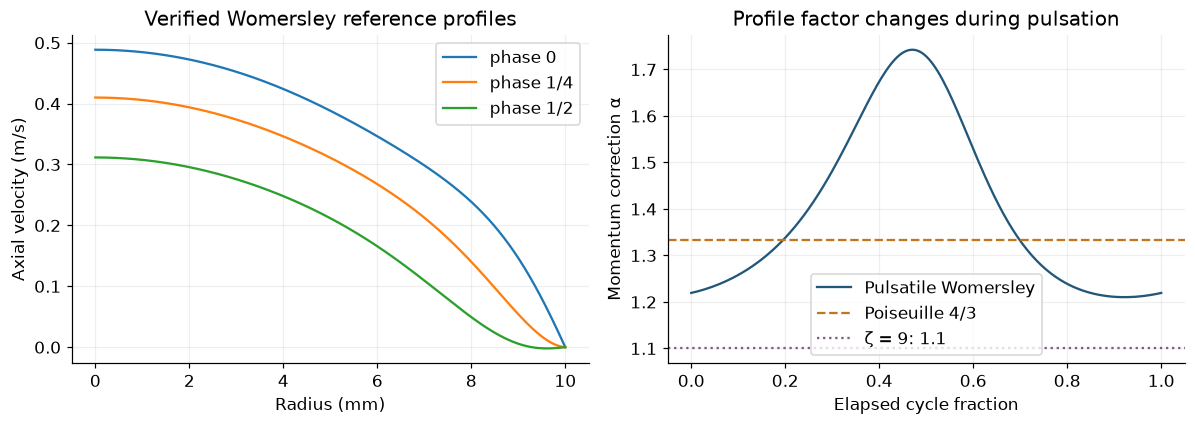

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11,4))
for index, label in [(0,'phase 0'),(50,'phase 1/4'),(100,'phase 1/2')]:
    axes[0].plot(verification_wom['r']*1000, verification_wom['velocity'][index], label=label)
axes[0].set(xlabel='Radius (mm)',ylabel='Axial velocity (m/s)',title='Verified Womersley reference profiles')
axes[0].legend()
axes[1].plot(verification_t/PERIOD, verification_wom['alpha'],color=COLORS['main'],label='Pulsatile Womersley')
axes[1].axhline(4/3,color=COLORS['reference'],ls='--',label='Poiseuille 4/3')
axes[1].axhline(1.1,color=COLORS['alternate'],ls=':',label='ζ = 9: 1.1')
axes[1].set(xlabel='Elapsed cycle fraction',ylabel='Momentum correction α',title='Profile factor changes during pulsation')
axes[1].legend()
save_figure('verification_profiles')

**Interpretation checkpoint.** A changing α in this straight reference already shows that pulsatility alone can violate the assumption of one fixed profile factor. Curvature is therefore not required for A3 to be questionable. Conversely, these curves do not establish the actual aortic α: that needs the interior data analysed below.

**Interpretation.** Straight-tube reference can have a time-varying α even with no curvature. A constant profile is therefore a modelling approximation. Exact analytic momentum closure verifies sign and unit conventions; finite-difference residuals also include discretization error. Mesh and spacing sensitivity remain necessary for patient estimates.

### Project 2 core verification: filled 3D pulsatile tube

This explicitly **analytic 3D verification case** executes filled-volume slicing, A/Q/mean P/velocity profiles, secondary-flow and pressure-uniformity maps, α and friction references, and the complete momentum balance. It provides testable expected values for the core pipeline. It is not patient CFD and does not supply evidence about aortic bends or stenoses.

A wedge volume mesh carries the exact straight-tube Womersley velocity sampled at mesh nodes. Pressure is uniform per section with analytic axial gradient. VTK then interpolates piecewise-linear fields. Flux/profile error measures spatial sampling error; wall force is independently reconstructed from volume gradients. Residual therefore includes interpolation, near-wall-gradient and finite-difference errors. Signed Womersley friction used below is explicitly distinguished from gradient reconstruction.

**An end-to-end check of the same workflow.** We put analytical pressure and velocity onto a filled 3D mesh, cut several sections, and recover flow, pressure uniformity, α and wall force. A straight fully developed solution should not acquire secondary flow or transverse pressure differences from our processing. Its spatially uniform flow should also satisfy mass balance. Small errors here measure discretisation/interpolation effects, because the reference solution is known. We use this before attributing any discrepancy in the aorta to physiology.

In [10]:
example_t=np.linspace(0,PERIOD,41)
example_s=np.linspace(.03,.17,8)
example_R=.01
example_ref=womersley_reference(example_t,.2+.08*np.cos(2*np.pi*example_t/PERIOD),example_R,NU,PERIOD,harmonics=1,nr=1001)
example_mesh=verification_tube(radius=example_R,nr=120,ntheta=96,nz=7)
example_r=np.linalg.norm(example_mesh.points[:,:2],axis=1)
example_wall=example_mesh.extract_surface(algorithm='dataset_surface')
example_contour=wall_loop(example_wall,np.array([0.,0,.1]),np.array([0.,0,1.]))
example_fields={key:np.zeros((len(example_t),len(example_s))) for key in ['A','Q','P','alpha','secondary_ratio','pressure_range','friction']}
example_profiles=[]
for j in range(len(example_t)):
    speed=np.interp(example_r,example_ref['r'],example_ref['velocity'][j])
    example_mesh['velocity']=np.c_[np.zeros((example_mesh.n_points,2)),speed]
    example_mesh['pressure']=10000+RHO*example_ref['pressure_gradient_over_rho'][j]*example_mesh.points[:,2]
    gradients=example_mesh.compute_derivative(scalars='velocity',gradient='gradient',preference='point')
    f_gradient=signed_wall_force(gradients,example_contour,np.array([0.,0,1.]),NU)
    for i,ss in enumerate(example_s):
        section=section_from_volume(example_mesh,np.array([0.,0,ss]),np.array([0.,0,1.]))
        metrics=section_metrics(section,np.array([0.,0,1.]))
        for key in metrics:
            if key in example_fields: example_fields[key][j,i]=metrics[key]
        example_fields['friction'][j,i]=f_gradient
        if i==4 and j in [0,10,20]:
            example_profiles.append((j,np.linalg.norm(section.points[:,:2],axis=1),section['velocity'][:,2]))
example_measured=balance_terms(example_t,example_s,example_fields['A'],example_fields['Q'],example_fields['P'],example_fields['alpha'],example_fields['friction'],RHO)
example_model=balance_terms(example_t,example_s,example_fields['A'],example_fields['Q'],example_fields['P'],4/3,8*np.pi*NU*example_fields['Q']/example_fields['A'],RHO)
flux_error=np.max(np.abs(example_fields['Q'][:,0]/(np.pi*example_R**2*example_ref['U'])-1))
alpha_error=np.max(np.abs(example_fields['alpha'][:,0]/example_ref['alpha']-1))
force_error=np.max(np.abs(example_fields['friction'][:,0]-example_ref['friction']))/np.max(np.abs(example_ref['friction']))
assert flux_error<.01 and alpha_error<.02 and force_error<.1
assert np.max(np.abs(example_fields['secondary_ratio']))<1e-12
assert np.max(np.abs(example_fields['pressure_range']))<1e-8
print(f'3D verification: flux error {100*flux_error:.3f}%; alpha error {100*alpha_error:.3f}%; peak-scaled wall-force error {100*force_error:.3f}%.')
print(f'Measured-gradient normalized residual maximum: {np.nanmax(example_measured["normalized"]):.3f}; constant Poiseuille closure: {np.nanmax(example_model["normalized"]):.3f}.')
pd.DataFrame([{'time_s':example_t[j],'s_m':example_s[i],**{key:value[j,i] for key,value in example_fields.items()},'measured_residual':example_measured['residual'][j,i],'model_residual':example_model['residual'][j,i]}
              for j in range(len(example_t)) for i in range(len(example_s))]).to_csv(EXPORT/'verification_3d_sections.csv',index=False)

3D verification: flux error 0.078%; alpha error 0.016%; peak-scaled wall-force error 3.837%.
Measured-gradient normalized residual maximum: 0.011; constant Poiseuille closure: 0.997.


**How to read the verification panels.** The profile panel checks radial shape. The α panel checks recovery of momentum flux. The friction panel tests the wall derivative, while the residual panel checks whether all signed terms cancel together. The additional secondary-flow/pressure maps should remain near zero throughout this straight tube. Their horizontal coordinate is section position and vertical coordinate is time within the test cycle. A persistent structure in these maps would point to a processing error before we even load the aorta.

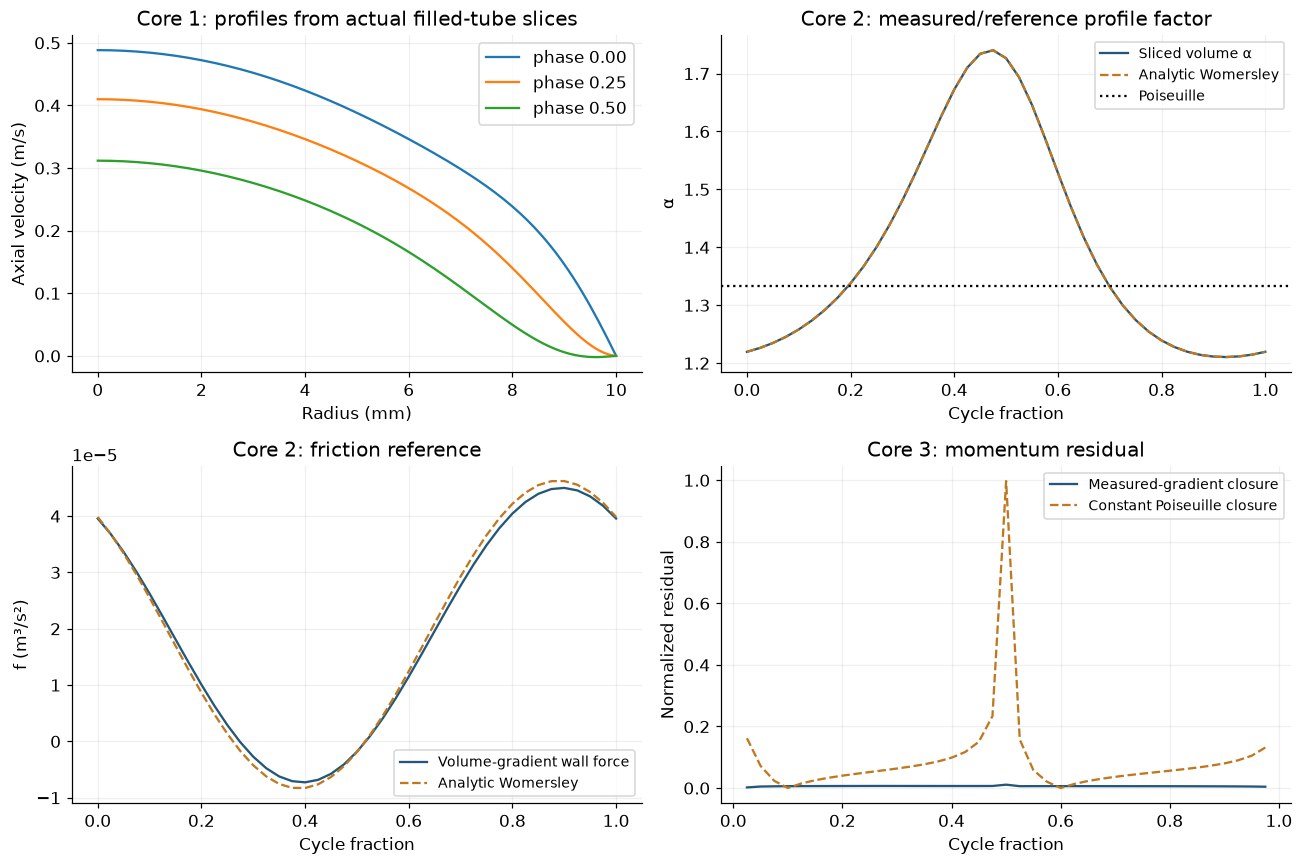

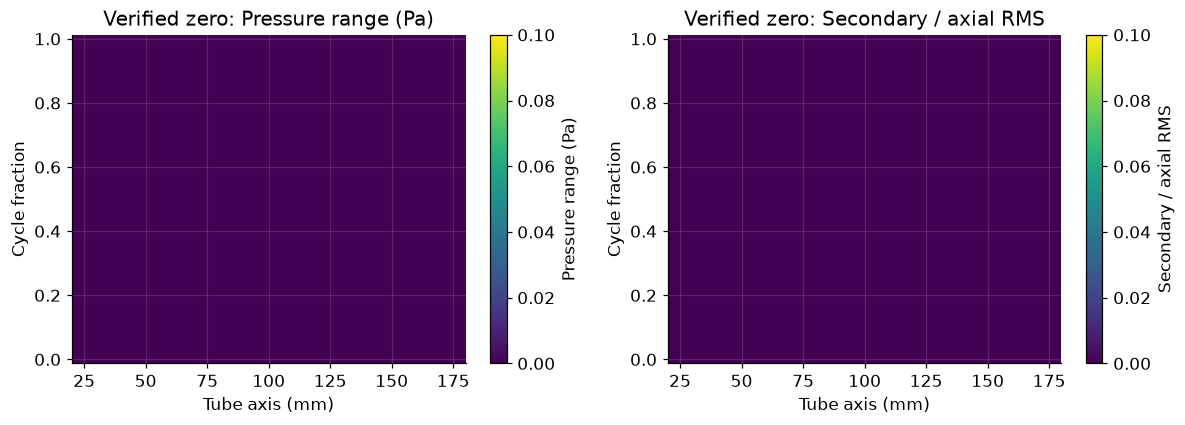

In [11]:
fig,axes=plt.subplots(2,2,figsize=(12,8))
for j,radial,speed in example_profiles:
    ids=np.argsort(radial)
    axes[0,0].plot(radial[ids]*1000,speed[ids],label=f'phase {example_t[j]/PERIOD:.2f}')
axes[0,0].set(xlabel='Radius (mm)',ylabel='Axial velocity (m/s)',title='Core 1: profiles from actual filled-tube slices');axes[0,0].legend()
axes[0,1].plot(example_t/PERIOD,example_fields['alpha'][:,0],label='Sliced volume α',color=COLORS['main'])
axes[0,1].plot(example_t/PERIOD,example_ref['alpha'],ls='--',label='Analytic Womersley',color=COLORS['reference'])
axes[0,1].axhline(4/3,color='black',ls=':',label='Poiseuille');axes[0,1].set(xlabel='Cycle fraction',ylabel='α',title='Core 2: measured/reference profile factor');axes[0,1].legend(fontsize=9)
axes[1,0].plot(example_t/PERIOD,example_fields['friction'][:,0],label='Volume-gradient wall force',color=COLORS['main'])
axes[1,0].plot(example_t/PERIOD,example_ref['friction'],ls='--',label='Analytic Womersley',color=COLORS['reference'])
axes[1,0].set(xlabel='Cycle fraction',ylabel='f (m³/s²)',title='Core 2: friction reference');axes[1,0].legend(fontsize=9)
axes[1,1].plot(example_t/PERIOD,example_measured['normalized'][:,3],label='Measured-gradient closure',color=COLORS['main'])
axes[1,1].plot(example_t/PERIOD,example_model['normalized'][:,3],ls='--',label='Constant Poiseuille closure',color=COLORS['reference'])
axes[1,1].set(xlabel='Cycle fraction',ylabel='Normalized residual',title='Core 3: momentum residual');axes[1,1].legend(fontsize=9)
save_figure('verification_3d_core_work')
fig,axes=plt.subplots(1,2,figsize=(11,4))
for ax,key,label in zip(axes,['pressure_range','secondary_ratio'],['Pressure range (Pa)','Secondary / axial RMS']):
    im=ax.pcolormesh(example_s*1000,example_t/PERIOD,example_fields[key],shading='auto',cmap='viridis',vmin=0,vmax=.1)
    ax.set(xlabel='Tube axis (mm)',ylabel='Cycle fraction',title='Verified zero: '+label)
    fig.colorbar(im,ax=ax,label=label)
save_figure('verification_3d_uniformity_maps')

**What a successful verification looks like.** Recovered flow and α follow the analytical reference; secondary velocity and transverse pressure range remain near zero. The gradient-based friction is more resolution-sensitive than flow. A small residual here supports the calculation in a controlled setting. The aorta adds curvature, branches and developing profiles that this verification deliberately does not represent.

### Manufactured narrowing: test variable-area momentum terms

This is a **constructed 1D consistency check**, not CFD or a patient stenosis. Smooth radius reduction creates a strong convective term. Pressure is constructed from the chosen momentum equation, so a small residual checks implementation only; it cannot prove that the closure describes real stenosis flow. Curvature/stenosis losses require actual 3D volume evidence.

**Why manufacture a narrowing?** In a steady incompressible tube, the same $Q$ passes through every section, so a smaller area raises $U=Q/A$ and changes the convective momentum flux $\alpha Q^2/A$. We choose an area and flow, then construct a pressure gradient that balances the prescribed convective and friction terms. The numerical residual should approach zero for that constructed solution. This tests variable-area bookkeeping without claiming to simulate a stenotic jet, separation or a new 3D anatomy. The physical motivation is the course's distinction between acceleration, viscous loss and downstream separation in a stenosis ([dynamic circulation, PDF pp. 28–29](sources/course/dynamic_circulation.pdf#page=28)).

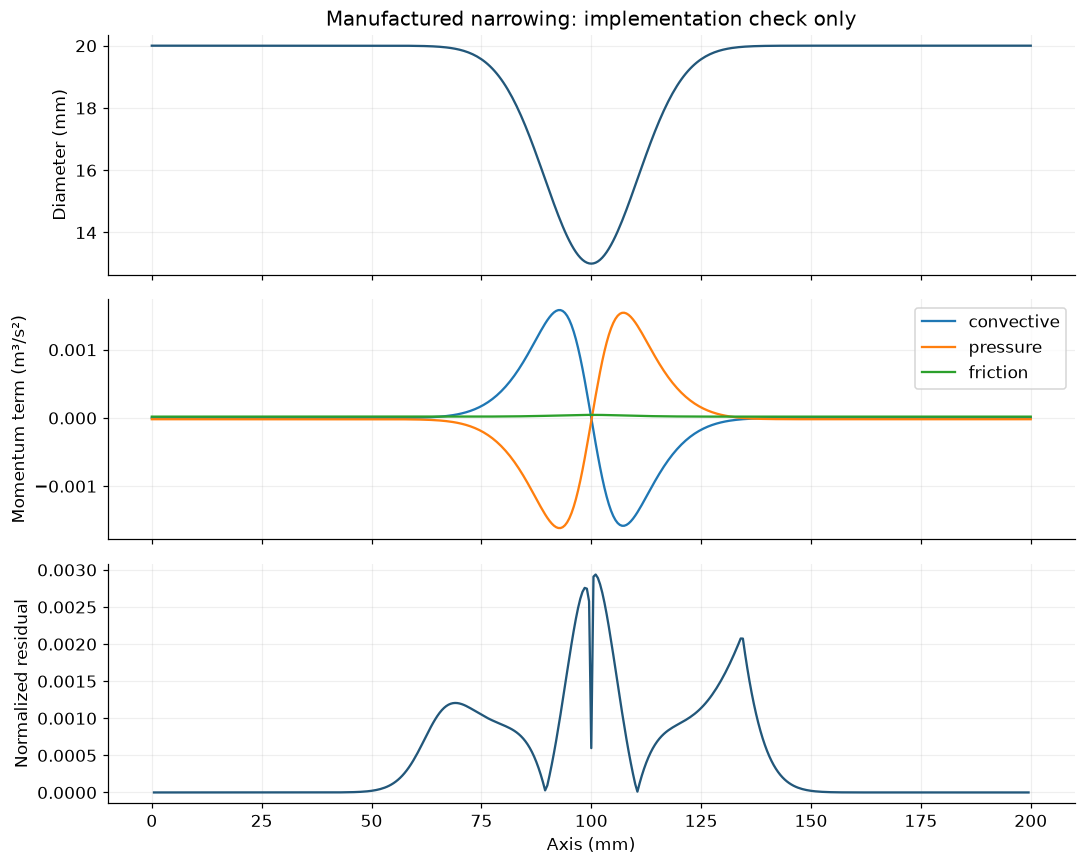

In [12]:
from scipy.integrate import cumulative_trapezoid
narrow_s=np.linspace(0,.2,401)
narrow_t=np.linspace(0,PERIOD,9)
narrow_R=.01*(1-.35*np.exp(-((narrow_s-.1)/.015)**2))
narrow_A=np.tile(np.pi*narrow_R**2,(len(narrow_t),1))
narrow_Q=np.full_like(narrow_A,np.pi*.01**2*.2)
narrow_f=8*np.pi*NU*narrow_Q/narrow_A
convective=np.gradient((4/3)*narrow_Q[0]**2/narrow_A[0],narrow_s,edge_order=2)
pressure_gradient=-RHO*(convective+narrow_f[0])/narrow_A[0]
narrow_P=np.tile(10000+cumulative_trapezoid(pressure_gradient,narrow_s,initial=0),(len(narrow_t),1))
narrow_terms=balance_terms(narrow_t,narrow_s,narrow_A,narrow_Q,narrow_P,4/3,narrow_f,RHO)
assert np.nanmax(narrow_terms['normalized'])<.02
fig,axes=plt.subplots(3,1,sharex=True,figsize=(10,8))
axes[0].plot(narrow_s*1000,narrow_R*2000,color=COLORS['main']);axes[0].set(ylabel='Diameter (mm)',title='Manufactured narrowing: implementation check only')
for key in ['convective','pressure','friction']: axes[1].plot(narrow_s*1000,narrow_terms[key][4],label=key)
axes[1].set(ylabel='Momentum term (m³/s²)');axes[1].legend()
axes[2].plot(narrow_s*1000,narrow_terms['normalized'][4],color=COLORS['main']);axes[2].set(xlabel='Axis (mm)',ylabel='Normalized residual')
save_figure('manufactured_narrowing_balance')

**Read the narrowing figure as a consistency test.** The area depression increases mean velocity while steady flow remains constant. The constructed pressure gradient supplies the balancing term. A near-zero residual is expected because pressure was constructed from that balance; it is not independent evidence that a 1D model predicts a real stenosis correctly.

## 4. Load anatomy and map simulation surfaces

We map model face labels to results by **GlobalElementID**, which avoids ambiguous nearest-node matches where wall and cap share coordinates. Bare result geometry carries original point IDs; extracting it does not copy hundreds of field arrays. Cap normals are outward from fluid; `Qin = -∫u·nout dA`, outlet flows use the opposite sign.

**Why map face identifiers instead of trusting file order?** The model and results can store triangles in different orders. Matching their `GlobalElementID` values transfers anatomical labels explicitly: one inlet, three arch branches, a descending outlet and the wall. The cap normals are oriented out of the domain; inlet flow is then sign-adjusted for a readable positive inflow convention. A wrong label or normal would corrupt the later mass balance even if the velocity values themselves were correct. This implements the conservation bookkeeping from [steady flow, slides 11–12 and 31](sources/course/steady_flow.pptx).

In [13]:
units = Units()
model = pv.read(DATA / 'Models' / '0095_0001.vtp')
model.points = np.asarray(model.points, dtype=float) * units.length
wall = model.threshold([.9,1.1],scalars='ModelFaceID',preference='cell').extract_surface(algorithm='dataset_surface').clean()
surface_results = pv.read(SURFACE_FILE)
result_geometry = pv.PolyData(np.asarray(surface_results.points,dtype=float)*units.length,
                              surface_results.faces)
result_geometry['source_point_id'] = np.arange(result_geometry.n_points)
face_lookup = dict(zip(model.cell_data['GlobalElementID'].astype(int),
                       model.cell_data['ModelFaceID'].astype(int)))
result_ids = surface_results.cell_data['GlobalElementID'].astype(int)
if len(set(result_ids)) != len(result_ids) or set(result_ids) != set(face_lookup):
    raise ValueError('Result/model element IDs do not match uniquely.')
result_geometry.cell_data['ModelFaceID'] = np.array([face_lookup[x] for x in result_ids])
result_wall = result_geometry.threshold([.9,1.1],scalars='ModelFaceID',preference='cell').extract_surface(algorithm='dataset_surface')
wall_indices = np.asarray(result_wall['source_point_id'],int)
caps = {}
for name,fid in CAP_IDS.items():
    cap = result_geometry.threshold([fid-.1,fid+.1],scalars='ModelFaceID',preference='cell').extract_surface(algorithm='dataset_surface')
    normal,center = outward_cap_normal(cap,wall)
    caps[name] = {'mesh':cap,'normal':normal,'center':center,
                  'indices':np.asarray(cap['source_point_id'],int)}
cap_table = pd.DataFrame([{'cap':name,'area_mm2':item['mesh'].area*1e6,
                          'normal_x':item['normal'][0],'normal_y':item['normal'][1],
                          'normal_z':item['normal'][2]}
                         for name,item in caps.items()])
display(cap_table.round(3))
print(f'Anatomy: {model.n_cells:,} surface triangles. Result wall: {result_wall.n_points:,} points.')

,cap,area_mm2,normal_x,normal_y,normal_z
0,inflow,454.693,-0.186,-0.306,-0.934
1,btrunk,143.909,0.606,0.388,0.695
2,carotid,35.883,-0.410,-0.007,0.912
3,subclavian,61.909,-0.744,-0.008,0.668
4,outflow,268.201,0.122,0.262,-0.957


Anatomy: 173,052 surface triangles. Result wall: 84,282 points.


### VMTK centerline: reproducible cache plus independent supplied-path comparison

VMTK caps the five open profiles, finds inlet and descending outlet by cap-center distance, and uses noninteractive `profileidlist` seeds. This avoids snapping a cap-center coordinate to an open rim. A topology-preserving 80% decimation and 30 gentle smoothing iterations reduce cost/noise. Cache records input hash and parameters. Change them or set `RECOMPUTE_CENTERLINE=True` to extract again.

Resampling is by arc length. End regions and branch neighborhoods are excluded from 1D closure comparisons. The provided SimVascular path is a comparison, not silently substituted for VMTK output.

**Why use a checked centreline cache?** Extraction can be slow and small geometry changes can move cutting planes. The saved path is reused only when its input hash and settings agree. Resampling converts the path into stations, tangents and curvature; branch-root positions then define where an unbranched 1D balance is inappropriate. The distance from the supplied path is a consistency check between constructions, not a measured error against a known true centreline.

In [14]:
cache_path = BASE / 'data' / 'centerline_vmtk.vtp'
cache_meta = cache_path.with_suffix('.json')
cache_signature = {'surface_sha256':sha256_file(DATA/'Models'/'0095_0001.vtp'),
                   'length_scale':units.length,'decimation':.8,'smoothing_iterations':30,
                   'smoothing_factor':.1,'seed_method':'profileidlist'}
cache_valid = (cache_path.exists() and cache_meta.exists() and
               json.loads(cache_meta.read_text()) == cache_signature)
if RECOMPUTE_CENTERLINE or not cache_valid:
    centerline_points, centerline_mesh = extract_vmtk_path(wall,caps['inflow']['center'],
                                                          caps['outflow']['center'],cache_path)
    cache_meta.write_text(json.dumps(cache_signature,indent=2))
else:
    centerline_mesh = pv.read(cache_path)
    centerline_points = centerline_mesh.get_cell(0).points
    if np.linalg.norm(centerline_points[0]-caps['inflow']['center']) > np.linalg.norm(centerline_points[-1]-caps['inflow']['center']):
        centerline_points = centerline_points[::-1]
s, station_xyz, tangents, curvature = resample_path(centerline_points,SPACING,TRIM)
provided_path = read_sv_path(DATA/'Paths'/'aorta.pth')
path_distance = cKDTree(provided_path).query(station_xyz)[0]
# Branch root = point on supplied branch path nearest main centerline.
branch_locations = {}
for name in ['btrunk','carotid','subclavian']:
    branch_path = read_sv_path(DATA/'Paths'/f'{name}.pth')
    dist,ids = cKDTree(station_xyz).query(branch_path)
    branch_locations[name] = float(s[ids[np.argmin(dist)]])
branch_mask = np.zeros(len(s),bool)
for root_s in branch_locations.values(): branch_mask |= np.abs(s-root_s)<BRANCH_EXCLUSION
print(f'{len(s)} stations; median distance to supplied path {np.median(path_distance)*1000:.2f} mm.')
display(pd.DataFrame({'branch':branch_locations.keys(), 'projected_root_s_mm':np.array(list(branch_locations.values()))*1000}))

62 stations; median distance to supplied path 1.06 mm.


,branch,projected_root_s_mm
0,btrunk,58.999611
1,carotid,66.999540
2,subclavian,82.999399


**How to read the anatomy preview.** The vessel surface supplies context, the path identifies the main route, and the cap positions distinguish entry and exits. Follow the path through the arch before trusting “upstream” and “downstream” plots. The preview uses Matplotlib for portability; PyVista still supplies the actual geometry. A projected image cannot prove that every section is inside the lumen, so connected-component checks and contour tests remain necessary.

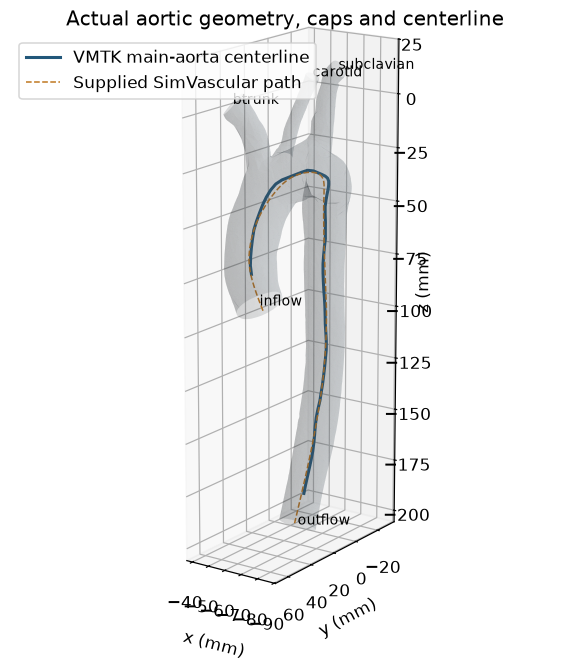

In [15]:
# Matplotlib preview uses actual PyVista geometry; portable and no OpenGL requirement.
fig = plt.figure(figsize=(10,6)); ax = fig.add_subplot(projection='3d')
plot_surface = wall.decimate_pro(.96,preserve_topology=True)
tri = plot_surface.faces.reshape(-1,4)[:,1:]
ax.plot_trisurf(*plot_surface.points.T*1000,triangles=tri,alpha=.17,color=COLORS['muted'],linewidth=0)
ax.plot(*station_xyz.T*1000,color=COLORS['main'],lw=2,label='VMTK main-aorta centerline')
ax.plot(*provided_path.T*1000,color=COLORS['reference'],ls='--',lw=1,label='Supplied SimVascular path')
for name,item in caps.items(): ax.text(*(item['center']*1000),name,fontsize=9)
ax.set(xlabel='x (mm)',ylabel='y (mm)',zlabel='z (mm)',title='Actual aortic geometry, caps and centerline')
ax.set_box_aspect(np.ptp(wall.points,axis=0)); ax.view_init(elev=16,azim=125)
ax.legend(loc='upper left'); save_figure('aorta_geometry')

### Perpendicular sections from the wall contour

A filled volume slice is required for interior field integration. With surface data, a closed planar wall contour still gives polygon area and perimeter. Some planes cross two aortic limbs: retain nearest connected contour. Open or branched contours fail visibly. Branch masks are geometric heuristics; inspect the geometry and masks before interpreting local closure.

**Why report two diameters and curvature?** Area-equivalent diameter $D_A=2\sqrt{A/\pi}$ is the diameter of a circle with the same area; hydraulic diameter $D_h=4A/P_w$ also incorporates wetted perimeter $P_w$. They coincide for a circle, but need not for an irregular section. The circular reference profiles use the equivalent radius as an approximation. Curvature $\kappa$ describes turning of the path; $1/\kappa$ is the local bending radius where curvature is nonzero.

The shaded intervals in the following plots are branch exclusions. They identify locations where a section may intersect a junction and a single-tube derivative would omit side-branch momentum. Smaller diameter alone does not diagnose a stenosis in this documented healthy model. The importance of lumen geometry is explained in [computational haemodynamics, PDF pp. 12–13](sources/course/computational_haemodynamics.pdf#page=12).

47/62 stations eligible outside branch masks.
Contour failures: [(11, 'Open/branched wall contour; exclude this station.')] (1 total)


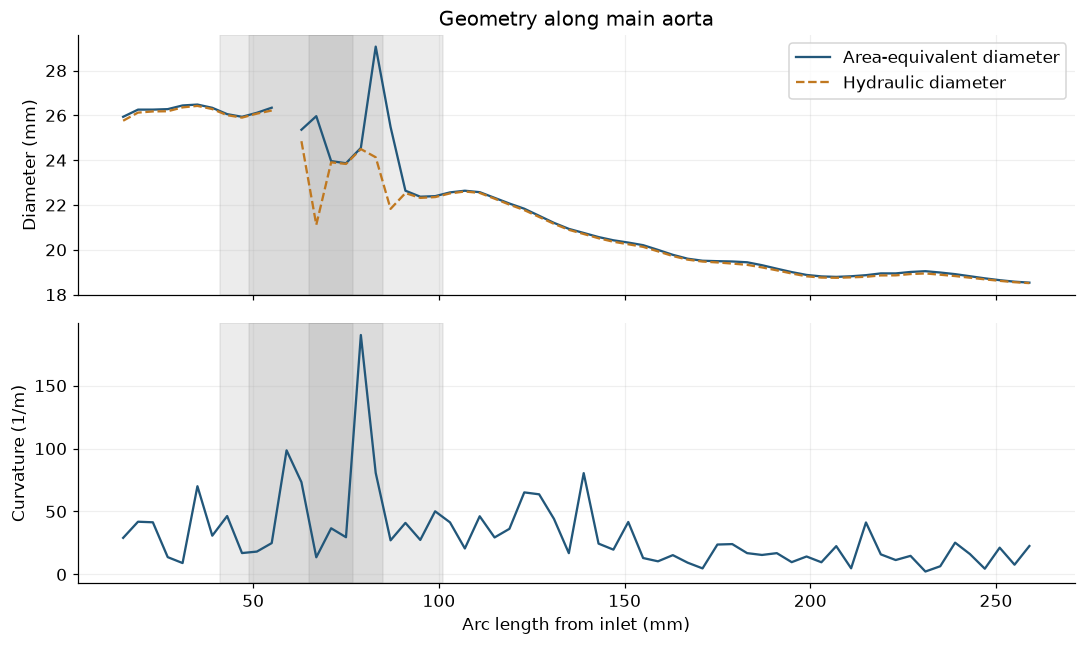

In [16]:
contours = []
area = np.full(len(s),np.nan)
perimeter = np.full(len(s),np.nan)
contour_errors = []
for i,(origin,normal) in enumerate(zip(station_xyz,tangents)):
    try:
        contour = wall_loop(wall,origin,normal)
        contours.append(contour)
        area[i],perimeter[i] = contour[2],contour[1].sum()
    except ValueError as error:
        contours.append(None); contour_errors.append((i,str(error)))
valid_geometry = np.isfinite(area) & ~branch_mask
radius = np.sqrt(area/np.pi)
diameter = 2*radius
hydraulic_diameter = 4*area/perimeter
circularity = 4*np.pi*area/perimeter**2
geometry_table = pd.DataFrame({'s_m':s,'A_m2':area,'perimeter_m':perimeter,
                              'diameter_m':diameter,'hydraulic_diameter_m':hydraulic_diameter,
                              'curvature_per_m':curvature,'circularity':circularity,
                              'branch_excluded':branch_mask,'usable':valid_geometry,
                              'path_difference_m':path_distance})
geometry_table.to_csv(EXPORT/'geometry.csv',index=False)
print(f'{valid_geometry.sum()}/{len(s)} stations eligible outside branch masks.')
print('Contour failures:',contour_errors[:8],f'({len(contour_errors)} total)')
fig,axes = plt.subplots(2,1,sharex=True,figsize=(10,6))
axes[0].plot(s*1000,diameter*1000,color=COLORS['main'],label='Area-equivalent diameter')
axes[0].plot(s*1000,hydraulic_diameter*1000,color=COLORS['reference'],ls='--',label='Hydraulic diameter')
axes[0].set(ylabel='Diameter (mm)',title='Geometry along main aorta');axes[0].legend()
axes[1].plot(s*1000,curvature,color=COLORS['main']);axes[1].set(xlabel='Arc length from inlet (mm)',ylabel='Curvature (1/m)')
for ax in axes:
    for value in branch_locations.values(): ax.axvspan((value-BRANCH_EXCLUSION)*1000,(value+BRANCH_EXCLUSION)*1000,color='grey',alpha=.15)
save_figure('geometry_along_aorta')

**Before proceeding:** locate the arch in the curvature plot, identify excluded branch intervals, and compare the two diameter definitions. These observations tell you where straight circular-tube references are least representative. The default geometry admits **47 of 62** stations for the actual volume analysis; exclusions are part of the reported evidence boundary.

## 5. Actual CFD surface results: final complete cardiac cycle

Array suffixes are solver-step indices. We use `time = step × DT`, not the array count or an invented frame rate. Steps 10040–11040 cover one full 0.937 s interval, with output every five solver steps. Cycle can start at any phase. Derivatives use actual times. Boundary comparison uses absolute source time modulo PERIOD.

**Why use a complete cardiac cycle?** Cycle averages require a defined duration, and the pulsatile comparisons need every phase. Array names contain solver-step numbers; multiplying by `DT` gives physical time. The code selects the last complete interval, checks that saved frames are not missing, and measures elapsed time from the start of that interval. Thus “cycle fraction 0” is an indexing origin, not an independently identified valve-opening event.

The course recommends discarding startup transients and demonstrating repeatability between successive cycles ([computational haemodynamics, PDF p. 28](sources/course/computational_haemodynamics.pdf#page=28)). We have one supplied complete cycle. Selecting it supports consistent post-processing but does not demonstrate cycle-to-cycle convergence.

In [17]:
all_steps = np.array(sorted(int(re.fullmatch(r'velocity_(\d+)',x).group(1))
                           for x in surface_results.point_data if re.fullmatch(r'velocity_(\d+)',x)))
chosen, cycle_t = full_cycle_indices(all_steps,DT,PERIOD)
steps = all_steps[chosen]
if any(f'vWSS_{step}' not in surface_results.point_data for step in steps):
    raise ValueError('Missing WSS frame for selected velocity cycle.')
absolute_t = steps*DT
print(f'{len(steps)} snapshots; absolute time {absolute_t[0]:.5f}–{absolute_t[-1]:.5f} s; dt={np.median(np.diff(cycle_t)):.6f} s.')
flows = {}
for name,item in caps.items():
    flow = []
    for step in steps:
        velocity = np.asarray(surface_results[f'velocity_{step}'])[item['indices']]*units.velocity
        flux = integrate_linear(item['mesh'],velocity @ item['normal'])
        flow.append(-flux if name=='inflow' else flux)
    flows[name] = np.array(flow)
flow_table = pd.DataFrame({'time_s':cycle_t,'source_time_s':absolute_t,'solver_step':steps,**flows})
flow_table.to_csv(EXPORT/'cap_flows_m3_s.csv',index=False)
flow_balance = flows['inflow']-sum(flows[name] for name in CAP_IDS if name!='inflow')
flow_scale = np.max(np.abs(flows['inflow']))
mass_relative = flow_balance/flow_scale
cycle_volumes = {name:np.trapezoid(flow,cycle_t) for name,flow in flows.items()}
cycle_mass_error = (cycle_volumes['inflow']-sum(cycle_volumes[name] for name in CAP_IDS if name!='inflow')) / max(abs(cycle_volumes['inflow']),1e-12)
display(pd.DataFrame([{'cap':name,'mean_mL_s':volume/PERIOD*1e6,
                      'cycle_volume_mL':volume*1e6,'peak_mL_s':flows[name].max()*1e6}
                     for name,volume in cycle_volumes.items()]).round(3))
print(f'Global mass: peak-normalized maximum mismatch {np.max(np.abs(mass_relative))*100:.3f}%; integrated signed mismatch {cycle_mass_error*100:.3f}%.')

201 snapshots; absolute time 9.40748–10.34448 s; dt=0.004685 s.


,cap,mean_mL_s,cycle_volume_mL,peak_mL_s
0,inflow,96.666,90.576,501.955
1,btrunk,21.461,20.109,139.257
2,carotid,6.083,5.700,33.359
3,subclavian,11.754,11.014,56.674
4,outflow,57.368,53.754,279.554


Global mass: peak-normalized maximum mismatch 0.000%; integrated signed mismatch -0.000%.


**Why check mass before momentum?** With constant density and rigid walls, the model cannot store changing blood volume. At each instant, inlet flow should equal the sum of outlet flows. This tests cap labels, normals, units and surface integration together. Inside an unbranched part of the vessel, section flow should be consistent; after a branch, main-vessel flow should decrease by that branch's signed outflow. A fall across a branch is expected conservation, not leakage. This is Kirchhoff's flow balance expressed on CFD surfaces ([steady flow, slides 11 and 31](sources/course/steady_flow.pptx); [dynamic circulation, PDF pp. 7–8](sources/course/dynamic_circulation.pdf#page=7)).

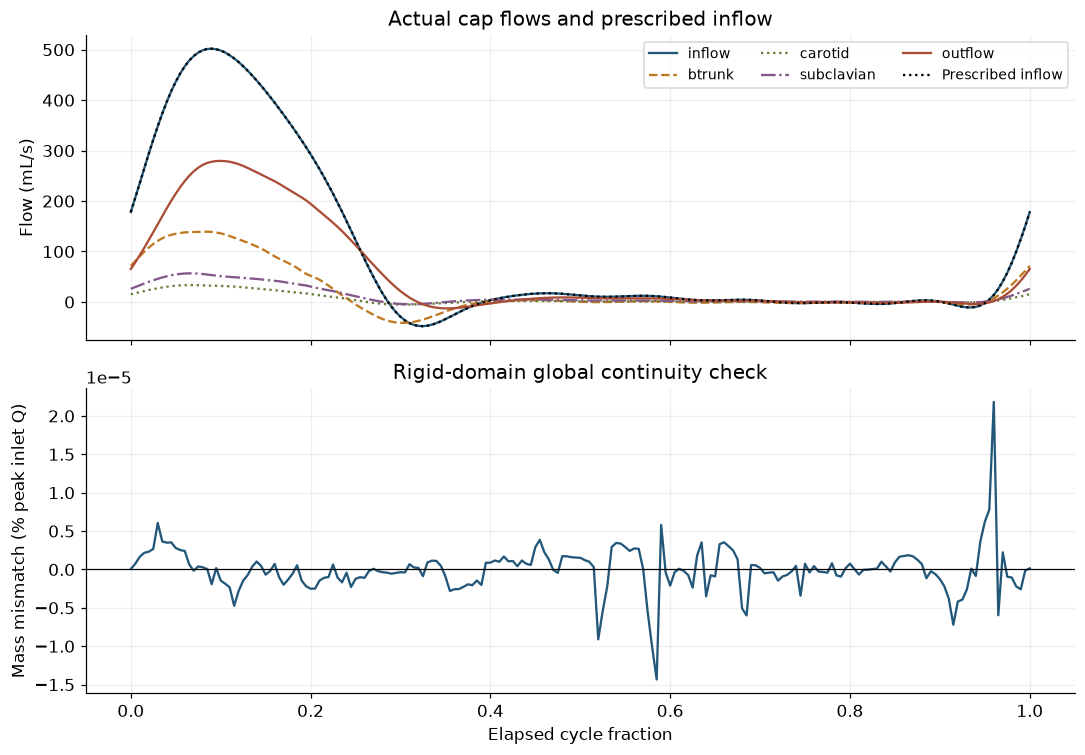

Cap-flow endpoint mismatch norm / peak inlet flow: 0.032%.
One supplied cycle permits an endpoint check; cycle-to-cycle convergence cannot be proved.


In [18]:
inflow_input = np.loadtxt(DATA/'Simulations'/'0095_0001'/'inflow.flow')
# In SimVascular preprocessing inflow is negative with respect to outward normal.
input_flow = -np.interp(np.mod(absolute_t,PERIOD),inflow_input[:,0],inflow_input[:,1])*1e-6
fig,axes=plt.subplots(2,1,sharex=True,figsize=(10,7))
cap_colors=['#22577A','#C07820','#677B36','#815887','#AA4D37']
cap_styles=['-','--',':','-.','-']
for (name,flow),color,style in zip(flows.items(),cap_colors,cap_styles):
    axes[0].plot(cycle_t/PERIOD,flow*1e6,label=name,color=color,ls=style)
axes[0].plot(cycle_t/PERIOD,input_flow*1e6,color='black',ls=':',label='Prescribed inflow')
axes[0].set(ylabel='Flow (mL/s)',title='Actual cap flows and prescribed inflow');axes[0].legend(ncol=3,fontsize=9)
axes[1].plot(cycle_t/PERIOD,mass_relative*100,color=COLORS['main'])
axes[1].axhline(0,color='black',lw=.8)
axes[1].set(xlabel='Elapsed cycle fraction',ylabel='Mass mismatch (% peak inlet Q)',title='Rigid-domain global continuity check')
save_figure('actual_cap_flows_mass')
endpoint_error=np.linalg.norm(np.array([flows[n][-1]-flows[n][0] for n in CAP_IDS]))/max(flow_scale,1e-12)
print(f'Cap-flow endpoint mismatch norm / peak inlet flow: {100*endpoint_error:.3f}%.')
print('One supplied cycle permits an endpoint check; cycle-to-cycle convergence cannot be proved.')

**Observed result and its meaning.** In the verified default run, maximum global imbalance is approximately **0.0000218% of peak inlet flow**. That very small value supports consistent flux bookkeeping. It does not show that outlet conditions reproduce the real patient's flow split; agreement with an imposed inlet waveform is primarily a consistency check on this simulation. The course distinguishes such verification from comparison with independent measurements ([computational haemodynamics, PDF p. 29](sources/course/computational_haemodynamics.pdf#page=29)).

**Read this check first.** Small total cap imbalance supports consistent cap mapping, orientation and rigid global conservation. It does not verify every interior slice. A branched aorta does not have constant Q from inlet to descending outlet. Agreement with prescribed inflow also checks the cm³/s → m³/s conversion and time-step interpretation. Reverse flow retains its sign.

### Wall shear: TAWSS, OSI and transparent spatial weighting

$$TAWSS=T^{-1}\int_0^T|\boldsymbol\tau_w(t)|dt,$$
$$OSI=\tfrac12\left(1-\frac{|\int_0^T\boldsymbol\tau_w(t)dt|}{\int_0^T|\boldsymbol\tau_w(t)|dt}\right).$$

TAWSS measures cycle-average shear magnitude; OSI measures directional cancellation (0–0.5). RRT is $1/[(1-2OSI)TAWSS]$, a shear-derived index in Pa⁻¹, not a physical residence time. Near-zero denominator is unavailable, not zero. Caps are excluded. Nodal histograms are labelled nodal; the summary mean is surface-area weighted. This describes simulated wall loading, not clinical classification.

**What do the wall metrics retain?** TAWSS averages shear **magnitude** over time, describing the size of tangential wall loading. OSI compares the magnitude of the time-integrated vector with the integrated magnitudes: steady directional loading gives 0, while complete directional cancellation gives 0.5. RRT combines those quantities into a reciprocal-shear index; it is not a simulated particle travel time. Time weights implement a trapezoidal integral over the saved snapshots.

The wall alone is used because caps are artificial boundaries. Area weighting is essential for a mean over the wall: dense mesh patches should not count as larger physical regions. Shear itself depends on a velocity derivative and therefore needs near-wall resolution ([steady flow, slide 51](sources/course/steady_flow.pptx); [computational haemodynamics, PDF p. 17](sources/course/computational_haemodynamics.pdf#page=17)). The OSI/RRT definitions here are post-processing choices, not clinical thresholds supplied by the course.

In [19]:
weights = np.empty(len(cycle_t))
weights[0]=(cycle_t[1]-cycle_t[0])/2;weights[-1]=(cycle_t[-1]-cycle_t[-2])/2
weights[1:-1]=(cycle_t[2:]-cycle_t[:-2])/2
integral_magnitude=np.zeros(result_wall.n_points)
integral_vector=np.zeros((result_wall.n_points,3))
for w,step in zip(weights,steps):
    tau=np.asarray(surface_results[f'vWSS_{step}'])[wall_indices]*units.shear
    integral_magnitude += w*np.linalg.norm(tau,axis=1)
    integral_vector += w*tau
TAWSS=integral_magnitude/PERIOD
ratio=np.divide(np.linalg.norm(integral_vector,axis=1),integral_magnitude,
                out=np.full_like(integral_magnitude,np.nan),where=integral_magnitude>1e-12)
OSI=.5*(1-np.clip(ratio,0,1))
rrt_denominator=(1-2*OSI)*TAWSS
RRT=np.divide(1.,rrt_denominator,out=np.full_like(TAWSS,np.nan),where=rrt_denominator>1e-6)
result_wall['TAWSS_Pa']=TAWSS; result_wall['OSI']=OSI;result_wall['RRT_per_Pa']=RRT
result_wall.save(EXPORT/'actual_wall_metrics.vtp')
wall_mean=float(integrate_linear(result_wall,TAWSS)/result_wall.area)
wall_metrics=pd.DataFrame({'x_m':result_wall.points[:,0],'y_m':result_wall.points[:,1],
                           'z_m':result_wall.points[:,2],'TAWSS_Pa':TAWSS,'OSI':OSI,'RRT_per_Pa':RRT})
wall_metrics.to_csv(EXPORT/'actual_wall_metrics.csv',index=False)
print(f'Area-weighted mean TAWSS: {wall_mean:.3f} Pa. Nodal TAWSS median: {np.median(TAWSS):.3f} Pa.')
print(f'Nodal OSI median: {np.nanmedian(OSI):.3f}; all finite OSI values in [0, 0.5]: {np.all((OSI[np.isfinite(OSI)]>=0)&(OSI[np.isfinite(OSI)]<=.5))}.')

Area-weighted mean TAWSS: 2.138 Pa. Nodal TAWSS median: 2.519 Pa.
Nodal OSI median: 0.102; all finite OSI values in [0, 0.5]: True.


**How to read the shear distributions and maps.** Histogram height counts sampled wall nodes; it is not the fraction of wall area exposed to that value. The spatial maps locate values on the geometry, while the area-weighted summary answers the separate question of average wall exposure. Compare locations of elevated TAWSS and OSI rather than assuming they measure the same behaviour: high average magnitude and strong directional cancellation are different properties of a time-varying vector.

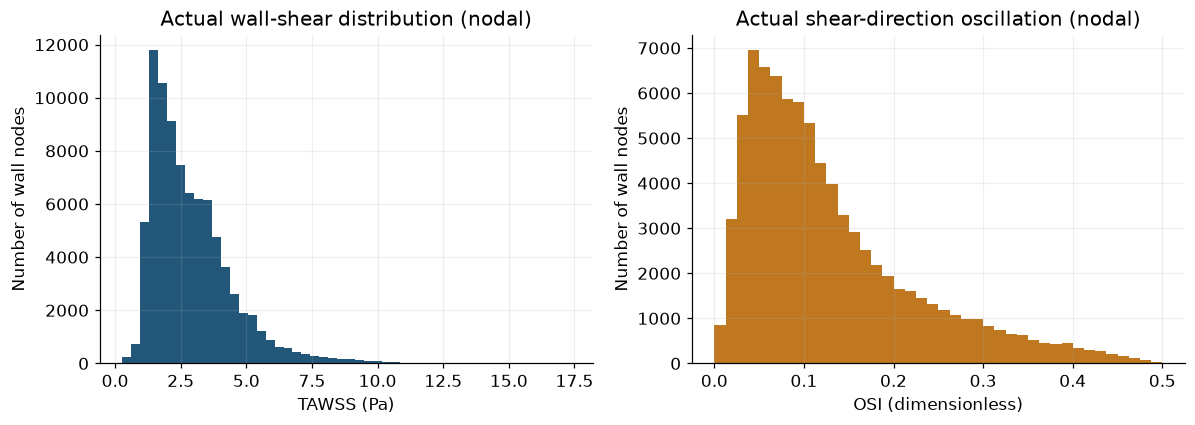

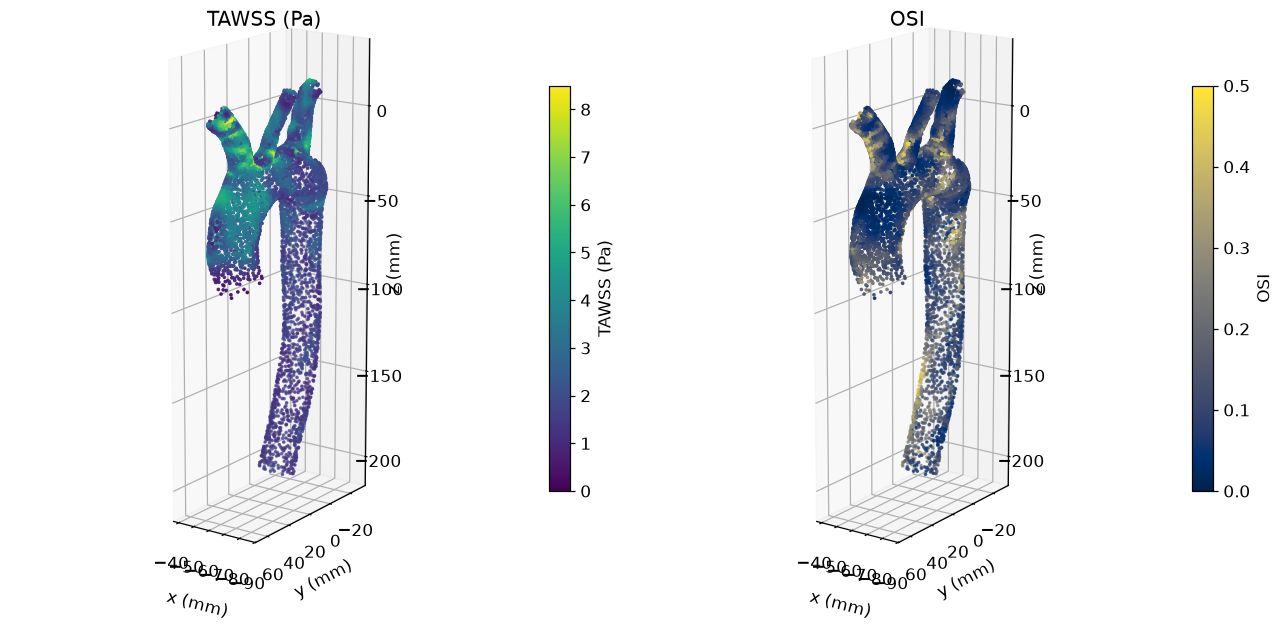

In [20]:
fig,axes=plt.subplots(1,2,figsize=(11,4))
axes[0].hist(TAWSS,bins=50,color=COLORS['main'])
axes[0].set(xlabel='TAWSS (Pa)',ylabel='Number of wall nodes',title='Actual wall-shear distribution (nodal)')
axes[1].hist(OSI[np.isfinite(OSI)],bins=40,range=(0,.5),color=COLORS['reference'])
axes[1].set(xlabel='OSI (dimensionless)',ylabel='Number of wall nodes',title='Actual shear-direction oscillation (nodal)')
save_figure('actual_wall_histograms')
# Static 3D maps retain actual geometry and sampled nodal colors.
fig=plt.figure(figsize=(12,6))
for k,(values,label,cmap) in enumerate([(TAWSS,'TAWSS (Pa)','viridis'),(OSI,'OSI','cividis')],1):
    ax=fig.add_subplot(1,2,k,projection='3d')
    ids=np.arange(0,result_wall.n_points,12)
    scatter=ax.scatter(*result_wall.points[ids].T*1000,c=values[ids],s=2,cmap=cmap,
                       vmin=0,vmax=np.quantile(values[np.isfinite(values)],.99) if k==1 else .5)
    ax.set(xlabel='x (mm)',ylabel='y (mm)',zlabel='z (mm)',title=label)
    ax.set_box_aspect(np.ptp(result_wall.points,axis=0));ax.view_init(elev=16,azim=125)
    fig.colorbar(scatter,ax=ax,shrink=.65,label=label)
save_figure('actual_wall_maps')

**Observed result.** The default area-weighted mean TAWSS is approximately **2.138 Pa**; the **nodal** median OSI is approximately **0.102**. These are different summaries with different spatial weighting. They describe the supplied simulation and should not be turned into a clinical classification. Numerical uncertainty in wall gradients remains relevant even if global flow conservation is excellent.

## 6. A4: measured surface shear versus model-profile magnitude

For a rigid incompressible unbranched reach, infer its flux from the inlet minus already-passed branch cap flows. This is a **continuity-based estimate**, not interior velocity integration. Projected branch roots come from supplied branch paths; their neighborhoods are masked. This allows reference Re/Dean numbers and an exploratory wall-friction magnitude comparison.

WSS on each contour uses nearest wall-node samples. Report maximum sampling distance; spacing sensitivity below does not replace near-wall mesh convergence. Measured projected magnitude is $f_{abs}=ρ^{-1}∮|τ_w·t|dl$. Compare to $|K_R U|$. Opposing shear patches add in this magnitude; this is not signed force and cannot feed the actual momentum residual. Surface WSS sign convention remains unknown.

**Why first estimate section flow from the caps?** Rigid-wall continuity lets us infer main-vessel $Q$ by subtracting the upstream branch outflows from inlet flow. This is a useful independent comparison for the directly integrated volume sections later. It supplies an estimated $U=Q/A$ for the surface-only reference comparison; it does not recover the actual interior velocity profile.

**What do Re, Wo and Dean tell us?** Here $Re=|U|D/\nu$ uses **diameter**, $Wo=R\sqrt{2\pi/(T\nu)}$ uses **radius**, and $De=Re\sqrt{R\kappa}$ adds the effect of curvature to a conventional curved-pipe indicator. Re compares convective inertia with viscosity; Wo compares pulsation with viscous diffusion. Dean is an exploratory extension for this geometry, not a universal threshold from the lectures. High values motivate inspecting the actual fields; they do not prove turbulence or 1D failure. See [dynamic circulation, PDF pp. 20–27](sources/course/dynamic_circulation.pdf#page=20).

**A units check worth understanding.** `profile_constants` returns $K_R/\nu$, not $K_R$. Multiplying by `NU` gives $K_R$ in m²/s before forming $f=K_RU$ in m³/s². The check below independently obtains the same Poiseuille force from wall shear $4\mu U/R$, multiplied by perimeter and divided by density. That catches a missing viscosity factor.

Max contour-to-wall-node sampling distance: 1.010 mm.
Re and Dean below use inferred unbranched Q; Wo depends only on period and geometry.


/var/folders/sh/fy24ndn17818f9l1l7dhz1t00000gn/T/ipykernel_13308/580074544.py:45: RuntimeWarning: All-NaN slice encountered
  axes[0].plot(s*1000,np.where(valid_geometry,np.nanmax(Re,axis=0),np.nan),color=COLORS['main'])
/var/folders/sh/fy24ndn17818f9l1l7dhz1t00000gn/T/ipykernel_13308/580074544.py:48: RuntimeWarning: All-NaN slice encountered
  axes[2].plot(s*1000,np.where(valid_geometry,np.nanmax(De,axis=0),np.nan),color=COLORS['alternate']);axes[2].set(ylabel='Peak Dean',xlabel='Arc length from inlet (mm)')


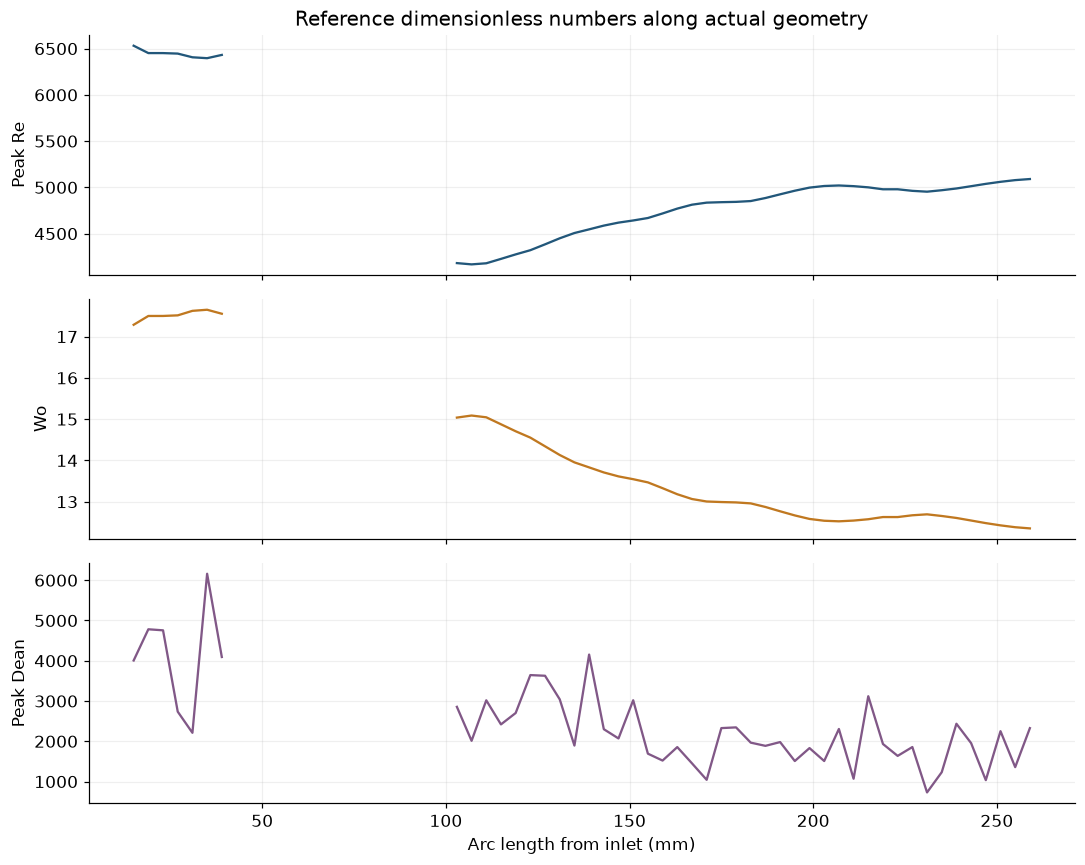

In [21]:
Q_inferred=np.tile(flows['inflow'][:,None],(1,len(s)))
for name,root_s in branch_locations.items():
    Q_inferred[:,s>root_s]-=flows[name][:,None]
U_inferred=Q_inferred/area[None,:]
Re=np.abs(U_inferred)*diameter[None,:]/NU
Wo=radius*np.sqrt(2*np.pi/PERIOD/NU)
De=Re*np.sqrt(radius[None,:]*curvature[None,:])  # Dean uses R/Rcurvature
shear_magnitude=np.full((len(steps),len(s)),np.nan)
friction_magnitude=np.full_like(shear_magnitude,np.nan)
probe_distance=np.full(len(s),np.nan)
wall_tree=cKDTree(result_wall.points)
for i,contour in enumerate(contours):
    if contour is None: continue
    pts,lengths,_=contour
    distance,ids=wall_tree.query(pts)
    probe_distance[i]=distance.max()
    for j,step in enumerate(steps):
        tau=np.asarray(surface_results[f'vWSS_{step}'])[wall_indices[ids]]*units.shear
        nodal_magnitude=np.linalg.norm(tau,axis=1)
        shear_magnitude[j,i]=np.sum(lengths*(nodal_magnitude+np.roll(nodal_magnitude,-1))/2)/lengths.sum()
        projected=np.abs(tau@tangents[i])
        friction_magnitude[j,i]=np.sum(lengths*(projected+np.roll(projected,-1))/2)/RHO
peak_local_flow=np.max(np.abs(Q_inferred),axis=0)
flow_mask=np.abs(Q_inferred)>LOW_FLOW_FRACTION*peak_local_flow[None,:]
usable=valid_geometry[None,:]&flow_mask
alpha_poiseuille,kr_poiseuille=profile_constants(2)
alpha_zeta9,kr_zeta9=profile_constants(9)
# profile_constants returns KR/nu; the physical KR has units m²/s.
kr_poiseuille *= NU
kr_zeta9 *= NU
# Independently recover force/density from Poiseuille wall shear and perimeter.
reference_shear = 4*MU*verification_U/verification_R
assert np.isclose(kr_poiseuille*verification_U,
                  reference_shear*(2*np.pi*verification_R)/RHO)
f_model_poiseuille=np.abs(kr_poiseuille*U_inferred)
f_model_zeta9=np.abs(kr_zeta9*U_inferred)
# Symmetric relative difference bounded to [0,2]; protects small denominators.
def relative_difference(observed,reference):
    """Symmetric magnitude deviation; NaN for excluded or nearly stagnant locations."""
    return np.where(usable,2*np.abs(observed-reference)/np.maximum(np.abs(observed)+np.abs(reference),1e-12),np.nan)
friction_deviation=relative_difference(friction_magnitude,f_model_poiseuille)
print(f'Max contour-to-wall-node sampling distance: {np.nanmax(probe_distance)*1000:.3f} mm.')
print('Re and Dean below use inferred unbranched Q; Wo depends only on period and geometry.')
fig,axes=plt.subplots(3,1,sharex=True,figsize=(10,8))
axes[0].plot(s*1000,np.where(valid_geometry,np.nanmax(Re,axis=0),np.nan),color=COLORS['main'])
axes[0].set(ylabel='Peak Re',title='Reference dimensionless numbers along actual geometry')
axes[1].plot(s*1000,np.where(valid_geometry,Wo,np.nan),color=COLORS['reference']);axes[1].set(ylabel='Wo')
axes[2].plot(s*1000,np.where(valid_geometry,np.nanmax(De,axis=0),np.nan),color=COLORS['alternate']);axes[2].set(ylabel='Peak Dean',xlabel='Arc length from inlet (mm)')
save_figure('reference_dimensionless_numbers')

**Why compare at one station as well as over the vessel?** A time trace near $s=200$ mm exposes amplitude and phase differences that a spatial average would hide. The first panel uses the magnitude of projected wall shear integrated around the contour, compared with Poiseuille, ζ=9 and Womersley force magnitudes. It intentionally discards sign. The second panel contains **reference α**, because wall data alone cannot determine the cross-sectional momentum flux. Directly measured α and signed force appear in Section 7.

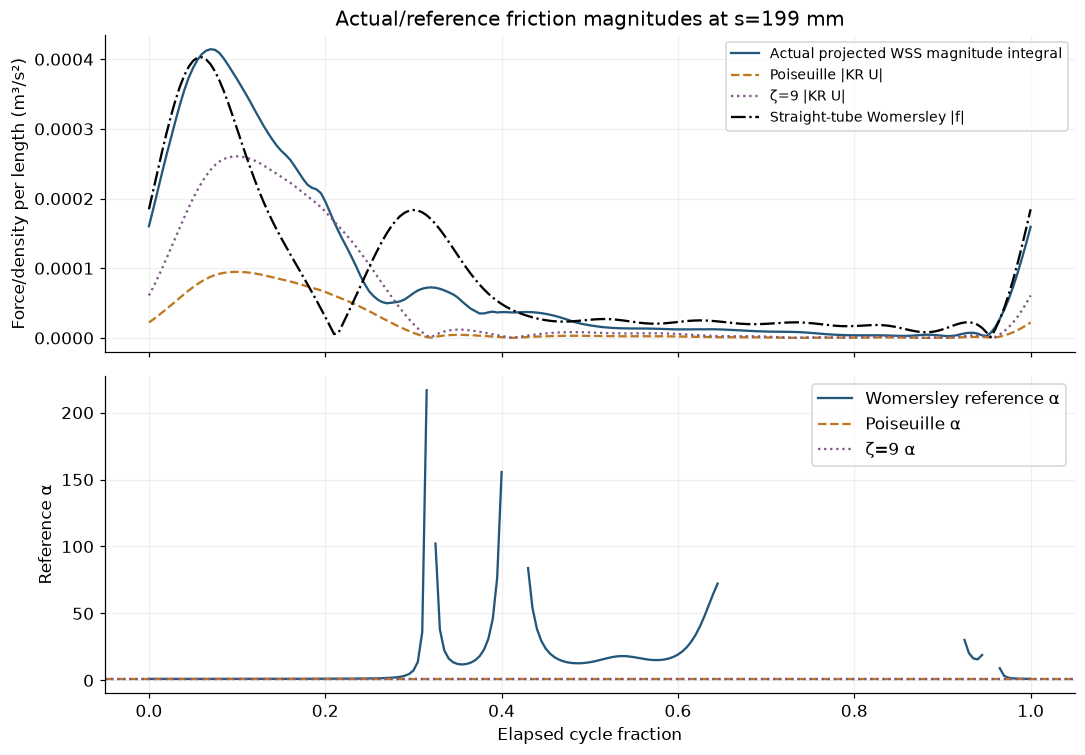

In [22]:
# Compare profiles at a usable descending-aorta station.
eligible=np.flatnonzero(valid_geometry)
if len(eligible)==0: raise ValueError('No usable stations; inspect centerline/contour masks.')
chosen_station=int(eligible[np.argmin(abs(s[eligible]-.20))])
reference_radius=radius[chosen_station]
wom_actual_input=womersley_reference(cycle_t,U_inferred[:,chosen_station],reference_radius,NU,PERIOD)
fig,axes=plt.subplots(2,1,sharex=True,figsize=(10,7))
axes[0].plot(cycle_t/PERIOD,friction_magnitude[:,chosen_station],color=COLORS['main'],label='Actual projected WSS magnitude integral')
axes[0].plot(cycle_t/PERIOD,f_model_poiseuille[:,chosen_station],color=COLORS['reference'],ls='--',label='Poiseuille |KR U|')
axes[0].plot(cycle_t/PERIOD,f_model_zeta9[:,chosen_station],color=COLORS['alternate'],ls=':',label='ζ=9 |KR U|')
axes[0].plot(cycle_t/PERIOD,np.abs(wom_actual_input['friction']),color='black',ls='-.',label='Straight-tube Womersley |f|')
axes[0].set(ylabel='Force/density per length (m³/s²)',title=f'Actual/reference friction magnitudes at s={s[chosen_station]*1000:.0f} mm');axes[0].legend(fontsize=9)
axes[1].plot(cycle_t/PERIOD,wom_actual_input['alpha'],color=COLORS['main'],label='Womersley reference α')
axes[1].axhline(4/3,color=COLORS['reference'],ls='--',label='Poiseuille α')
axes[1].axhline(1.1,color=COLORS['alternate'],ls=':',label='ζ=9 α')
axes[1].set(xlabel='Elapsed cycle fraction',ylabel='Reference α');axes[1].legend()
save_figure('actual_friction_reference_comparison')

**What to look for.** Compare the timing and size of the force peaks, not only the cycle mean. Womersley can respond differently from a quasi-steady profile because velocity and wall shear have radial phase differences. The ζ=9 profile has a blunter core but a steeper near-wall drop than Poiseuille at the same $U$ and radius. A smaller α therefore does not imply smaller wall friction: the former weights velocity squared throughout the section, while the latter depends on the wall derivative.

**Interpretation limits.** Reynolds compares inertia with viscosity; Wo compares pulsation with viscous diffusion; Dean also includes curvature. High values motivate examining unsteady/secondary motion; they do not prove turbulence or a failed 1D model by themselves. Womersley remains a fully developed circular straight-tube reference, with no branch loss or curvature effect. ζ=9 is a requested comparator, not a fitted truth. Wall/cap velocities alone cannot determine α; the actual filled-section analysis below supplies it.

Changing α and friction together can compensate errors; compare residual terms separately when volume data become available. Do not use the friction-only map below as a map of complete 1D validity.

**How the surface-friction map is normalised.** The plotted deviation is $2|f_{\mathrm{surface}}-f_{\mathrm{reference}}|/(|f_{\mathrm{surface}}|+|f_{\mathrm{reference}}|)$, bounded between 0 and 2 when the denominator is meaningful. A value of 0.1 is a symmetric relative difference of 10%; a value of 2 indicates one magnitude is zero while the other is positive. The colour scale stops at 1, so larger deviations share the brightest colour; the saved values can extend to 2. Blank regions are excluded by geometry or low net flow. This comparison asks whether the prescribed profile predicts the observed force magnitude; a signed momentum balance needs additional information.

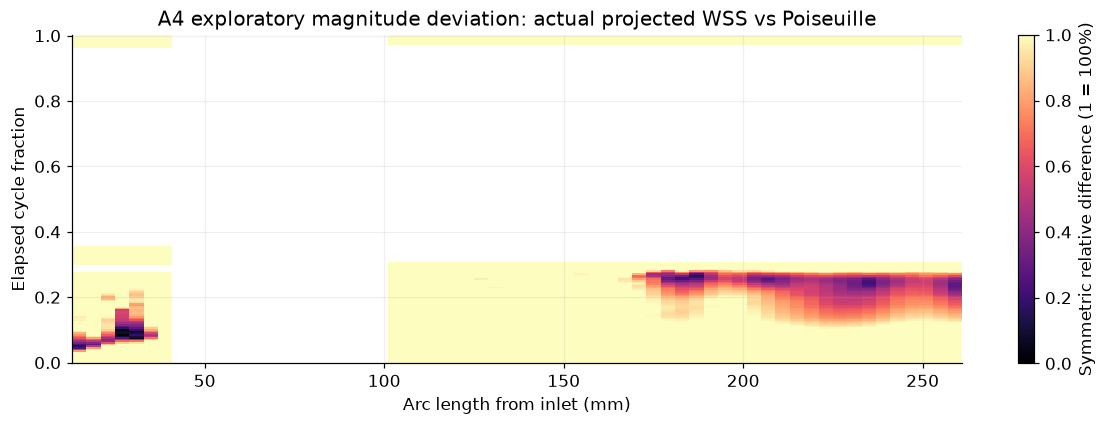

,threshold,eligible_station_phase_pairs,fraction_exceeding
0,0.05,3252,0.999385
1,0.10,3252,0.997847
2,0.20,3252,0.995387


/var/folders/sh/fy24ndn17818f9l1l7dhz1t00000gn/T/ipykernel_13308/1635698796.py:14: RuntimeWarning: All-NaN slice encountered
  reference_table=pd.DataFrame({'s_m':s,'Wo':Wo,'peak_inferred_Re':np.nanmax(Re,axis=0),
/var/folders/sh/fy24ndn17818f9l1l7dhz1t00000gn/T/ipykernel_13308/1635698796.py:15: RuntimeWarning: All-NaN slice encountered
  'peak_inferred_De':np.nanmax(De,axis=0),'max_wall_probe_distance_m':probe_distance,


In [23]:
fig,ax=plt.subplots(figsize=(11,4))
image=ax.pcolormesh(s*1000,cycle_t/PERIOD,friction_deviation,shading='auto',cmap='magma',vmin=0,vmax=1)
ax.set(xlabel='Arc length from inlet (mm)',ylabel='Elapsed cycle fraction',title='A4 exploratory magnitude deviation: actual projected WSS vs Poiseuille')
fig.colorbar(image,ax=ax,label='Symmetric relative difference (1 = 100%)')
save_figure('a4_friction_deviation_map')
threshold_rows=[]
for threshold in THRESHOLDS:
    good=np.isfinite(friction_deviation)
    threshold_rows.append({'threshold':threshold,'eligible_station_phase_pairs':int(good.sum()),
                           'fraction_exceeding':float((friction_deviation[good]>threshold).mean())})
threshold_table=pd.DataFrame(threshold_rows)
display(threshold_table)
threshold_table.to_csv(EXPORT/'a4_threshold_sensitivity.csv',index=False)
reference_table=pd.DataFrame({'s_m':s,'Wo':Wo,'peak_inferred_Re':np.nanmax(Re,axis=0),
                             'peak_inferred_De':np.nanmax(De,axis=0),'max_wall_probe_distance_m':probe_distance,
                             'eligible':valid_geometry})
reference_table.to_csv(EXPORT/'reference_dimensionless_numbers.csv',index=False)

## 7. Full volume-CFD pathway for A1–A6

Default section cache runs all Project 2 core calculations on real volume fields. The separate manifest reader below is also included for another export of this same completed rigid **volume** `.vtu` files under `data/volume/`, with nodal `velocity` and `pressure` fields, and a `volume_manifest.csv` beside notebook:

```csv
time_s,file
9.40748,data/volume/solution_10040.vtu
9.412165,data/volume/solution_10045.vtu
...
10.34448,data/volume/solution_11040.vtu
```

Supply real increasing times covering at least one cycle, preferably several to assess cycle convergence. Filenames are relative, cells must fill the lumen, source units must match `Units` (edit if SI). The initial/restart mesh is not a substitute. Cell-only fields are rejected rather than silently averaged. A compliant moving mesh requires registered station tracking and a moving-wall validation; current pathway explicitly supports **rigid** walls only.

Per frame: SI conversion → local connected plane cut → degree-two quadrature → volume-gradient wall stress → spatial derivatives separately within unbranched runs. Near-zero Q masks α and pressure normalization. Pressure range is normalized by local ½ρU² and by section-to-neighbour mean pressure difference. Small axial-drop denominators are masked; their normalization depends on slice spacing.

**Why keep a full-volume reader as well as the bundled route?** Surface files contain wall/cap values, whereas α, secondary velocity and transverse pressure variation require points throughout a section. `analyze_volume_manifest` exposes the same calculations for a conventional series of volume snapshots with explicit field names and SI scaling. It validates times and probes before making claims. The next cells use the packed repository VTU through an equivalent compact extraction; you do not need to prepare a new manifest for the default run. This is post-processing of a completed simulation, consistent with the CFD workflow in [computational haemodynamics, PDF pp. 7–10](sources/course/computational_haemodynamics.pdf#page=7).

In [24]:
def analyze_volume_manifest(manifest_path):
    """Analyse a completed rigid volume time series; return tables, term arrays.

    One volume is loaded at a time. Strict validation rejects stale meshes,
    surface-only exports, incomplete cycles, absent fields and invalid probes.
    Full gradient computation can require several GB on the 3.3M-cell mesh.
    """
    manifest=pd.read_csv(manifest_path)
    if not {'time_s','file'}.issubset(manifest.columns):
        raise ValueError('Manifest requires time_s,file columns.')
    times=manifest.time_s.to_numpy(float)
    if len(times)<8 or np.any(np.diff(times)<=0) or not np.all(np.isfinite(times)):
        raise ValueError('Need >=8 strictly increasing finite times.')
    start=times[-1]-PERIOD
    if times[0]>start+1e-8: raise ValueError('Manifest does not cover one complete cycle.')
    keep=np.flatnonzero(times>=start-1e-8)
    times=times[keep]
    if times[0]>start+1e-8 or np.max(np.diff(times))>1.5*np.median(np.diff(times)):
        raise ValueError('Need a full cycle with its start and no missing frames.')
    shape=(len(times),len(s))
    fields={key:np.full(shape,np.nan) for key in
            ['A','Q','U','P','alpha','secondary_ratio','pressure_range','f_measured']}
    for j,index in enumerate(keep):
        path=(BASE/str(manifest.iloc[index]['file'])).resolve()
        if not path.is_relative_to(BASE.resolve()):
            raise ValueError('Manifest files must remain inside shared project folder.')
        volume=pv.read(path)
        if not isinstance(volume,pv.UnstructuredGrid) or not np.any(np.isin(volume.celltypes,[10,12,13,14,24,25,26,27])):
            raise ValueError(f'{path.name} is not a filled 3D volume.')
        if not {'velocity','pressure'}.issubset(volume.point_data):
            raise ValueError('Require nodal velocity Nx3 and scalar pressure; configure export explicitly.')
        volume.points=np.asarray(volume.points,float)*units.length
        volume['velocity']=np.asarray(volume['velocity'],float)*units.velocity
        volume['pressure']=np.asarray(volume['pressure'],float)*units.pressure
        if np.ptp(volume['pressure'])==0 and np.max(np.abs(volume['velocity']))==0:
            raise ValueError('Zero initial state cannot be treated as completed CFD.')
        gradients=volume.compute_derivative(scalars='velocity',gradient='gradient',preference='point')
        for i in np.flatnonzero(valid_geometry):
            section=section_from_volume(volume,station_xyz[i],tangents[i])
            metrics=section_metrics(section,tangents[i],q_floor=1e-10)
            if abs(metrics['A']/area[i]-1)>.05:
                raise ValueError(f'Slice area differs >5% from wall at station {i}; inspect mapping.')
            for key,value in metrics.items():
                if key in fields: fields[key][j,i]=value
            fields['f_measured'][j,i]=signed_wall_force(gradients,contours[i],tangents[i],NU)
        print(f'Volume frame {j+1}/{len(times)} analysed.',end='\r')
    Q,A,P=fields['Q'],fields['A'],fields['P']
    low=np.abs(Q)<LOW_FLOW_FRACTION*np.nanmax(np.abs(Q),axis=0)[None,:]
    fields['alpha'][low]=np.nan
    dynamic=.5*RHO*(Q/A)**2
    fields['pressure_dynamic_ratio']=np.divide(fields['pressure_range'],dynamic,
        out=np.full(shape,np.nan),where=(~low)&(dynamic>1e-6))
    fields['pressure_axial_ratio']=np.full(shape,np.nan)
    termsets={name:{key:np.full(shape,np.nan) for key in
                   ['inertial','convective','pressure','friction','residual','normalized','mass']}
              for name in ['poiseuille','zeta9','measured']}
    # Separate contiguous unbranched reaches: derivatives never bridge branch gaps.
    usable_ids=np.flatnonzero(valid_geometry)
    runs=np.split(usable_ids,np.where(np.diff(usable_ids)>1)[0]+1)
    for run in runs:
        if len(run)<3: continue
        local_drop=np.abs(np.gradient(P[:,run],s[run],axis=1))*np.mean(np.diff(s[run]))
        fields['pressure_axial_ratio'][:,run]=np.divide(fields['pressure_range'][:,run],local_drop,
            out=np.full((len(times),len(run)),np.nan),where=(~low[:,run])&(local_drop>.01))
        for name,alpha_value,friction_value in [
            ('poiseuille',4/3,kr_poiseuille*Q/A),
            ('zeta9',1.1,kr_zeta9*Q/A),
            ('measured',fields['alpha'],fields['f_measured'])]:
            alpha_local=alpha_value if np.isscalar(alpha_value) else alpha_value[:,run]
            out=balance_terms(times,s[run],A[:,run],Q[:,run],P[:,run],alpha_local,friction_value[:,run],RHO)
            for key,values in out.items(): termsets[name][key][:,run]=values
    data=[{'time_s':times[j]-start,'s_m':s[i],**{key:value[j,i] for key,value in fields.items()}}
          for j in range(len(times)) for i in range(len(s))]
    table=pd.DataFrame(data)
    table.to_csv(EXPORT/'actual_volume_section_metrics.csv',index=False)
    for name,terms in termsets.items():
        pd.DataFrame([{'time_s':times[j]-start,'s_m':s[i],**{key:value[j,i] for key,value in terms.items()}}
                      for j in range(len(times)) for i in range(len(s))]).to_csv(EXPORT/f'actual_volume_momentum_{name}.csv',index=False)
    return times-start,fields,termsets,table

volume_output=None
if (BASE/'volume_manifest.csv').exists():
    volume_output=analyze_volume_manifest(BASE/'volume_manifest.csv')

### Actual packed-volume data: compact, traceable, rerunnable

Raw matching [volume archive](https://www.vascularmodel.com/svresults/0012_H_AO_H/0012_H_AO_H_3D_RIGID_VTU.zip) contains 608,192 points and 3,268,267 tetrahedra, with `pressure_STEP`, `velocity_STEP` and `average_pressure_STEP`. We use actual pressure, not the averaged array. Geometry stencils interpolate inside original tetrahedra. Double-precision slicing, candidate-cell barycentric checks and a nanometre-scale inward adjustment handle wall-edge roundoff. Direct raw-VTU slice comparisons are recorded in `results/validation_source_sections.csv`. Section fields remain editable/recomputable in notebook; they are not precomputed conclusions. Float32 compact storage introduces small roundoff, checked against source on sampled probes.

Wall friction is reconstructed from two inward probes at δ=0.30 mm and 2δ with no-slip wall velocity zero. The inward derivative estimate `(4u(δ)-u(2δ))/(2δ)` gives signed resisting $f=ν∮∂_{in}u_s\,dl$. A second reconstruction at half δ checks sensitivity. This approximation depends on near-wall mesh resolution and local normal geometry; a high residual can reflect this uncertainty. Supplied surface WSS magnitude remains an independent comparison.

Default Run All uses `data/actual_volume_sections.npz`. To change spacing, centerline or branch exclusions: download/extract raw archive, set `RAW_PACKED_VOLUME` to its local path and `REEXTRACT_VOLUME=True`. This can take several minutes and several GB RAM/disk. Old cache parameters are checked; incompatible cached slices are rejected. Closure statistics compare the same finite station/phase pairs. Fluid constants belong to the source simulation; changing them does not produce a new CFD solution.

**What the large extraction cell does, in four steps.**

1. **Locate sample points.** A plane cuts the actual tetrahedral volume. Each resulting point is associated with a containing tetrahedron; points outside the domain are rejected.
2. **Interpolate fields.** Barycentric weights express the sample position as a weighted combination of the tetrahedron's vertices. The same weights interpolate pressure and each velocity component. A sparse matrix stores the few contributing vertices per sample.
3. **Reuse rigid geometry.** Because the mesh does not move, the locations and weights can be reused for all 201 frames. Reading fields one frame at a time avoids loading the entire multi-gigabyte time series at once.
4. **Retain enough data to recalculate.** The compact archive stores section geometry and interpolated fields, plus signed near-wall force estimates and provenance. It does not interpolate from a wall-only file or fabricate missing interior values.

For the packed-volume wall force, no-slip gives $u_s(0)=0$. Samples at inward distances $\delta$ and $2\delta$ estimate the wall derivative as $[4u_s(\delta)-u_s(2\delta)]/(2\delta)$. Multiplication by $\nu$ and integration around the perimeter gives signed $f$. Repeating at half depth measures sensitivity to this reconstruction. It remains an approximation to wall traction, especially in irregular or strongly three-dimensional flow. The need to resolve a derivative near the wall is taught in [computational haemodynamics, PDF p. 17](sources/course/computational_haemodynamics.pdf#page=17); the sampling scheme is our implementation choice.

In [25]:
import vtk
from scipy.sparse import csr_matrix


def tetra_probe_matrix(volume, points, locator=None, interior_target=None):
    """Linear-tetra interpolation matrix, with positive in-domain barycentric weights.

    Cache geometry once for rigid meshes. Do not use nearest-node interpolation
    for pressure/velocity. Every probe must belong to a tetrahedron.
    """
    if not np.all(volume.celltypes == int(pv.CellType.TETRA)):
        raise ValueError('Packed extractor currently requires a linear-tetra mesh.')
    if locator is None:
        locator=vtk.vtkStaticCellLocator();locator.SetDataSet(volume);locator.BuildLocator()
    sample_points=np.asarray(points,float)
    if interior_target is not None:
        # Submicrometre inward shift handles roundoff at cut-wall endpoints.
        sample_points=sample_points+1e-7*(np.asarray(interior_target)-sample_points)
    generic=vtk.vtkGenericCell();pcoords=[0.,0.,0.];vtkweights=[0.]*4
    cellids=np.array([locator.FindCell(point,1e-18,generic,pcoords,vtkweights) for point in sample_points])
    if np.any(cellids<0):
        raise ValueError(f'{np.count_nonzero(cellids<0)} interpolation probes outside lumen.')
    tetra=np.asarray(volume.cell_connectivity).reshape(-1,4)[cellids]
    vertices=volume.points[tetra]
    matrix=(vertices[:,1:]-vertices[:,0,None,:]).transpose(0,2,1)
    weights3=np.linalg.solve(matrix,(sample_points-vertices[:,0])[...,None])[...,0]
    weights=np.c_[1-weights3.sum(axis=1),weights3]
    bad=np.flatnonzero((weights.min(axis=1)<-1e-7)|(weights.max(axis=1)>1+1e-7))
    connectivity=np.asarray(volume.cell_connectivity).reshape(-1,4)
    for row in bad:
        # VTK accepts parametric tolerance and may return a neighboring sliver.
        # Inspect candidate bounding boxes, then select by actual barycentric fit.
        point=sample_points[row];candidates=vtk.vtkIdList();pad=1e-8
        bounds=np.column_stack([point-pad,point+pad]).ravel().tolist()
        locator.FindCellsWithinBounds(bounds,candidates)
        cell_candidates=np.array([candidates.GetId(k) for k in range(candidates.GetNumberOfIds())],int)
        vertex_ids=connectivity[cell_candidates];vv=volume.points[vertex_ids]
        matrices=(vv[:,1:]-vv[:,0,None,:]).transpose(0,2,1)
        ww3=np.linalg.solve(matrices,(point-vv[:,0])[...,None])[...,0]
        ww=np.c_[1-ww3.sum(axis=1),ww3]
        score=np.maximum(-ww.min(axis=1),ww.max(axis=1)-1)
        best=int(np.argmin(score))
        tetra[row]=vertex_ids[best];weights[row]=ww[best]
    if np.min(weights)<-1e-5 or np.max(weights)>1+1e-5:
        raise ValueError(f'Invalid barycentric weights after candidate search: {weights.min():.3g}, {weights.max():.3g}.')
    weights=np.clip(weights,0,1);weights/=weights.sum(axis=1)[:,None]
    rows=np.repeat(np.arange(len(points)),4)
    return csr_matrix((weights.ravel(),(rows,tetra.ravel())),shape=(len(points),volume.n_points))


def contour_inward_probes(contour, tangent, depth):
    """Wall midpoints displaced inward at depth and 2*depth, with length weights."""
    pts,lengths,_=contour
    edge=np.roll(pts,-1,axis=0)-pts
    midpoint=(pts+np.roll(pts,-1,axis=0))/2
    normal=np.cross(edge,tangent);normal/=np.linalg.norm(normal,axis=1)[:,None]
    if np.mean(np.sum(normal*(midpoint-midpoint.mean(axis=0)),axis=1))<0:normal=-normal
    return np.r_[midpoint-depth*normal,midpoint-2*depth*normal], lengths


def extract_packed_volume(path, s, origins, tangents, valid, contours, times, steps,
                          units, output, signature, depth=.0003):
    """Reduce packed VMR volume into actual filled sections and wall probes.

    Read only pressure/velocity for each step. Precompute slice and probe
    stencils for rigid geometry. Results stay tied to source hash and geometry.
    No 3D field is fabricated from the surface result. Archive average_pressure
    arrays are not used: actual pressure_STEP fields are selected explicitly.
    """
    reader=pv.get_reader(path);reader.disable_all_point_arrays();reader.disable_all_cell_arrays()
    geometry=reader.read();geometry.points=np.asarray(geometry.points,float)*units.length
    if geometry.n_points!=608192 or geometry.n_cells!=3268267:
        raise ValueError('Unexpected model volume topology; verify dataset identity.')
    locator=vtk.vtkStaticCellLocator();locator.SetDataSet(geometry);locator.BuildLocator()
    cache={}; stencils=[]; probe_stencils=[]; section_ids=[]; counts=[]; probe_counts=[]
    for i in np.flatnonzero(valid):
        section=section_from_volume(geometry,origins[i],tangents[i])
        if abs(section.area/contours[i][2]-1)>.03:
            raise ValueError(f'Section {i} area differs >3% from wall contour.')
        section_ids.append(i);counts.append(section.n_points)
        cache[f'points_{i}']=np.asarray(section.points)
        cache[f'faces_{i}']=np.asarray(section.faces)
        stencils.append(tetra_probe_matrix(geometry,section.points,locator,origins[i]))
        probe, lengths=contour_inward_probes(contours[i],tangents[i],depth)
        probe_half,_=contour_inward_probes(contours[i],tangents[i],depth/2)
        probe_stencils.append((tetra_probe_matrix(geometry,probe,locator),
                               tetra_probe_matrix(geometry,probe_half,locator)))
        cache[f'wall_lengths_{i}']=lengths
        probe_counts.append(len(lengths))
        print(f'Volume geometry stencil {len(section_ids)}/{np.count_nonzero(valid)}',flush=True)
    section_ids=np.array(section_ids,int)
    offsets=np.r_[0,np.cumsum(counts)]
    # Assemble sparse matrices once; each frame requires only matrix products.
    from scipy.sparse import vstack
    section_matrix=vstack(stencils,format='csr')
    probe_matrix=vstack([x[0] for x in probe_stencils],format='csr')
    probe_half_matrix=vstack([x[1] for x in probe_stencils],format='csr')
    velocity=np.empty((len(steps),offsets[-1],3),dtype=np.float32)
    pressure=np.empty((len(steps),offsets[-1]),dtype=np.float32)
    f=np.full((len(steps),len(s)),np.nan)
    f_half=np.full_like(f,np.nan)
    probe_offsets=np.r_[0,np.cumsum(np.array(probe_counts)*2)]
    for j,step in enumerate(steps):
        reader.disable_all_point_arrays()
        reader.enable_point_array(f'velocity_{step}')
        reader.enable_point_array(f'pressure_{step}')
        data=reader.read()
        vel=np.asarray(data[f'velocity_{step}'])*units.velocity
        pre=np.asarray(data[f'pressure_{step}'])*units.pressure
        if vel.shape!=(geometry.n_points,3) or pre.shape!=(geometry.n_points,):
            raise ValueError('Packed volume field shape mismatch.')
        if not np.all(np.isfinite(vel)) or not np.all(np.isfinite(pre)):
            raise ValueError('Nonfinite packed volume fields.')
        velocity[j]=section_matrix@vel
        pressure[j]=section_matrix@pre
        probe_velocity=probe_matrix@vel;probe_half_velocity=probe_half_matrix@vel
        for k,i in enumerate(section_ids):
            n=probe_counts[k];sl=slice(probe_offsets[k],probe_offsets[k+1])
            lengths=cache[f'wall_lengths_{i}']
            v=probe_velocity[sl];vh=probe_half_velocity[sl]
            # Second-order inward derivative with no-slip u_wall=0.
            derivative=(4*v[:n]-v[n:])/(2*depth)
            derivative_half=(4*vh[:n]-vh[n:])/depth
            f[j,i]=NU*np.sum(lengths*(derivative@tangents[i]))
            f_half[j,i]=NU*np.sum(lengths*(derivative_half@tangents[i]))
        if j%10==0 or j==len(steps)-1:print(f'Volume fields {j+1}/{len(steps)}',flush=True)
    cache.update({'section_ids':section_ids,'offsets':offsets,'velocity_m_s':velocity,
                  'pressure_Pa':pressure,'f_wall_probe_m3_s2':f,'f_wall_probe_half_m3_s2':f_half,
                  'time_s':np.asarray(times),'steps':np.asarray(steps),'s_m':np.asarray(s),
                  'wall_probe_depth_m':np.array(depth),'signature_json':np.array(json.dumps(signature,sort_keys=True))})
    np.savez_compressed(output,**cache)
    return cache


def metrics_from_packed(cache, s, tangents, rho, export, low_fraction=.05):
    """Recompute all cross-sectional metrics and closure residuals from real slices.

    Wall force is a two-depth, no-slip normal-derivative estimate, not supplied
    WSS magnitude. Derivative runs cannot cross branch/exclusion gaps. Pressure
    normalizations and alpha are masked near net zero flow.
    """
    times=np.asarray(cache['time_s']);ids=np.asarray(cache['section_ids'],int)
    if not np.allclose(np.asarray(cache['s_m']),s):raise ValueError('Slice-cache station mismatch.')
    shape=(len(times),len(s))
    fields={key:np.full(shape,np.nan) for key in
            ['A','Q','U','P','alpha','secondary_ratio','pressure_range']}
    for k,i in enumerate(ids):
        mesh=pv.PolyData(cache[f'points_{i}'],cache[f'faces_{i}'])
        sl=slice(cache['offsets'][k],cache['offsets'][k+1])
        for j in range(len(times)):
            mesh['velocity']=np.asarray(cache['velocity_m_s'][j,sl],dtype=float)
            mesh['pressure']=np.asarray(cache['pressure_Pa'][j,sl],dtype=float)
            metrics=section_metrics(mesh,tangents[i],q_floor=1e-10)
            for key in fields:fields[key][j,i]=metrics[key]
    fields['f_measured']=np.asarray(cache['f_wall_probe_m3_s2'])
    fields['f_half_depth']=np.asarray(cache['f_wall_probe_half_m3_s2'])
    Q,A,P=fields['Q'],fields['A'],fields['P']
    with warnings.catch_warnings():
        warnings.simplefilter('ignore',RuntimeWarning)
        peak=np.nanmax(np.abs(Q),axis=0)
    low=np.abs(Q)<low_fraction*peak[None,:]
    fields['alpha'][low]=np.nan
    dynamic=.5*rho*(Q/A)**2
    fields['pressure_dynamic_ratio']=np.divide(fields['pressure_range'],dynamic,
                 out=np.full(shape,np.nan),where=(~low)&(dynamic>1e-6))
    fields['pressure_axial_ratio']=np.full(shape,np.nan)
    termsets={name:{key:np.full(shape,np.nan) for key in
              ['inertial','convective','pressure','friction','residual','normalized','mass']}
              for name in ['poiseuille','zeta9','measured','measured_half_depth','measured_alpha_model_f','model_alpha_measured_f']}
    for run in np.split(ids,np.where(np.diff(ids)>1)[0]+1):
        if len(run)<3:continue
        local_drop=np.abs(np.gradient(P[:,run],s[run],axis=1))*np.mean(np.diff(s[run]))
        fields['pressure_axial_ratio'][:,run]=np.divide(fields['pressure_range'][:,run],local_drop,
            out=np.full((len(times),len(run)),np.nan),where=(~low[:,run])&(local_drop>.01))
        for name,alpha,friction in [
            ('poiseuille',4/3,8*np.pi*NU*Q/A),('zeta9',1.1,22*np.pi*NU*Q/A),
            ('measured',fields['alpha'],fields['f_measured']),
            ('measured_half_depth',fields['alpha'],fields['f_half_depth']),
            ('measured_alpha_model_f',fields['alpha'],8*np.pi*NU*Q/A),
            ('model_alpha_measured_f',4/3,fields['f_measured'])]:
            a=alpha if np.isscalar(alpha) else alpha[:,run]
            terms=balance_terms(times,s[run],A[:,run],Q[:,run],P[:,run],a,friction[:,run],rho)
            for key,value in terms.items():termsets[name][key][:,run]=value
    table=pd.DataFrame([{'time_s':times[j],'s_m':s[i],**{key:value[j,i] for key,value in fields.items()}}
          for j in range(len(times)) for i in range(len(s))])
    table.to_csv(export/'actual_volume_section_metrics.csv',index=False)
    for name,terms in termsets.items():
        pd.DataFrame([{'time_s':times[j],'s_m':s[i],**{key:value[j,i] for key,value in terms.items()}}
                      for j in range(len(times)) for i in range(len(s))]).to_csv(export/f'actual_volume_momentum_{name}.csv',index=False)
    return times,fields,termsets,table

**Why refuse a stale cache?** The cached sections correspond to specific geometry, station spacing, exclusion masks, units and viscosity. Reusing them after changing those inputs could give internally consistent numbers for the wrong analysis. Hashes and parameter signatures therefore have to agree. The cache is loaded once, then `metrics_from_packed` integrates its actual fields and calculates balances separately on contiguous unbranched station runs.

**How to compare closure statistics fairly.** The table uses the same finite station–time pairs for every closure. Otherwise the measured-α case could look better merely because it excludes difficult low-flow phases while a constant-α model retains them. The “half depth” row changes the wall derivative estimate; the two mixed rows change only α or friction. These are sensitivity comparisons, not isolated causal experiments.

In [26]:
volume_cache_path=BASE/'data'/'actual_volume_sections.npz'
volume_source_meta=json.loads((BASE/'data'/'actual_volume_sections.json').read_text())
expected_geometry={'model_sha256':sha256_file(DATA/'Models'/'0095_0001.vtp'),
                   'centerline_sha256':sha256_file(cache_path),'spacing_m':SPACING,'trim_m':TRIM,
                   'branch_exclusion_m':BRANCH_EXCLUSION,'source_dt_s':DT,'period_s':PERIOD,
                   'kinematic_viscosity_m2_s':NU,'units':units.__dict__}
if REEXTRACT_VOLUME:
    if RAW_PACKED_VOLUME is None or not Path(RAW_PACKED_VOLUME).exists():
        raise FileNotFoundError('Set RAW_PACKED_VOLUME to extracted matching 5.55 GB VTU.')
    volume_source_meta.update(expected_geometry)
    volume_source_meta['volume_sha256']=sha256_file(RAW_PACKED_VOLUME)
    extract_packed_volume(RAW_PACKED_VOLUME,s,station_xyz,tangents,valid_geometry,contours,
                          cycle_t,steps,units,volume_cache_path,volume_source_meta)
    (BASE/'data'/'actual_volume_sections.json').write_text(json.dumps(volume_source_meta,indent=2))
for key,value in expected_geometry.items():
    if volume_source_meta.get(key)!=value:
        raise ValueError(f'Cached volume {key} differs. Re-extract from raw volume with changed settings.')
with np.load(volume_cache_path,allow_pickle=False) as stored:
    # Materialize each compressed array once; avoid decompression per slice/frame.
    actual_volume_cache={key:stored[key] for key in stored.files}
if json.loads(str(actual_volume_cache['signature_json']))!=volume_source_meta:
    raise ValueError('Compact volume metadata signature mismatch.')
if not np.array_equal(actual_volume_cache['section_ids'],np.flatnonzero(valid_geometry)):
    raise ValueError('Volume cache station eligibility differs; re-extract.')
volume_output=metrics_from_packed(actual_volume_cache,s,tangents,RHO,EXPORT,LOW_FLOW_FRACTION)
volume_t,volume_fields,volume_terms,volume_table=volume_output
assert np.nanmin(volume_fields['alpha']) >= 1-1e-6
assert np.all(volume_fields['pressure_range'][np.isfinite(volume_fields['pressure_range'])]>=0)
print('Actual completed volume: all',len(volume_t),'snapshots analysed at',len(actual_volume_cache['section_ids']),'filled sections.')
volume_q_error=(volume_fields['Q']-Q_inferred)/flow_scale
print(f'Local section Q vs branch-corrected cap continuity: peak-scaled max {100*np.nanmax(abs(volume_q_error)):.3f}%.')
wall_depth_difference=np.abs(volume_fields['f_measured']-volume_fields['f_half_depth'])
wall_depth_scale=np.nanmax(np.abs(volume_fields['f_measured']))
print(f'Wall-probe δ vs δ/2 maximum difference / global peak signed friction: {100*np.nanmax(wall_depth_difference)/wall_depth_scale:.2f}%.')
shared_residual_mask=np.isfinite(volume_terms['measured']['normalized'])
closure_statistics=pd.DataFrame([{'closure':name,'common_valid_pairs':int(shared_residual_mask.sum()),
    'median_normalized_residual':np.nanmedian(np.where(shared_residual_mask,terms['normalized'],np.nan)),
    '95th_percentile_normalized_residual':np.nanquantile(np.where(shared_residual_mask,terms['normalized'],np.nan),.95)}
    for name,terms in volume_terms.items()])
display(closure_statistics)
closure_statistics.to_csv(EXPORT/'closure_residual_statistics.csv',index=False)

Actual completed volume: all 201 snapshots analysed at 47 filled sections.
Local section Q vs branch-corrected cap continuity: peak-scaled max 0.350%.
Wall-probe δ vs δ/2 maximum difference / global peak signed friction: 32.97%.


,closure,common_valid_pairs,median_normalized_residual,95th_percentile_normalized_residual
0,poiseuille,2878,0.045589,0.495775
1,zeta9,2878,0.043617,0.454308
2,measured,2878,0.011652,0.175115
3,measured_half_depth,2878,0.011556,0.180441
4,measured_alpha_model_f,2878,0.047204,0.251163
5,model_alpha_measured_f,2878,0.046765,0.418833


**Observed result on matched samples.** The default Poiseuille residual has a median of about **0.046**, compared with **0.012** when measured α and reconstructed signed friction are used, on **2,878 common station–time pairs**. These correspond to about 4.6% and 1.2% of the sum of term magnitudes, not percentage errors in predicted pressure. The measured closure's 95th percentile is about **0.175**, showing why the median alone is insufficient. Direct section flow and cap-based continuity differ by at most about **0.350% of peak inlet flow**.

These results support the importance of closure choices in the reduced balance. They do not identify one unique source of error: pressure reduction, non-axial flow, derivatives, geometry and wall reconstruction are still coupled.

**How to read the actual section maps and profile scatter.** The two map coordinates span a plane perpendicular to the centreline; they are not the global x/y axes. The pressure panel subtracts the area-mean pressure, so red/blue show higher/lower pressure within the same section. Symmetric colour limits make deviations on both sides of zero comparable. The velocity panel shows **signed axial velocity**, not total speed. A value below zero means local reverse flow.

The scatter plot retains all angular positions at each distance from the centreline. Vertical spread at a similar radius can reveal skewed/asymmetric flow that a single radial curve would hide; it is not an uncertainty interval. A normalised radius above 1 can occur because the equivalent-area circle does not coincide with the actual noncircular boundary or chosen centreline. “Quarter” and “half” refer to the saved interval, not identified physiological phases.

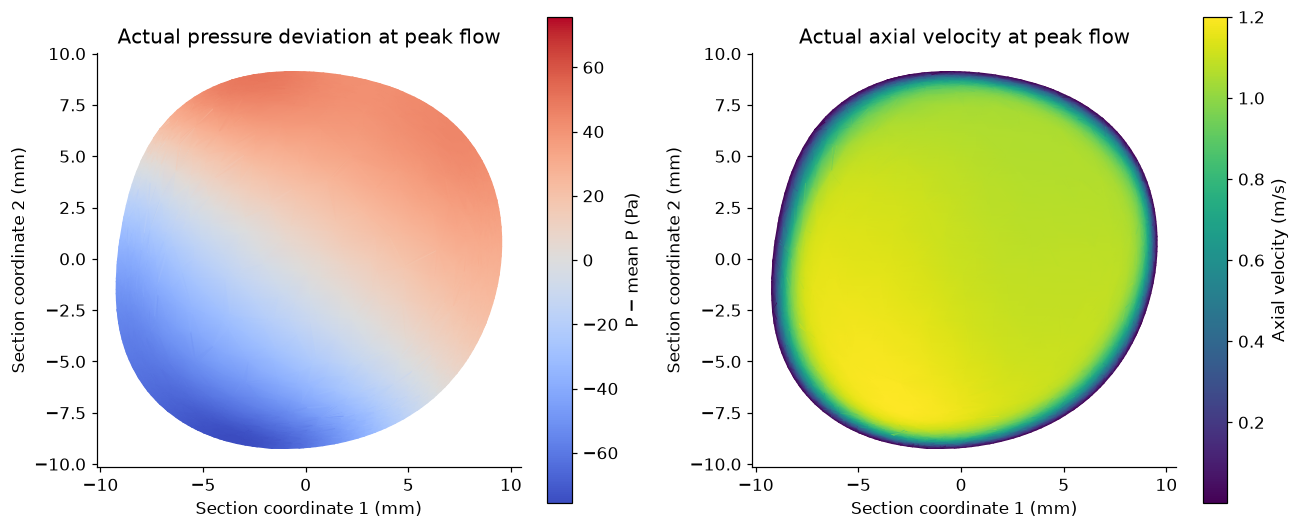

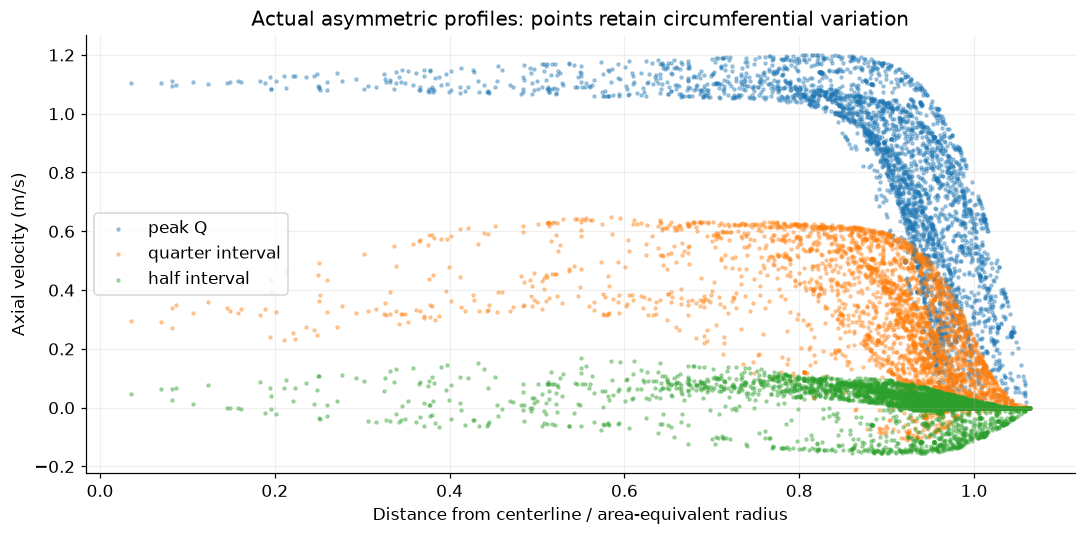

In [27]:
# Actual within-section pressure map and velocity profiles at selected station.
k=int(np.flatnonzero(actual_volume_cache['section_ids']==chosen_station)[0])
sl=slice(actual_volume_cache['offsets'][k],actual_volume_cache['offsets'][k+1])
points=np.asarray(actual_volume_cache[f'points_{chosen_station}'])
faces=np.asarray(actual_volume_cache[f'faces_{chosen_station}']).reshape(-1,4)[:,1:]
normal=tangents[chosen_station]
e1=np.cross(normal,np.array([1.,0,0]) if abs(normal[0])<.9 else np.array([0.,1,0]));e1/=np.linalg.norm(e1)
e2=np.cross(normal,e1)
coordinates=points-station_xyz[chosen_station]
u,v=coordinates@e1,coordinates@e2
jpeak=int(np.nanargmax(volume_fields['Q'][:,chosen_station]))
pvalues=np.asarray(actual_volume_cache['pressure_Pa'][jpeak,sl],float)
vel=np.asarray(actual_volume_cache['velocity_m_s'][jpeak,sl],float)
fig,axes=plt.subplots(1,2,figsize=(12,5))
p_deviation=pvalues-volume_fields['P'][jpeak,chosen_station]
p_bound=np.max(np.abs(p_deviation))
im=axes[0].tripcolor(u*1000,v*1000,faces,p_deviation,shading='gouraud',cmap='coolwarm',vmin=-p_bound,vmax=p_bound)
axes[0].set(xlabel='Section coordinate 1 (mm)',ylabel='Section coordinate 2 (mm)',title='Actual pressure deviation at peak flow');axes[0].set_aspect('equal');fig.colorbar(im,ax=axes[0],label='P − mean P (Pa)')
im=axes[1].tripcolor(u*1000,v*1000,faces,vel@normal,shading='gouraud',cmap='viridis')
axes[1].set(xlabel='Section coordinate 1 (mm)',ylabel='Section coordinate 2 (mm)',title='Actual axial velocity at peak flow');axes[1].set_aspect('equal');fig.colorbar(im,ax=axes[1],label='Axial velocity (m/s)')
save_figure('actual_volume_section_maps')
fig,ax=plt.subplots(figsize=(10,5))
radial=np.sqrt(u*u+v*v)/radius[chosen_station]
for j,label in [(jpeak,'peak Q'),(int(len(volume_t)/4),'quarter interval'),(int(len(volume_t)/2),'half interval')]:
    speed=np.asarray(actual_volume_cache['velocity_m_s'][j,sl])@normal
    ax.scatter(radial,speed,s=4,alpha=.35,label=label)
ax.set(xlabel='Distance from centerline / area-equivalent radius',ylabel='Axial velocity (m/s)',title='Actual asymmetric profiles: points retain circumferential variation')
ax.legend();save_figure('actual_volume_velocity_profiles')

**Interpretation checkpoint.** In the displayed peak-flow section, pressure is spatially structured around its mean and the velocity field is not a perfect concentric parabola. Use the colourbar units to judge the absolute pressure variation before reading its dynamic-pressure normalisation. In the scatter plot, keep the angular spread: collapsing it to one radial average would erase some of the 3D behaviour that Project 2 asks us to assess.

**Reading the local mass and closure comparisons.** The upper map compares two routes to $Q$: direct interior-section integration and branch-corrected cap continuity. Its denominator is peak inlet flow, which remains stable when instantaneous flow approaches zero. This is a stronger local slicing check than global inlet/outlet balance alone. The lower traces compare signed momentum closures at the selected station. Similar full-depth and half-depth traces support robustness to that probe choice; agreement does not establish mesh independence or accuracy against measurements.

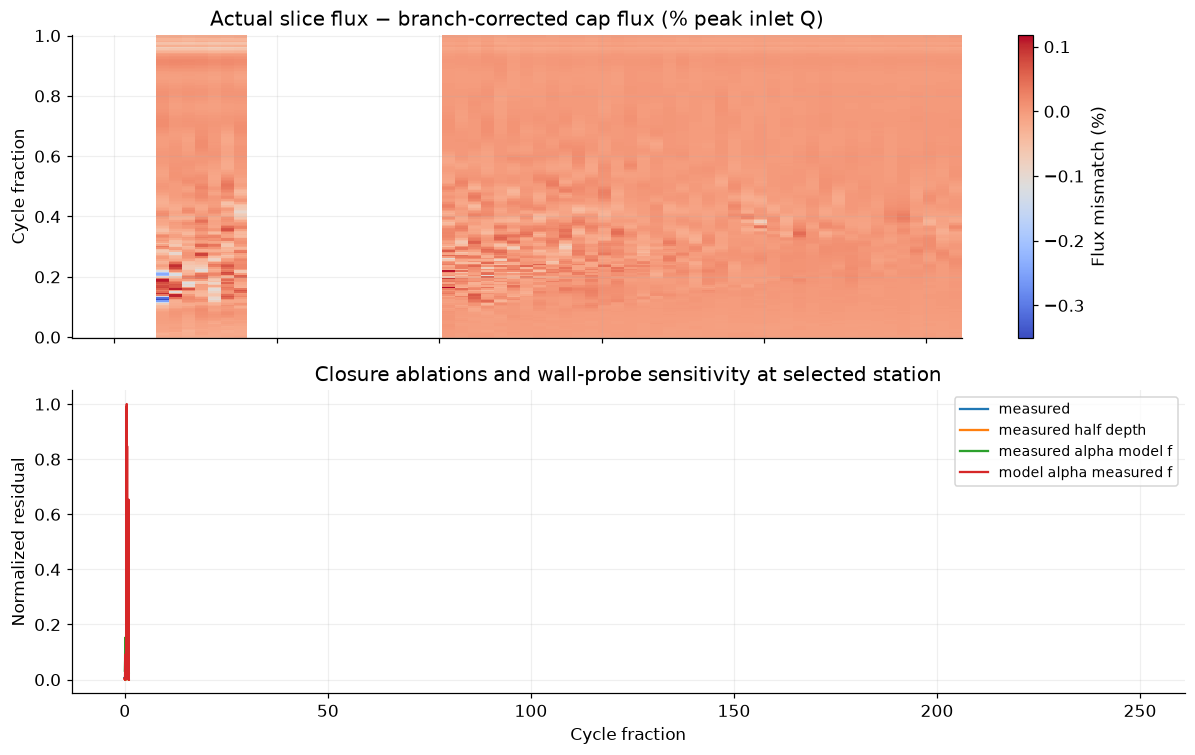

In [28]:
fig,axes=plt.subplots(2,1,sharex=True,figsize=(11,7))
image=axes[0].pcolormesh(s*1000,volume_t/PERIOD,volume_q_error*100,shading='auto',cmap='coolwarm')
axes[0].set(ylabel='Cycle fraction',title='Actual slice flux − branch-corrected cap flux (% peak inlet Q)');fig.colorbar(image,ax=axes[0],label='Flux mismatch (%)')
for name in ['measured','measured_half_depth','measured_alpha_model_f','model_alpha_measured_f']:
    axes[1].plot(volume_t/PERIOD,volume_terms[name]['normalized'][:,chosen_station],label=name.replace('_',' '))
axes[1].set(xlabel='Cycle fraction',ylabel='Normalized residual',title='Closure ablations and wall-probe sensitivity at selected station');axes[1].legend(fontsize=9)
save_figure('actual_volume_mass_and_closure_sensitivity')

**Why retain several pressure measures?** `pressure_range` is the section's maximum minus minimum pressure in Pa. `pressure_dynamic_ratio` divides it by $\rho U^2/2$, comparing transverse variation with a flow-related pressure scale. The exported `pressure_axial_ratio` divides by an estimated pressure drop over one station interval, $|\partial_s\bar P|\,\Delta s$. That second ratio depends on station spacing; it is not a spacing-independent material property. Both normalisations become unreliable when their denominators are small, so exclusions and denominator floors are explicit. Inspect the absolute spread before interpreting a large ratio.

**Four questions behind the following figures.**

- **A1–A3 maps:** does motion stay mainly axial, is pressure nearly uniform across a section, and does α remain close to a chosen constant? Position runs left to right and time bottom to top. A2 and A3 use logarithmic colours, so equal colour steps represent multiplicative changes. Pressure range divided by dynamic pressure can grow as $U$ becomes small; its low-flow mask is essential.
- **Momentum maps:** how much remains after adding local acceleration, convective transport, pressure and friction? All panels use the same displayed colour range, with values above 0.5 saturated. Their available regions differ because measured α is masked near zero net flux; use the common-sample table for numerical comparisons.
- **Term budget:** which large signed terms cancel? Local acceleration tracks changes in $Q$ at a station; the convective term tracks changes in $\alpha Q^2/A$ along the vessel. A negative pressure term can balance positive acceleration/friction. The dashed residual is their sum, not another force.
- **Exploratory flag map:** where does at least one selected criterion exceed 10%? Yellow says “inspect this location/phase under our definitions”. White says “not assessed”; it never means the model passed.

The distinction between local and convective acceleration is central to [dynamic circulation, PDF pp. 9–19](sources/course/dynamic_circulation.pdf#page=9). The residual normalisation, plotting limits and 10% flags are our analysis choices.

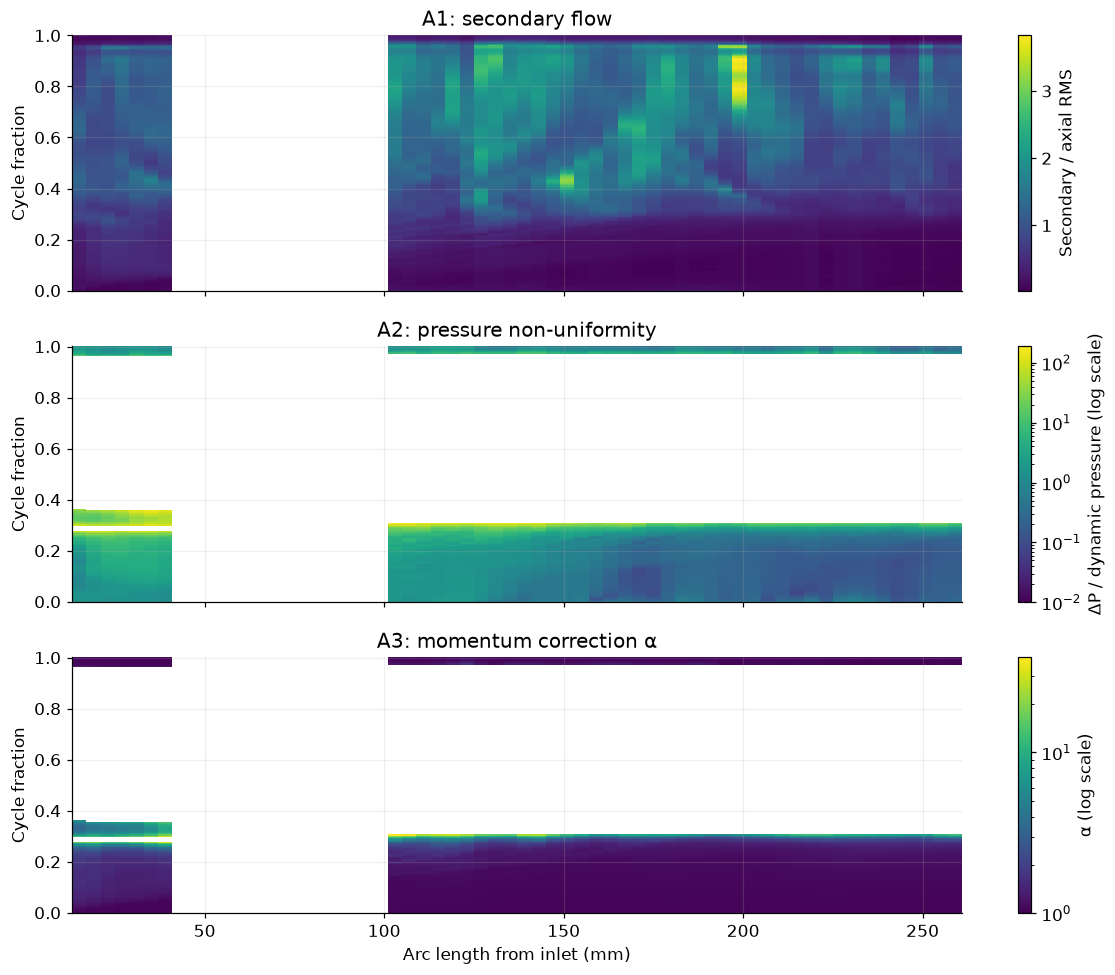

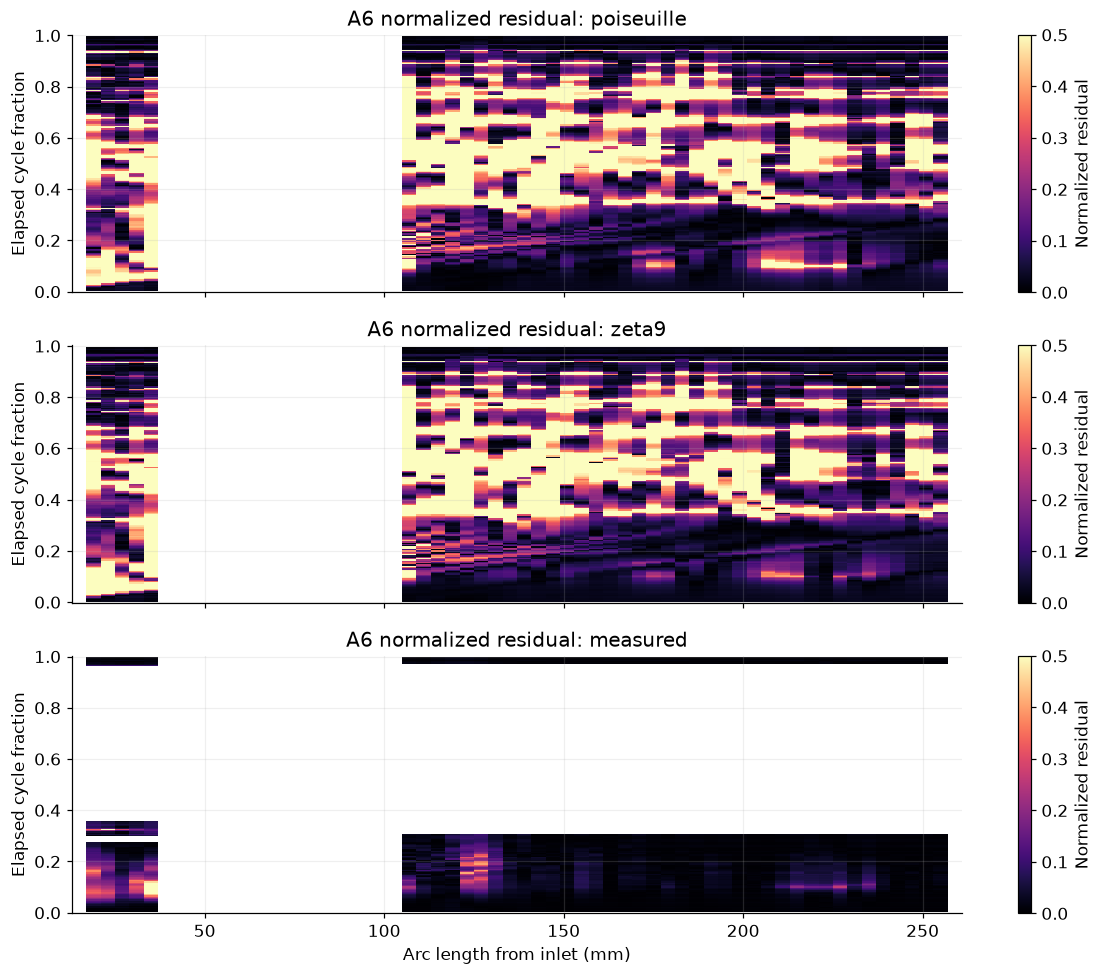

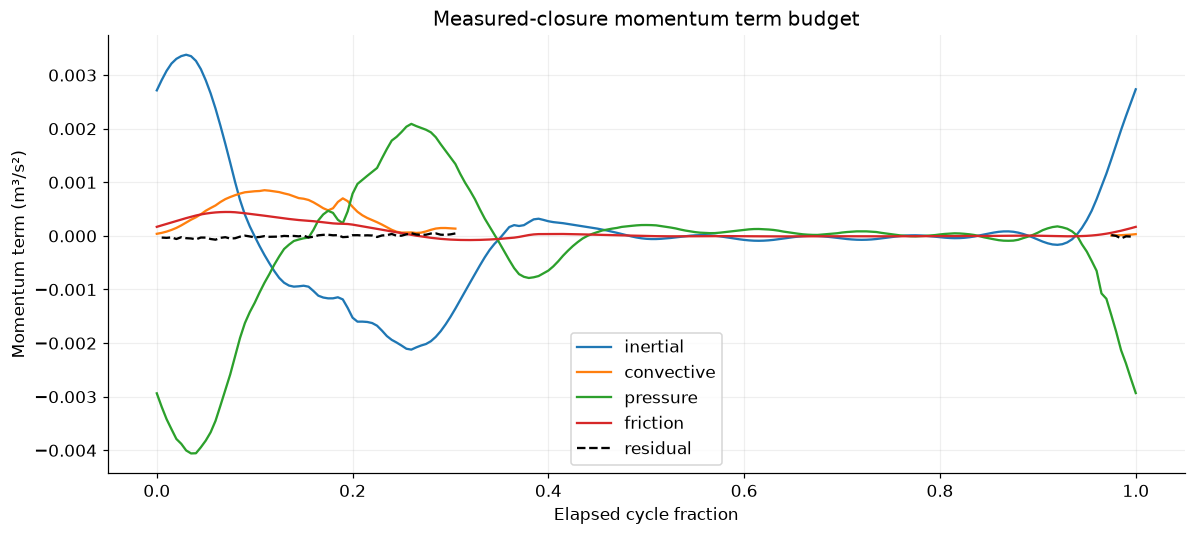

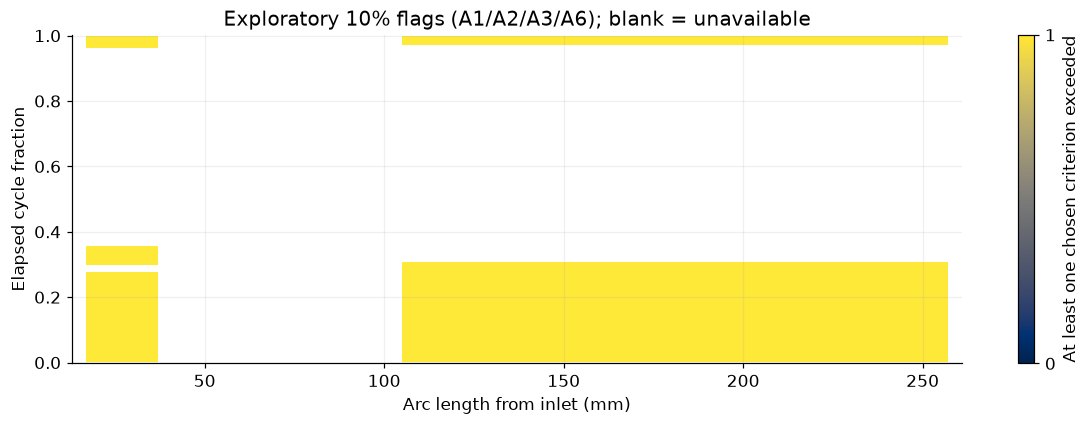

In [29]:
if volume_output is not None:
    volume_t,volume_fields,volume_terms,volume_table=volume_output
    fig,axes=plt.subplots(3,1,sharex=True,figsize=(11,9))
    for ax,key,label in zip(axes,['secondary_ratio','pressure_dynamic_ratio','alpha'],
                            ['A1: secondary flow','A2: pressure non-uniformity','A3: momentum correction α']):
        from matplotlib.colors import LogNorm
        values=volume_fields[key]
        norm=LogNorm(vmin=.01 if key=='pressure_dynamic_ratio' else 1.,vmax=np.nanmax(values)) if key in ['pressure_dynamic_ratio','alpha'] else None
        im=ax.pcolormesh(s*1000,volume_t/PERIOD,values,shading='auto',cmap='viridis',norm=norm)
        color_label={'secondary_ratio':'Secondary / axial RMS','pressure_dynamic_ratio':'ΔP / dynamic pressure (log scale)','alpha':'α (log scale)'}[key]
        ax.set(ylabel='Cycle fraction',title=label);fig.colorbar(im,ax=ax,label=color_label)
    axes[-1].set_xlabel('Arc length from inlet (mm)');save_figure('actual_volume_a1_a2_a3')
    fig,axes=plt.subplots(3,1,sharex=True,figsize=(11,9))
    for ax,(name,terms) in zip(axes,volume_terms.items()):
        im=ax.pcolormesh(s*1000,volume_t/PERIOD,terms['normalized'],shading='auto',vmin=0,vmax=.5,cmap='magma')
        ax.set(ylabel='Elapsed cycle fraction',title=f'A6 normalized residual: {name}')
        fig.colorbar(im,ax=ax,label='Normalized residual')
    axes[-1].set_xlabel('Arc length from inlet (mm)');save_figure('actual_volume_momentum_comparison')
    i=chosen_station
    fig,ax=plt.subplots(figsize=(11,5))
    for key in ['inertial','convective','pressure','friction']:
        ax.plot(volume_t/PERIOD,volume_terms['measured'][key][:,i],label=key)
    ax.plot(volume_t/PERIOD,volume_terms['measured']['residual'][:,i],color='black',ls='--',label='residual')
    ax.set(xlabel='Elapsed cycle fraction',ylabel='Momentum term (m³/s²)',title='Measured-closure momentum term budget')
    ax.legend();save_figure('actual_volume_term_budget')
    # Actual validity map only where all metrics are present, with explicit unavailable mask.
    available=np.isfinite(volume_terms['measured']['normalized']) & np.isfinite(volume_fields['secondary_ratio']) & np.isfinite(volume_fields['pressure_dynamic_ratio']) & np.isfinite(volume_fields['alpha'])
    actual_flags=np.where(available,((volume_terms['measured']['normalized']>.1) |
                        (volume_fields['secondary_ratio']>.1) |
                        (volume_fields['pressure_dynamic_ratio']>.1) |
                        (np.abs(volume_fields['alpha']-4/3)/(4/3)>.1)).astype(float),np.nan)
    fig,ax=plt.subplots(figsize=(11,4));im=ax.pcolormesh(s*1000,volume_t/PERIOD,actual_flags,shading='auto',vmin=0,vmax=1,cmap='cividis')
    ax.set(xlabel='Arc length from inlet (mm)',ylabel='Elapsed cycle fraction',title='Exploratory 10% flags (A1/A2/A3/A6); blank = unavailable')
    fig.colorbar(im,ax=ax,ticks=[0,1],label='At least one chosen criterion exceeded')
    save_figure('actual_volume_validity_flags')

**Avoid two misleading conclusions.** Extensive flagging does not mean every 1D prediction is unusable: the chosen tests interrogate particular assumptions and use different denominators. Likewise, a small momentum residual can coexist with sizable secondary flow, because some omitted effects may cancel or have modest influence on the projected balance. The spatial maps and term budget answer complementary questions; retain both when arguing about model adequacy.

### Actual α and signed friction against all requested references

At the same descending-aorta station, compare actual measured profile factor and reconstructed signed friction with Poiseuille, ζ=9 and the fully developed Womersley reference driven by actual section U(t). These are closure comparisons, not replacement CFD solutions. Log colors in A2/A3 maps preserve a wide positive range; tables retain exact values. Alpha and dynamic-pressure normalization remain unavailable near zero net flux.

**Why drive the Womersley comparison with measured section $U(t)$?** Giving all profiles the same bulk-flow history makes their differences primarily about radial shape and wall response, rather than a different input waveform. The actual aorta can remain asymmetric and developing, so disagreement with a straight-tube reference is physically possible. The lower panel preserves the force sign: a phase shift or reversal cannot be diagnosed from magnitude alone.

Large Womersley α spikes occur when the mean flow approaches cancellation while squared velocities remain finite. The reference helper uses a 1% cutoff, whereas actual volume α uses the configured 5% cutoff; consequently the gaps need not coincide. Do not infer better agreement from a missing line or read those spikes as abrupt anatomical changes. These phase-dependent effects are motivated by [dynamic circulation, PDF pp. 25–26 and 30–31](sources/course/dynamic_circulation.pdf#page=25).

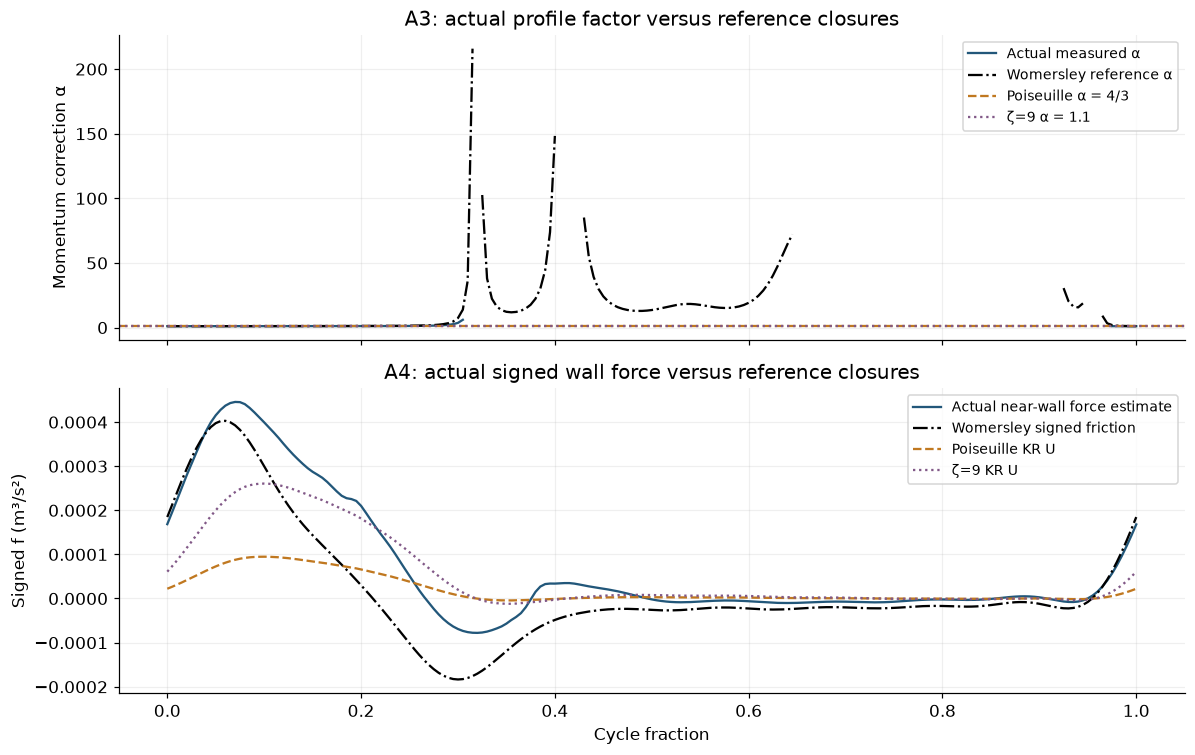

In [30]:
actual_ref=womersley_reference(volume_t,volume_fields['U'][:,chosen_station],radius[chosen_station],NU,PERIOD)
fig,axes=plt.subplots(2,1,sharex=True,figsize=(11,7))
axes[0].plot(volume_t/PERIOD,volume_fields['alpha'][:,chosen_station],color=COLORS['main'],label='Actual measured α')
axes[0].plot(volume_t/PERIOD,actual_ref['alpha'],color='black',ls='-.',label='Womersley reference α')
axes[0].axhline(4/3,color=COLORS['reference'],ls='--',label='Poiseuille α = 4/3')
axes[0].axhline(1.1,color=COLORS['alternate'],ls=':',label='ζ=9 α = 1.1')
axes[0].set(ylabel='Momentum correction α',title='A3: actual profile factor versus reference closures');axes[0].legend(fontsize=9)
actual_U=volume_fields['U'][:,chosen_station]
axes[1].plot(volume_t/PERIOD,volume_fields['f_measured'][:,chosen_station],color=COLORS['main'],label='Actual near-wall force estimate')
axes[1].plot(volume_t/PERIOD,actual_ref['friction'],color='black',ls='-.',label='Womersley signed friction')
axes[1].plot(volume_t/PERIOD,8*np.pi*NU*actual_U,color=COLORS['reference'],ls='--',label='Poiseuille KR U')
axes[1].plot(volume_t/PERIOD,22*np.pi*NU*actual_U,color=COLORS['alternate'],ls=':',label='ζ=9 KR U')
axes[1].set(xlabel='Cycle fraction',ylabel='Signed f (m³/s²)',title='A4: actual signed wall force versus reference closures');axes[1].legend(fontsize=9)
save_figure('actual_volume_reference_closures')

### Actual core sensitivity: thresholds, derivative spacing and time resolution

Tests below repeat derivatives on the same real section fields with spatial/time strides. This isolates derivative sampling sensitivity without changing the integration mesh. Coarser grids cannot establish mesh independence. Wall depth comparison isolates a separate reconstruction choice. Closure ablations change one assumption at a time but do not identify a unique physical cause.

The exploratory map includes all six criteria: A1 secondary ratio, A2 dynamic-pressure-normalized range, A3 relative α deviation from 4/3, A4 symmetric signed-friction deviation from Poiseuille, A5 local Q mismatch against branch-corrected cap continuity, and A6 normalized momentum residual. All use finite/low-flow/branch masks. A5 uses peak inlet flux as denominator. Same 10% threshold does not imply equal scientific meaning across metrics.

**Why vary thresholds and derivative spacing?** A 10% threshold is a chosen reporting convention. The table repeats the classification at 5%, 10% and 20%, so we can see how much the claimed “failure fraction” depends on that convention. Each row divides by its own eligible station–time pairs; these are not patient percentages or automatically equal fractions of wall area.

The derivative experiment retains every second/fourth time sample or every second station, recomputes the derivatives within unbranched runs, and compares with the baseline residual. A stride of 2 doubles the sampling interval; it does not rerun CFD on a coarser mesh. The full A1–A6 map requires all six metrics to be available. This is why it has more blanks than the individual maps. In the spirit of the course's convergence discussion, sensitivity must be reported for the quantity of interest ([computational haemodynamics, PDF p. 18](sources/course/computational_haemodynamics.pdf#page=18)).

threshold,0.05,0.10,0.20
assumption,,,
A1,0.978,0.903,0.804
A2,1.000,0.996,0.812
A3,0.934,0.855,0.497
A4,0.995,0.991,0.981
A5,0.000,0.000,0.000
A6,0.186,0.099,0.039


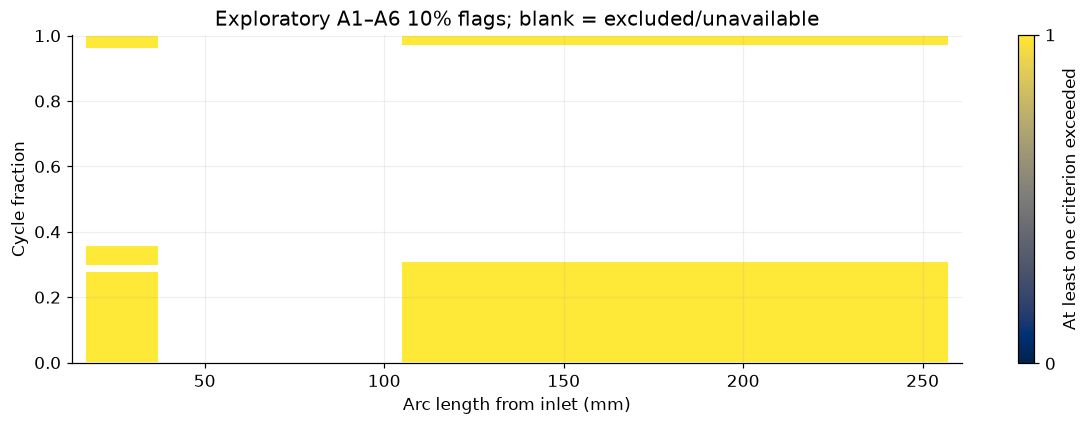

,time_stride,station_stride,dt_s,median_change_over_term_scale,95th_percentile_change_over_term_scale
0,1,1,0.00468,0.00000,0.00000
1,1,2,0.00468,0.00681,0.08408
2,2,1,0.00937,0.00291,0.01761
3,2,2,0.00937,0.00772,0.08419
4,4,1,0.01874,0.01373,0.03548
5,4,2,0.01874,0.01619,0.08976


In [31]:
actual_A4=2*np.abs(volume_fields['f_measured']-8*np.pi*NU*volume_fields['Q']/volume_fields['A'])/np.maximum(np.abs(volume_fields['f_measured'])+np.abs(8*np.pi*NU*volume_fields['Q']/volume_fields['A']),1e-12)
actual_A4[~np.isfinite(volume_fields['alpha'])]=np.nan
core_metrics={'A1':volume_fields['secondary_ratio'],'A2':volume_fields['pressure_dynamic_ratio'],
              'A3':np.abs(volume_fields['alpha']-4/3)/(4/3),'A4':actual_A4,
              'A5':np.abs(volume_q_error),'A6':volume_terms['measured']['normalized']}
core_threshold_rows=[]
for assumption,metric in core_metrics.items():
    good=np.isfinite(metric)
    for threshold in THRESHOLDS:
        core_threshold_rows.append({'assumption':assumption,'threshold':threshold,
                                    'eligible_pairs':int(good.sum()),
                                    'fraction_exceeding':float((metric[good]>threshold).mean())})
core_threshold_table=pd.DataFrame(core_threshold_rows)
core_threshold_table.to_csv(EXPORT/'core_threshold_sensitivity.csv',index=False)
display(core_threshold_table.pivot(index='assumption',columns='threshold',values='fraction_exceeding').round(3))
all_available=np.logical_and.reduce([np.isfinite(x) for x in core_metrics.values()])
any_exceeded=np.logical_or.reduce([x>.1 for x in core_metrics.values()])
full_core_flags=np.where(all_available,any_exceeded.astype(float),np.nan)
fig,ax=plt.subplots(figsize=(11,4));im=ax.pcolormesh(s*1000,volume_t/PERIOD,full_core_flags,shading='auto',vmin=0,vmax=1,cmap='cividis')
ax.set(xlabel='Arc length from inlet (mm)',ylabel='Cycle fraction',title='Exploratory A1–A6 10% flags; blank = excluded/unavailable')
fig.colorbar(im,ax=ax,ticks=[0,1],label='At least one criterion exceeded');save_figure('actual_full_core_flags')

derivative_rows=[]
volume_ids=np.asarray(actual_volume_cache['section_ids'],int)
for time_stride in [1,2,4]:
    jj=np.arange(0,len(volume_t),time_stride)
    for station_stride in [1,2]:
        differences=[];scales=[]
        for run in np.split(volume_ids,np.where(np.diff(volume_ids)>1)[0]+1):
            ii=run[::station_stride]
            if len(ii)<3:continue
            selection=np.ix_(jj,ii)
            terms=balance_terms(volume_t[jj],s[ii],volume_fields['A'][selection],volume_fields['Q'][selection],
                                volume_fields['P'][selection],volume_fields['alpha'][selection],volume_fields['f_measured'][selection],RHO)
            baseline=volume_terms['measured']['residual'][selection]
            differences.extend(np.abs(terms['residual']-baseline).ravel())
            scales.extend((np.abs(terms['inertial'])+np.abs(terms['convective'])+np.abs(terms['pressure'])+np.abs(terms['friction'])).ravel())
        differences=np.asarray(differences);scales=np.asarray(scales)
        ok=np.isfinite(differences)&np.isfinite(scales)&(scales>1e-10)
        normalized_difference=differences[ok]/scales[ok]
        derivative_rows.append({'time_stride':time_stride,'station_stride':station_stride,
                                'dt_s':np.median(np.diff(volume_t[jj])),
                                'median_change_over_term_scale':np.median(normalized_difference),
                                '95th_percentile_change_over_term_scale':np.quantile(normalized_difference,.95)})
derivative_table=pd.DataFrame(derivative_rows)
display(derivative_table.round(5));derivative_table.to_csv(EXPORT/'momentum_derivative_sensitivity.csv',index=False)

**Observed sensitivity.** Across the tested coarsenings, the largest median change in residual divided by the term-magnitude scale is approximately **0.016**, with a corresponding 95th-percentile change of approximately **0.090**. These are numerical-sensitivity measures, not confidence intervals. The high fraction of flagged points in several rows should therefore be discussed together with thresholds, masking and normalisation, rather than reported as a universal pass/fail verdict.

## 8. Sensitivity and checks

Area estimates are recomputed at 2, 4 and 8 mm spacing. Compare each against baseline by interpolation only within valid unbranched runs. This checks slicing/resampling sensitivity; it does not prove CFD mesh independence. Thresholds 5%, 10% and 20% above show sensitivity of exploratory friction flags. For full volume analysis, rerun with multiple spacings and temporal strides; compare derivative terms before attributing a residual to physics.

Additional checks to discuss: VMTK decimation/smoothing sensitivity, branch-root projection and exclusion width, WSS mesh/probe convergence, cap extensions, inflow periodicity, unavailable cycle-to-cycle convergence, and sensitivity of pressure-range extrema to individual noisy nodes. One healthy rigid geometry cannot support general claims about stenoses or compliant vessels.

**What this geometry sensitivity check can and cannot say.** We repeat section-area estimation at nominal 2, 4 and 8 mm station spacing and compare only where an unbranched baseline exists. Similar areas support robustness of this post-processing choice. They do not prove convergence of the original CFD mesh or time integrator. Curvature, pressure gradients and wall derivatives can be more sensitive than area. The final assertions test physical/numerical invariants—positive area, a complete cycle and OSI between 0 and 0.5—not grading thresholds.

In [32]:
spacing_rows=[]
for test_spacing in [.002,.004,.008]:
    ss,xx,nn,kk=resample_path(centerline_points,test_spacing,TRIM)
    values=np.full(len(ss),np.nan)
    for i in range(len(ss)):
        if any(abs(ss[i]-root)<BRANCH_EXCLUSION for root in branch_locations.values()): continue
        try: values[i]=wall_loop(wall,xx[i],nn[i])[2]
        except ValueError: pass
    # Compare only within contiguous baseline runs, never bridge a branch gap.
    reference=np.full(len(ss),np.nan)
    ids=np.flatnonzero(valid_geometry)
    for run in np.split(ids,np.where(np.diff(ids)>1)[0]+1):
        if len(run)<2: continue
        eligible_s=(ss>=s[run[0]])&(ss<=s[run[-1]])
        reference[eligible_s]=np.interp(ss[eligible_s],s[run],area[run])
    ok=np.isfinite(values)&np.isfinite(reference)
    errors=np.abs(values[ok]/reference[ok]-1)
    spacing_rows.append({'spacing_mm':test_spacing*1000,'comparable_stations':int(ok.sum()),
                         'median_area_difference_percent':np.median(errors)*100,
                         'max_area_difference_percent':np.max(errors)*100})
spacing_table=pd.DataFrame(spacing_rows)
display(spacing_table.round(3));spacing_table.to_csv(EXPORT/'slice_spacing_sensitivity.csv',index=False)
# Sanity gates on physical and numerical invariants, not assignment acceptance scores.
assert len(steps)==201 and np.isclose(cycle_t[-1]-cycle_t[0],PERIOD)
assert np.all(area[np.isfinite(area)]>0)
assert np.all(np.isfinite(flow_table[list(CAP_IDS)].to_numpy()))
assert np.all((OSI[np.isfinite(OSI)]>=0)&(OSI[np.isfinite(OSI)]<=.5))
print('Basic input, units, geometry and wall-metric checks passed.')

,spacing_mm,comparable_stations,median_area_difference_percent,max_area_difference_percent
0,2.0,92,0.000,0.437
1,4.0,47,0.000,0.000
2,8.0,24,0.032,0.247


Basic input, units, geometry and wall-metric checks passed.


## 9. ParaView and optional interactive PyVista inspection

Open `results/actual_wall_metrics.vtp` in ParaView, click **Apply**, color by `TAWSS_Pa`, then `OSI`. Coordinates and shear are SI. Use **Slice**, with a station's `station_xyz` as Origin and `tangents` as Normal, to inspect masks/contours. Surface Slice gives lines; volume Slice gives a filled section. Inspect that distinction directly.

`results/cap_velocity_cycle.pvd` contains lightweight cap-only snapshots in SI with correct elapsed-cycle times. In ParaView, open the PVD, color by velocity magnitude, select a cap and use **Integrate Variables** on `normal_velocity_m_s` to check signed flux. `results/main_centerline.vtp` has station geometry and availability flags.

Optional script:

```bash
# macOS example; use your installed ParaView path:
/Applications/ParaView.app/Contents/bin/pvpython paraview_preview.py
```

The script opens exported wall/centerline data and writes `results/paraview_preview.png`. ParaView Python execution is separate from notebook. For live PyVista rotation, enable the optional cell below on a desktop with OpenGL; it stays disabled for portable Run All.

**Why export VTP/PVD as well as figures?** The figures communicate selected views; VTP retains geometry plus field values so another group member can rotate the model and inspect locations in ParaView. PVD connects the cap snapshots to their times. PyVista and ParaView use the same VTK data family, making this a portable inspection route. Manual viewing is especially helpful for centreline placement, branch exclusions and unusual wall-metric regions, but it complements quantitative checks rather than establishing them by appearance.

In [33]:
main_line=pv.lines_from_points(station_xyz)
main_line['s_m']=s;main_line['area_m2']=area;main_line['curvature_per_m']=curvature
main_line['Wo']=Wo;main_line['usable']=valid_geometry.astype(np.uint8)
main_line.save(EXPORT/'main_centerline.vtp')
# Compact time-series export avoids loading 403 arrays in ParaView.
cap_export=pv.MultiBlock([item['mesh'] for item in caps.values()]).combine().extract_surface(algorithm='dataset_surface')
cap_point_ids=np.asarray(cap_export['source_point_id'],int)
cap_normals=np.zeros((cap_export.n_points,3))
for name,item in caps.items():
    selected=np.isin(cap_point_ids,item['indices'])
    cap_normals[selected]=item['normal']
frames_dir=EXPORT/'cap_frames';frames_dir.mkdir(exist_ok=True)
pvd=['<?xml version="1.0"?>','<VTKFile type="Collection" version="0.1" byte_order="LittleEndian">','<Collection>']
for j,step in enumerate(steps):
    frame=cap_export.copy()
    vel=np.asarray(surface_results[f'velocity_{step}'])[cap_point_ids]*units.velocity
    frame['velocity_m_s']=vel;frame['normal_velocity_m_s']=np.sum(vel*cap_normals,axis=1)
    frame.save(frames_dir/f'cap_{j:03d}.vtp')
    pvd.append(f'<DataSet timestep="{cycle_t[j]:.9f}" group="" part="0" file="cap_frames/cap_{j:03d}.vtp"/>')
pvd+=['</Collection>','</VTKFile>']
(EXPORT/'cap_velocity_cycle.pvd').write_text('\n'.join(pvd))
print('Exported wall metrics, centerline, cap velocity PVD and CSV tables.')

INTERACTIVE_PREVIEW = False
if INTERACTIVE_PREVIEW:
    plotter=pv.Plotter(notebook=False)
    plotter.add_mesh(result_wall,scalars='TAWSS_Pa',cmap='viridis',scalar_bar_args={'title':'TAWSS (Pa)'})
    plotter.add_mesh(main_line,color='orange',line_width=4)
    plotter.show()  # optional native desktop window for rotation

Exported wall metrics, centerline, cap velocity PVD and CSV tables.


## 10. Findings, limits and group handoff

The following summary is generated from executed results. It distinguishes actual measurements, continuity-based estimates, analytic references and unavailable quantities. Use exported figures/CSV for report and presentation; preserve labels, units and qualifications.

**How to turn calculations into a scientific argument.** Start with the conservation checks that establish the measurements are internally consistent. Then describe which pressure/profile/friction assumptions disagree, at what locations and phases, before using the term budget and closure comparisons to discuss plausible reasons. End with how those conclusions change under numerical choices and what this one rigid healthy geometry cannot answer. This sequence supports the Methods–Results–Discussion structure in the [project guidelines, PDF p. 1](sources/course/project_guidelines.pdf#page=1).

In [34]:
summary = f"""
### Executed findings for supplied healthy rigid aorta
- **Actual A5 global cap balance:** maximum mismatch / peak inlet flow = **{np.max(np.abs(mass_relative))*100:.3g}%**; integrated signed mismatch = **{cycle_mass_error*100:.3g}%** over **{PERIOD:.3f} s**.
- **Actual inlet flow:** mean **{cycle_volumes['inflow']/PERIOD*1e6:.2f} mL/s**, peak **{flows['inflow'].max()*1e6:.2f} mL/s**.
- **Actual wall shear:** area-weighted mean TAWSS **{wall_mean:.3f} Pa**; nodal OSI median **{np.nanmedian(OSI):.3f}**.
- **Geometry:** **{valid_geometry.sum()}** usable main-vessel stations out of **{len(s)}** after open-contour and branch exclusions. No stenosis diagnosis inferred.
- **A4 exploratory comparison:** wall-shear magnitude and circular-profile friction estimates are compared with low-flow masks; this is not a signed-force residual.
- **Actual A1/A2/A3/A6:** {'volume results analysed; inspect exported maps and residual term budgets' if volume_output is not None else 'unavailable from supplied surface-only export; full volume pipeline included'}.
- **Actual measured-closure residual:** median **{np.nanmedian(volume_terms['measured']['normalized']):.3f}**, 95th percentile **{np.nanquantile(volume_terms['measured']['normalized'],.95):.3f}**, with excluded edges/branches/low flow. Poiseuille median **{float(closure_statistics.loc[closure_statistics.closure=='poiseuille','median_normalized_residual'].iloc[0]):.3f}** on the same finite station/phase pairs.
- **Actual local mass:** maximum section-vs-cap mismatch / peak inlet Q **{100*np.nanmax(abs(volume_q_error)):.3f}%**.
- **Verified reference:** Poiseuille mass/momentum closure and pulsatile Womersley flux, wall no-slip and analytic momentum closure.

All Project 2 core computations now use actual interior velocity/pressure from the matching volume source. Residual interpretation remains limited by 1D pressure reduction, near-wall reconstruction, centerline/derivative choices and branch exclusions. This healthy geometry does not test an anatomical stenosis; the manufactured narrowing is only a code check.
"""
display(Markdown(summary))
(EXPORT/'findings.md').write_text(summary)
coverage=pd.DataFrame([
 {'assumption':'A1','actual_status':'measured volume' if volume_output else 'unavailable: no interior velocity'},
 {'assumption':'A2','actual_status':'measured volume' if volume_output else 'unavailable: no pressure'},
 {'assumption':'A3','actual_status':'measured volume' if volume_output else 'unavailable: no filled-section velocity'},
 {'assumption':'A4','actual_status':'surface WSS magnitude comparison; signed volume force only if volume enabled'},
 {'assumption':'A5','actual_status':'actual global cap balance; local inferred rigid flux; volume local balance if enabled'},
 {'assumption':'A6','actual_status':'measured volume' if volume_output else 'analytic verified; actual unavailable'}])
coverage.to_csv(EXPORT/'assumption_coverage.csv',index=False)
display(coverage)


### Executed findings for supplied healthy rigid aorta
- **Actual A5 global cap balance:** maximum mismatch / peak inlet flow = **2.18e-05%**; integrated signed mismatch = **-2.92e-07%** over **0.937 s**.
- **Actual inlet flow:** mean **96.67 mL/s**, peak **501.96 mL/s**.
- **Actual wall shear:** area-weighted mean TAWSS **2.138 Pa**; nodal OSI median **0.102**.
- **Geometry:** **47** usable main-vessel stations out of **62** after open-contour and branch exclusions. No stenosis diagnosis inferred.
- **A4 exploratory comparison:** wall-shear magnitude and circular-profile friction estimates are compared with low-flow masks; this is not a signed-force residual.
- **Actual A1/A2/A3/A6:** volume results analysed; inspect exported maps and residual term budgets.
- **Actual measured-closure residual:** median **0.012**, 95th percentile **0.175**, with excluded edges/branches/low flow. Poiseuille median **0.046** on the same finite station/phase pairs.
- **Actual local mass:** maximum section-vs-cap mismatch / peak inlet Q **0.350%**.
- **Verified reference:** Poiseuille mass/momentum closure and pulsatile Womersley flux, wall no-slip and analytic momentum closure.

All Project 2 core computations now use actual interior velocity/pressure from the matching volume source. Residual interpretation remains limited by 1D pressure reduction, near-wall reconstruction, centerline/derivative choices and branch exclusions. This healthy geometry does not test an anatomical stenosis; the manufactured narrowing is only a code check.


,assumption,actual_status
0,A1,measured volume
1,A2,measured volume
2,A3,measured volume
3,A4,surface WSS magnitude comparison; signed volum...
4,A5,actual global cap balance; local inferred rigi...
5,A6,measured volume


**Questions the group should be able to answer from this notebook.** Why can a rigid model have strongly time-dependent flow? Why does net flow drop after an arch branch without violating conservation? Why can α diverge near flow reversal? Why can a correct mass balance coexist with inaccurate wall shear? Why must closure residuals be compared on the same samples?

The reasoning is now beside the relevant calculations: unsteady velocity does not require wall motion; branches carry away flux; α divides by squared net flow; shear uses a sensitive wall derivative; and masks change the population being compared. Use the figures to explain each mechanism in your own words before writing the report.

### Report and presentation scaffold

**Abstract:** question, healthy rigid model, supported tests, observed numbers from summary, near-wall, rigid-wall and healthy-model limitations. **Introduction:** purpose of 1D reductions and closure assumptions. **Methods:** equations, units, data authority, VMTK/caps/slicing/quadrature, reference profiles, masks, residual convention and analytic checks. **Results:** actual mass balance → geometry and reference Wo/Re/Dean → wall-shear/ref friction; actual A1/A2/A3/A6 maps and closure residuals. **Discussion:** interpretations vs evidence, rigid walls, healthy single geometry, branch masks, near-zero flow, thresholds/spacing, single-cycle convergence limits and near-wall reconstruction uncertainty. **Appendices:** notebook, environment, source manifest, contribution/authorship log.

Do not equate implemented core calculations with proof that the 1D model is universally valid. Distinguish numerical sensitivity and missing anatomical stenosis evidence. The supplied working plan's deadlines and roles remain in original `sources/FtP Project.pdf`; no logbook work or authorship is invented here.

| Contribution | Owner (fill after actual work) | Evidence / review |
|---|---|---|
| Data provenance / setup | Group to record | Run environment and source manifest |
| Geometry / cap orientation | Group to record | Inspect geometry and branch masks |
| Physics / verification | Group to record | Explain equations, profile constants and checks |
| Wall-shear / mass interpretation | Group to record | Review CSV and figures |
| Volume / limitations | Group to record | Confirm scope with instructor |
| Report / presentation | Group to record | Reproduce key figures, acknowledge assistance |

**Authorship note:** notebook drafted with AI assistance; group should review methods, reproduce outputs, understand every conclusion and follow course disclosure rules. This is a transparent note, not a claim that any member has already completed a task.

### Glossary

**A** area (m²); **Q** signed volumetric flux (m³/s); **U** mean axial speed (m/s); **ρ** density (kg/m³); **μ** dynamic viscosity (Pa·s); **ν** kinematic viscosity (m²/s); **α** momentum-profile correction; **ζ** power-profile exponent; **KR** friction coefficient (m²/s); **f** signed force/density per length (m³/s²); **Re=|U|D/ν**; **Wo=R√(ω/ν)**; **Dean=Re√(Rκ)** under radius-based curvature convention; **κ** curvature (1/m); **TAWSS** time-averaged shear magnitude (Pa); **OSI** shear-direction cancellation index; **RRT** reciprocal effective shear index (Pa⁻¹); **VTP** surface/polyline data; **VTU** unstructured volume data; **PVD** time-series collection.

### Source acknowledgement

Model data from the [Vascular Model Repository](https://www.vascularmodel.com/). Preserve `data/0012_H_AO_H/LICENSE` and `README-COPYRIGHT` in every copy containing model data or derived portions. Repository acknowledgement: Wilson, Ortiz & Johnson, *The Vascular Model Repository: A Public Resource of Medical Imaging Data and Blood Flow Simulation Results*, J. Med. Devices 7(4), 040923 (2013), [doi:10.1115/1.4025983](https://doi.org/10.1115/1.4025983). Model specification also cites LaDisa et al. (2011); that paper was not supplied or used for numerical conclusions here.

Data supplied with federal support from National Library of Medicine Grant R01LM013120 and NHLBI Contract HHSN268201100035C. Full notice preserved alongside inputs. Share bundle within your group; no external upload is performed.

**Why record provenance at the end?** A plot is reproducible only if its data version, parameter values, package versions and method can be recovered. `run_manifest.json` records those for the numerical analysis; `sources/course_sources.json` separately records the Canvas teaching sources used in these explanations. Neither substitutes for the group's actual contribution record. The guidelines also request a report, presentation and a `main.py` entry point for final submission; this notebook provides the executable analysis and explanations, so check that final submission format with the supervisor.

In [35]:
# Record reproducible source/context information without machine-specific paths.
source_files=[DATA/'Models'/'0095_0001.vtp',DATA/'Paths'/'aorta.pth',
              DATA/'Simulations'/'0095_0001'/'solver.inp',
              DATA/'Simulations'/'0095_0001'/'0095_0001.svpre',SURFACE_FILE,
              BASE/'sources'/'FtP Project.pdf',BASE/'sources'/'0012_H_AO_H.pdf',
              BASE/'sources'/'VMTK, PyVista, Cardiovascular Modeling.md',BASE/'sources'/'FP2P_projects_Simone.pptx',BASE/'data'/'actual_volume_sections.npz']
provenance={'sources':[{'file':str(p.relative_to(BASE)),'sha256':sha256_file(p)} for p in source_files],
            'python':platform.python_version(),'platform':platform.platform(),'packages':pd_versions,
            'parameters':{'rho_kg_m3':RHO,'mu_Pa_s':MU,'period_s':PERIOD,'dt_s':DT,
                          'spacing_m':SPACING,'trim_m':TRIM,'branch_exclusion_m':BRANCH_EXCLUSION,
                          'low_flow_fraction':LOW_FLOW_FRACTION,'thresholds':THRESHOLDS},
            'data_scope':'rigid healthy aorta; completed surface and downloaded volume sections', 'volume_source':volume_source_meta,
            'centerline_cache':cache_signature,'volume_enabled':RUN_VOLUME,'compact_volume_sha256':sha256_file(volume_cache_path)}
(EXPORT/'run_manifest.json').write_text(json.dumps(provenance,indent=2))
print('Run complete. Share notebook + full folder, or browse notebook.html without Python.')

Run complete. Share notebook + full folder, or browse notebook.html without Python.


### Course evidence and what we added

The following originals are bundled so group members can follow the citations offline. They were re-downloaded from the authorised Canvas course on **8 October 2026** and matched to exact file IDs/hashes in `sources/course_sources.json`. The Project 2 slides match the previously supplied version.

| Source | Exact material used | Connection to this notebook |
|---|---|---|
| [Introduction](sources/course/introduction.pptx) | Slides 24–28, 40, 45 | From physical forces to physiological function; verification versus validation |
| [Steady flow](sources/course/steady_flow.pptx) | Slides 11–12, 24, 31, 40, 51 | Flux integrals, continuity, Poiseuille assumptions and wall shear |
| [Dynamic circulation](sources/course/dynamic_circulation.pdf) | PDF pp. 7–31 | Mass/momentum terms, local/convective inertia, Re/Wo, pulsatile profiles, stenosis mechanisms |
| [Computational haemodynamics](sources/course/computational_haemodynamics.pdf) | PDF pp. 7–29 | Geometry, boundary conditions, near-wall resolution, sampling and independent validation |
| [Project 2 brief](sources/FP2P_projects_Simone.pptx) | Slide 2 | Controlling core work: sections, closure tests, momentum residual |
| [Project guidelines](sources/course/project_guidelines.pdf) | PDF p. 1 | Explained methods, reproducible documented code, report/presentation and actual group contributions |
| [Group plan](sources/FtP%20Project.pdf) | PDF pp. 3–4 | A1–A6 organisation, chosen reference comparisons and proposed exploratory thresholds |

The course supplies the physical principles and modelling context. Barycentric interpolation, quadrature order, VMTK settings, cache design, low-flow masks, Dean convention and flag thresholds are documented implementation or analysis choices. The model's units/material properties come from its own input files. Numerical interpretations refer to the saved executed outputs; if you change parameters or data, update those prose observations using the newly generated tables.